# Predicting Airbnb Listing Prices in Brisbane, Australia


---

**About this project.** <br>
This was structured as a Kaggle-style prediction competition. It is shared here as a portfolio piece to demonstrate the end-to-end workflow: <br>
  - Task 1 explains the problem 
  - Task 2 includes EDA and feature engineering
  - Tassk 3 includes selecting the initial model set, designing the cross-validation strategy, tuning ElasticNet, Random Forest, Gradient Boosting, Histogram Gradient Boosting and Extra Trees, building the voting ensemble, and producing the final Kaggle submission and residual/error analysis.
---


---

## Task 1: Problem Description and Exploratory Data Analysis (EDA)  
---

#### 1. Forecasting Problem


**Problem Definition:**

This problem aims to predict the nightly rental price (AUD) of Airbnb listings in Brisbane from listing-level characteristics. The dataset captures a cross-sectional snapshot from a single point in time, so the model learns how prices relate to property attributes rather than how they change over time through seasonal demand or major events. It therefore estimates a property's expected market price from its observable attributes.

<br>

**Stakeholders and Applications:**

The model gives stakeholders a quantitative basis for pricing and investment decisions in the short-term rental market.

- **Existing hosts** are the most direct beneficiaries, as the model is likely to provide more reliable estimates for listings with richer observable information and review history. They can benchmark their current nightly rate against the model's estimated market value to check whether they are leaving revenue on the table or pricing themselves out of bookings. Commercial operators can extend this benchmarking across a portfolio to flag mispriced listings at scale.

- **New hosts and prospective investors** can also draw on the model, though with less precision, since a listing without a track record offers fewer of the behavioural signals the model relies on. For a new host, the prediction provides a reasonable opening rate based on the property's structural and locational features. For an investor evaluating a property before purchase, it offers an early estimate of potential nightly income that can be combined with an expected occupancy rate to project annual revenue and return on investment. This is increasingly relevant in Brisbane, where the 2032 Olympics is likely to strengthen the rental market and attract new investment. As a cross-sectional model, however, it estimates baseline price under normal conditions rather than the temporary demand surge such an event generates, so the prediction is best treated as a structural benchmark.

- **Airbnb as a platform** can use such models to power automated pricing tools, similar in principle to its existing "Smart Pricing" feature. Accurate guidance helps hosts price at market-appropriate rates, improving booking rates, host retention, and overall marketplace efficiency.

<hr style="width:25%;margin-left:0;">

#### 2. Evaluation Criteria


**Definition:**

The competition assesses forecasting performance using the **Mean Absolute Percentage Error (MAPE)**, which measures the average size of the prediction error as a percentage of the actual value. It is defined as:

$$MAPE = \frac{1}{n} \sum_{i=1}^{n} \left|\frac{y_i - \hat{y}_i}{y_i}\right| \times 100\%$$

where:

- $n$ is the number of listings,
- $y_i$ is the actual listing price,
- $\hat{y}_i$ is the predicted listing price.

For each listing, the absolute difference between the actual and predicted price is divided by the actual price, expressing the error in relative rather than absolute terms. These relative errors are then averaged across all listings to give a single percentage score, where a lower MAPE indicates better predictive accuracy.

<br>

**Advantages:**

- **Interpretability**: Because errors are expressed as percentages, the metric is intuitive and easy to communicate. A MAPE of 15% means predictions are off by 15% on average, regardless of whether a listing costs AUD 50 or AUD 5,000 per night.

- **Scale independence**: MAPE evaluates errors proportionally rather than in dollar terms, so performance is comparable across listings of very different value. Unlike an absolute metric such as Mean Absolute Error (MAE), which would be dominated by errors on high-priced listings, MAPE treats an AUD 10 error on an AUD 50 listing as equivalent to an AUD 200 error on an AUD 1,000 listing, since both represent a 20% deviation. This is particularly valuable for Airbnb price prediction, where nightly rates vary substantially.


<br>

**Limitations:**

- **No directional information**: Because errors are expressed in absolute terms, MAPE does not indicate whether the model systematically overpredicts or underpredicts prices.

- **Uneven weighting across price ranges**: The same absolute error produces very different percentage errors at different price levels. For example, an AUD 100 error represents only 5% for a luxury listing priced at AUD 2,000, but 50% for a budget listing priced at AUD 200. As a result, MAPE places greater emphasis on prediction accuracy for lower-priced listings.

- **Asymmetric incentives**: MAPE penalises over-prediction more heavily than under-prediction. Because the denominator is the actual price, an over-prediction has no upper bound on its percentage error, while an under-prediction is capped at 100%. This can bias a model towards systematically under-predicting prices.

- **Undefined at zero**: MAPE cannot be computed when the actual price is zero, since the formula divides by the actual value.

These limitations also have modelling implications. Because MAPE evaluates proportional rather than absolute errors, training directly on raw prices may not align well with the metric, as the model would prioritise absolute dollar accuracy on expensive listings. Log-transforming the target helps address this, since differences on the log scale more closely reflect the percentage differences that MAPE measures. This is the approach adopted in the modelling that follows.

<hr style="width:25%;margin-left:0;">

#### 3. Missing Values


**3.1 Initialization**

All libraries used across the notebook are imported once at the start to avoid re-importing in later cells and to ensure the notebook runs reliably from top to bottom. The training and test datasets are then loaded and previewed.

In [1]:
# Initialization: imports, display options, and data loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 
import re, html, ast, warnings
warnings.filterwarnings("ignore")

# sklearn — preprocessing & pipeline
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import RobustScaler
from sklearn.cluster         import KMeans

# sklearn — models
from sklearn.linear_model    import Ridge, ElasticNet
from sklearn.ensemble        import (RandomForestRegressor,
                                     GradientBoostingRegressor,
                                     AdaBoostRegressor,
                                     VotingRegressor)
from sklearn.tree            import DecisionTreeRegressor
from sklearn.svm             import SVR

# sklearn — model selection & metrics
from sklearn.model_selection import (KFold, GridSearchCV,
                                     RandomizedSearchCV,
                                     train_test_split)
from sklearn.metrics         import mean_absolute_percentage_error, make_scorer
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Display all columns and rows in full
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Load the training and test datasets
df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/test.csv')

# Verify the data loaded correctly
print("Train shape:", df_train.shape)
print("Test shape: ", df_test.shape)
df_train.head(2)

Train shape: (3735, 65)
Test shape:  (1601, 64)


,ID,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price
0,0,city scrape,The Nestt,Enjoy a memorable visit when you stay in this ...,NaN,38029254,Mark,2015-07-09,NaN,NaN,within an hour,100%,89%,t,NaN,8.0,"['email', 'phone', 'work_email']",t,t,Rocklea - Acacia Ridge,-27.55732,153.02027,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Hair dryer"", ""Hangers"", ""Fire extinguisher"",...",5,365,5.0,5.0,365.0,365.0,5.0,365.0,12,30,53,328,18,10,1,30,4,100,9700.0,2023-04-27,2025-10-25,4.56,4.61,4.44,4.78,4.61,4.28,4.50,f,8,8,0,0,0.58,$97.00
1,1,city scrape,Bayside Bliss - By the Water & Near the Airport,"Relax by the water and close to the airport, B...",Wynnum is nestled along Brisbane's sunny south...,33488214,Claire,2015-05-16,"Wynnum, Australia",NaN,within an hour,100%,93%,t,NaN,1.0,"['email', 'phone']",t,t,Wynnum,-27.44579,153.17909,Entire guest suite,Entire home/apt,4,1.0,1 bath,2.0,3.0,"[""Laundromat nearby"", ""Refrigerator"", ""Bed lin...",1,14,1.0,1.0,14.0,14.0,1.0,14.0,14,15,45,110,16,8,1,14,10,48,9840.0,2024-06-16,2025-11-02,4.94,4.88,5.00,4.94,4.94,4.88,4.69,f,1,1,0,0,0.93,$205.00


**3.2 Column-Level Missingness**

Column-level missingness was examined to assess the completeness and reliability of individual features. This analysis highlights the extent of missing data and informs subsequent preprocessing decisions.

In [2]:
# Function to count and express missing values per column
def get_missing_summary(df, prefix):
    summary = pd.DataFrame({
        f'{prefix} Missing': df.isnull().sum(),
        f'{prefix} %':       (df.isnull().sum() / len(df)) * 100
    })
    # Keep only columns that have at least one missing value
    return summary[summary[f'{prefix} Missing'] > 0]

# Apply to train and test
train_summary = get_missing_summary(df_train, 'Train')
test_summary  = get_missing_summary(df_test,  'Test')

# Join so train and test missingness sit side by side, sorted by train %
missing_by_col = (
    train_summary.join(test_summary, how='outer')
    .fillna(0)
    .sort_values(by='Train %', ascending=False)
)
missing_by_col['Train %'] = missing_by_col['Train %'].round(2)
missing_by_col['Test %']  = missing_by_col['Test %'].round(2)

missing_by_col

,Train Missing,Train %,Test Missing,Test %
host_neighbourhood,3599,96.36,1536.0,95.94
neighborhood_overview,1981,53.04,847.0,52.90
host_about,1492,39.95,618.0,38.60
host_location,818,21.90,337.0,21.05
reviews_per_month,437,11.70,183.0,11.43
review_scores_value,437,11.70,183.0,11.43
review_scores_rating,437,11.70,183.0,11.43
review_scores_location,437,11.70,183.0,11.43
first_review,437,11.70,183.0,11.43
review_scores_communication,437,11.70,183.0,11.43


**Summary:**

- Missing data patterns are highly consistent across the training and test datasets (e.g. review fields are missing in 11.70% of train and 11.43% of test rows), indicating similar data characteristics.

- **Textual variables:** The highest levels of missingness occur in textual and descriptive features. In particular, `host_neighbourhood` has the most missing values (3,599 in train; 1,536 in test), representing approximately 96% of observations in both datasets. Other text-based variables, including `neighborhood_overview`, `host_about`, and `host_location`, also exhibit moderate missingness (approximately 21–53%). This suggests missingness is driven by host behaviour, as these fields are optional and left blank by some hosts.

- **Review-related variables:** A clear pattern of structured missingness is observed in the review-related variables (`reviews_per_month`, the seven `review_scores_*` fields, `first_review`, and `last_review`), which share identical missing counts (437 in train; 183 in test). This indicates that these listings have no review history, so the missingness is not Missing Completely at Random (MCAR); it reflects underlying listing activity rather than random omission.

- **Other variables:** The remaining variables show low missingness (generally below 10%), indicating high data completeness and minimal impact on overall data quality.

- **Target variable:** `price` has no missing values in the training set, so no training observations are lost. The test set contains no `price` column, as price is the prediction target, which is expected and does not constitute missing data.


**3.3 Row-Level Missingness**

While column-level analysis shows which features are incomplete, row-level analysis identifies whether any individual listings are missing data across many fields at once. Each row's proportion of missing values is calculated, and rows missing more than 20% of their fields are flagged. For these flagged rows, the missing values are then broken down by feature to reveal which columns drive the row-level missingness.

In [3]:
# Define the missingness threshold (20% of fields)
threshold = 0.20

# Calculate the proportion of missing values per row
missing_rows_train = df_train.isnull().sum(axis=1) / len(df_train.columns)
missing_rows_test  = df_test.isnull().sum(axis=1)  / len(df_test.columns)

# Flag rows exceeding the threshold
bad_rows_train = df_train[missing_rows_train > threshold]
bad_rows_test  = df_test[missing_rows_test  > threshold]

# Summarise how many rows exceed the threshold in each dataset
row_summary = pd.DataFrame({
    'Dataset':           ['Train', 'Test'],
    'Rows >20% Missing': [len(bad_rows_train), len(bad_rows_test)],
    'Total Rows':        [len(df_train), len(df_test)],
    '% Missing': [
        len(bad_rows_train) / len(df_train) * 100,
        len(bad_rows_test)  / len(df_test)  * 100
    ]
})
row_summary['% Missing'] = row_summary['% Missing'].map('{:.2f}%'.format)
display(row_summary)

# Within the flagged rows, count missing values per feature
# (shows which columns drive the row-level missingness)
missing_by_feature = pd.DataFrame({
    'Train (Missing Count)': bad_rows_train.isnull().sum(),
    'Test (Missing Count)':  bad_rows_test.isnull().sum()
}).fillna(0).astype(int)

# Keep only features with at least one missing value, sorted by train count
missing_by_feature = (
    missing_by_feature[
        (missing_by_feature['Train (Missing Count)'] > 0) |
        (missing_by_feature['Test (Missing Count)']  > 0)
    ]
    .sort_values(by='Train (Missing Count)', ascending=False)
)

print("Missing counts per feature within the flagged rows:")
display(missing_by_feature)

,Dataset,Rows >20% Missing,Total Rows,% Missing
0,Train,173,3735,4.63%
1,Test,121,1601,7.56%


Missing counts per feature within the flagged rows:


,Train (Missing Count),Test (Missing Count)
reviews_per_month,173,121
review_scores_value,173,121
review_scores_rating,173,121
review_scores_location,173,121
first_review,173,121
review_scores_communication,173,121
review_scores_cleanliness,173,121
host_neighbourhood,173,120
review_scores_checkin,173,121
review_scores_accuracy,173,121


**Summary:**

- Row-level missingness is limited: 173 of 3,735 training rows (4.63%) and 121 of 1,601 test rows (7.56%) exceed the 20% missing threshold, indicating that most observations are relatively complete. The proportion is broadly consistent across both datasets, with the test set containing a somewhat larger share of unreviewed listings.

- These flagged rows are driven by the same groups identified at the column level. The flagged rows are primarily driven by missingness in the review-related variables (`reviews_per_month`, the seven `review_scores_*` fields, `first_review`, and `last_review`), so the rows correspond to listings that have never been reviewed, confirming that the missingness is clustered within specific observations rather than randomly distributed.

<hr style="width:25%;margin-left:0;">      

#### 4. Univariate Data Analysis  
Present and discuss key *univariate* characteristics of the training data.  
Use appropriate summary statistics and visualisations (e.g. histograms for numerical variables, bar charts for categorical variables) to support your analysis.  
For example you may consider variables such as price, room type, number of listings per host, availability, or geographical location.

**4.1 Target Variable: Price**

`Price` is the target variable for this prediction task, so understanding its distribution is essential. Its raw distribution and a log-transformed version are examined below, along with summary statistics, to assess central tendency, spread, and skewness.

Summary statistics — price


count    3735.00
mean      230.08
std       194.65
min        36.00
25%       129.00
50%       193.00
75%       267.00
max      5000.00
Name: price, dtype: float64


Skewness: 7.48


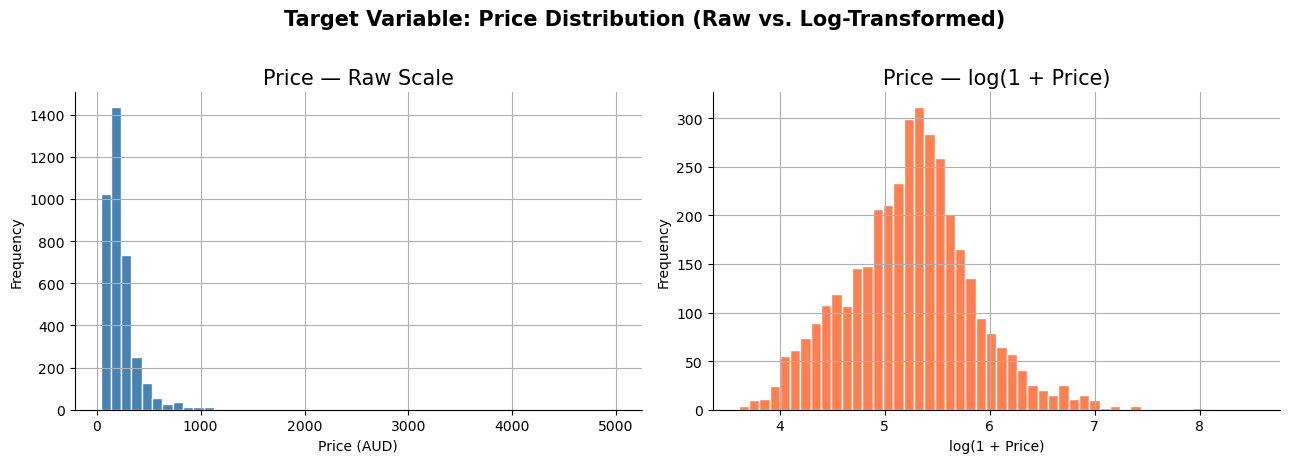

In [4]:
# Price is cleaned here for visualisation only (full cleaning in Task 2)
df_train['price'] = (
    df_train['price'].astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

# Summary statistics for price
print("Summary statistics — price")
display(df_train['price'].describe().round(2))
print(f"\nSkewness: {df_train['price'].skew():.2f}")

# Price distribution: raw vs. log-transformed
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df_train['price'].dropna().hist(ax=axes[0], bins=50, edgecolor='white', color='steelblue')
axes[0].set_title("Price — Raw Scale", fontsize=15)
axes[0].set_xlabel("Price (AUD)"); axes[0].set_ylabel("Frequency")
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

np.log1p(df_train['price'].dropna()).hist(ax=axes[1], bins=50, edgecolor='white', color='coral')
axes[1].set_title("Price — log(1 + Price)", fontsize=15)
axes[1].set_xlabel("log(1 + Price)"); axes[1].set_ylabel("Frequency")
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle("Target Variable: Price Distribution (Raw vs. Log-Transformed)",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**Summary:**

- `Price` is strongly right-skewed (skewness = 7.48), with most listings concentrated at the lower end and a long tail of high-priced properties. The mean (AUD 230) sits well above the median (AUD 193), confirming that a small number of expensive listings pull the average upward.
- Nightly prices range from AUD 36 to AUD 5,000, a very wide spread that reflects the mix of budget private rooms and luxury entire homes in the Brisbane market. The interquartile range (AUD 129 to AUD 267) shows that the central half of listings is priced far more modestly, well below the maximum.
- The raw distribution is highly concentrated near the low end, with very few listings above AUD 1,000, making it difficult to model directly. Applying a log transformation (log(1 + price)) produces a far more symmetric, approximately bell-shaped distribution, which is better suited to modelling and aligns with the proportional MAPE metric. This motivates the log-transformation of the target used in later modelling.

**4.2 Numerical Variables**

A selection of numerical features is examined to illustrate the main distributional characteristics of the training data, using summary statistics, skewness, and histograms.

Summary statistics — numerical features


,count,mean,std,min,25%,50%,75%,max
accommodates,3735.0,3.70,2.31,1.0,2.00,3.00,4.00,16.0
bedrooms,3733.0,1.76,1.11,0.0,1.00,1.00,2.00,9.0
availability_365,3735.0,198.40,119.51,0.0,83.00,192.00,322.00,365.0
host_listings_count,3733.0,50.07,111.88,1.0,1.00,5.00,32.00,702.0
number_of_reviews,3735.0,50.60,90.08,0.0,4.00,18.00,56.00,1130.0
review_scores_rating,3298.0,4.74,0.37,1.0,4.67,4.83,4.95,5.0



Skewness:
number_of_reviews       4.01
host_listings_count     3.52
accommodates            1.60
bedrooms                1.59
availability_365       -0.07
review_scores_rating   -4.83
dtype: float64


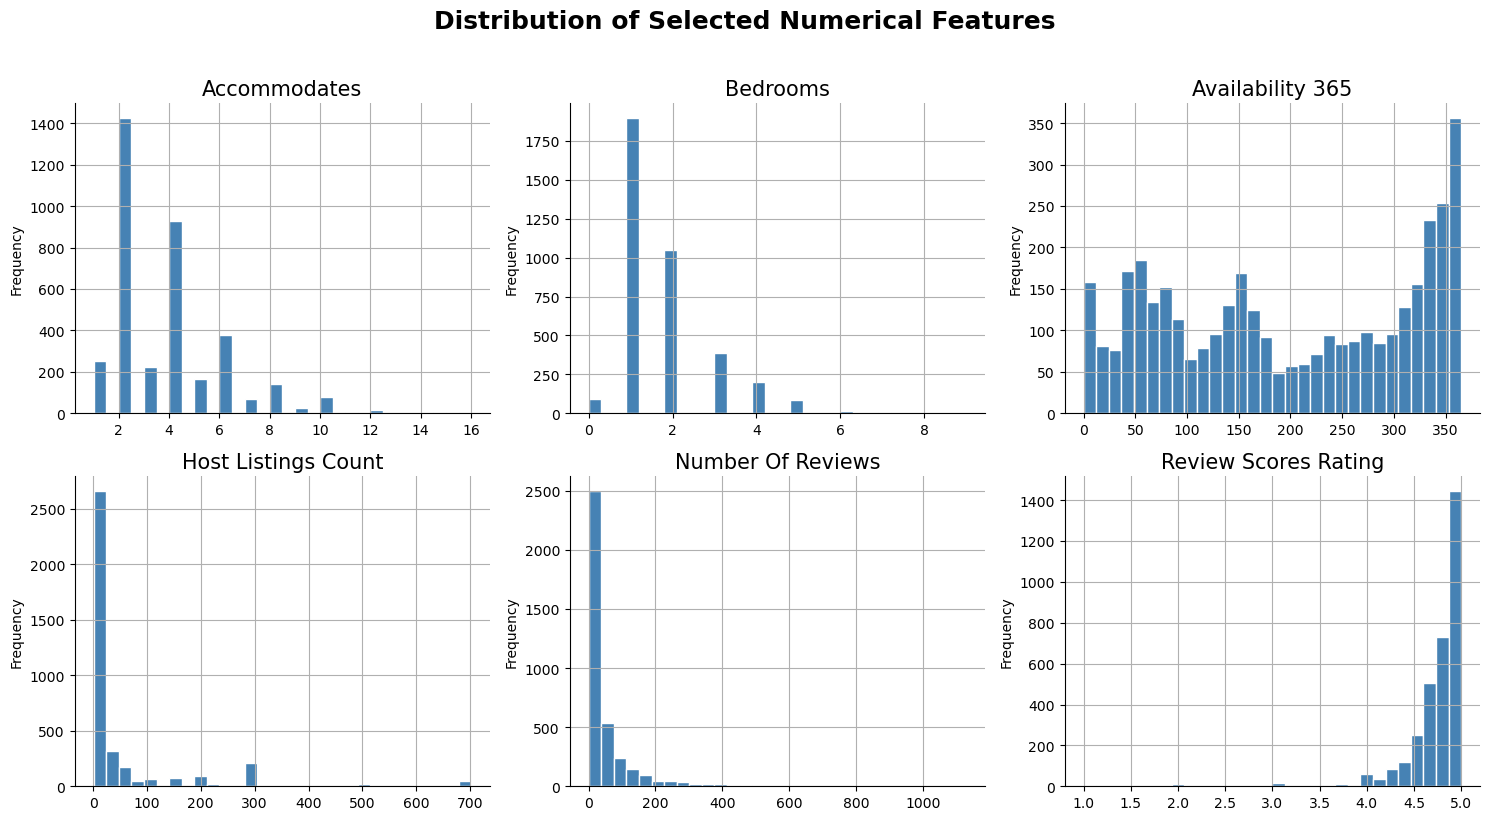

In [5]:
# Numerical Variables
numeric_cols = ['accommodates', 'bedrooms', 'availability_365',
                'host_listings_count', 'number_of_reviews',
                'review_scores_rating']

print("Summary statistics — numerical features")
display(df_train[numeric_cols].describe().round(2).T)

print("\nSkewness:")
print(df_train[numeric_cols].skew().round(2).sort_values(ascending=False))

# Histograms: 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    df_train[col].dropna().hist(ax=ax, bins=30, edgecolor='white', color='steelblue')
    ax.set_title(col.replace('_', ' ').title(), fontsize=15)
    ax.set_ylabel("Frequency")
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle("Distribution of Selected Numerical Features", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**Summary:**

- Most count-based features are strongly right-skewed. `number_of_reviews` (skewness 4.01) and `host_listings_count` (3.52) both concentrate at low values with very long upper tails: the median listing has 18 reviews but the maximum is 1,130, and the median host has 5 listings while the largest manages 702. This reflects a market of mostly small individual hosts alongside a few large commercial operators.

- `accommodates` (skewness 1.60) and `bedrooms` (1.59) are more moderately right-skewed and capture property capacity. Most listings are small, with a median of 3 guests and 1 bedroom, while larger properties (up to 16 guests and 9 bedrooms) form a thin upper tail. These capacity features are typically among the more informative predictors of price.

- `availability_365` is the most evenly spread feature (skewness −0.07, mean 198 days) and is roughly bimodal: many listings are available for only part of the year while a substantial group is available for nearly all 365 days. This reflects a mix of casual, part-time hosts and full-time commercial listings.

- `review_scores_rating` is strongly left-skewed (skewness −4.83), the opposite of the count features. Ratings cluster tightly near the maximum (median 4.83, 75th percentile 4.95, maximum 5.0), with only a few poorly-rated listings. This ceiling effect is typical of online review systems and limits the variable's power to distinguish between listings.

**4.3 Categorical Variables**

A selection of categorical features is examined using value counts and proportion charts to describe the composition of the listings. These cover the type of accommodation (`room_type`, `property_type`) and key host and booking attributes (`host_is_superhost`, `instant_bookable`).

=== room_type ===


,count,percent
room_type,,
Entire home/apt,2854,76.4
Private room,875,23.4
Shared room,4,0.1
Hotel room,2,0.1


Total unique: 4

=== property_type ===


,count,percent
property_type,,
Entire rental unit,1804,48.3
Entire home,596,16.0
Private room in home,513,13.7
Private room in rental unit,196,5.2
Entire guest suite,122,3.3
Entire serviced apartment,96,2.6
Entire guesthouse,88,2.4
Entire condo,50,1.3
Entire townhouse,41,1.1


Total unique: 41 (showing top 10)

=== host_is_superhost ===


,count,percent
host_is_superhost,,
f,2323,62.2
t,1275,34.1
NaN,137,3.7


Total unique: 2

=== instant_bookable ===


,count,percent
instant_bookable,,
f,2516,67.4
t,1219,32.6


Total unique: 2



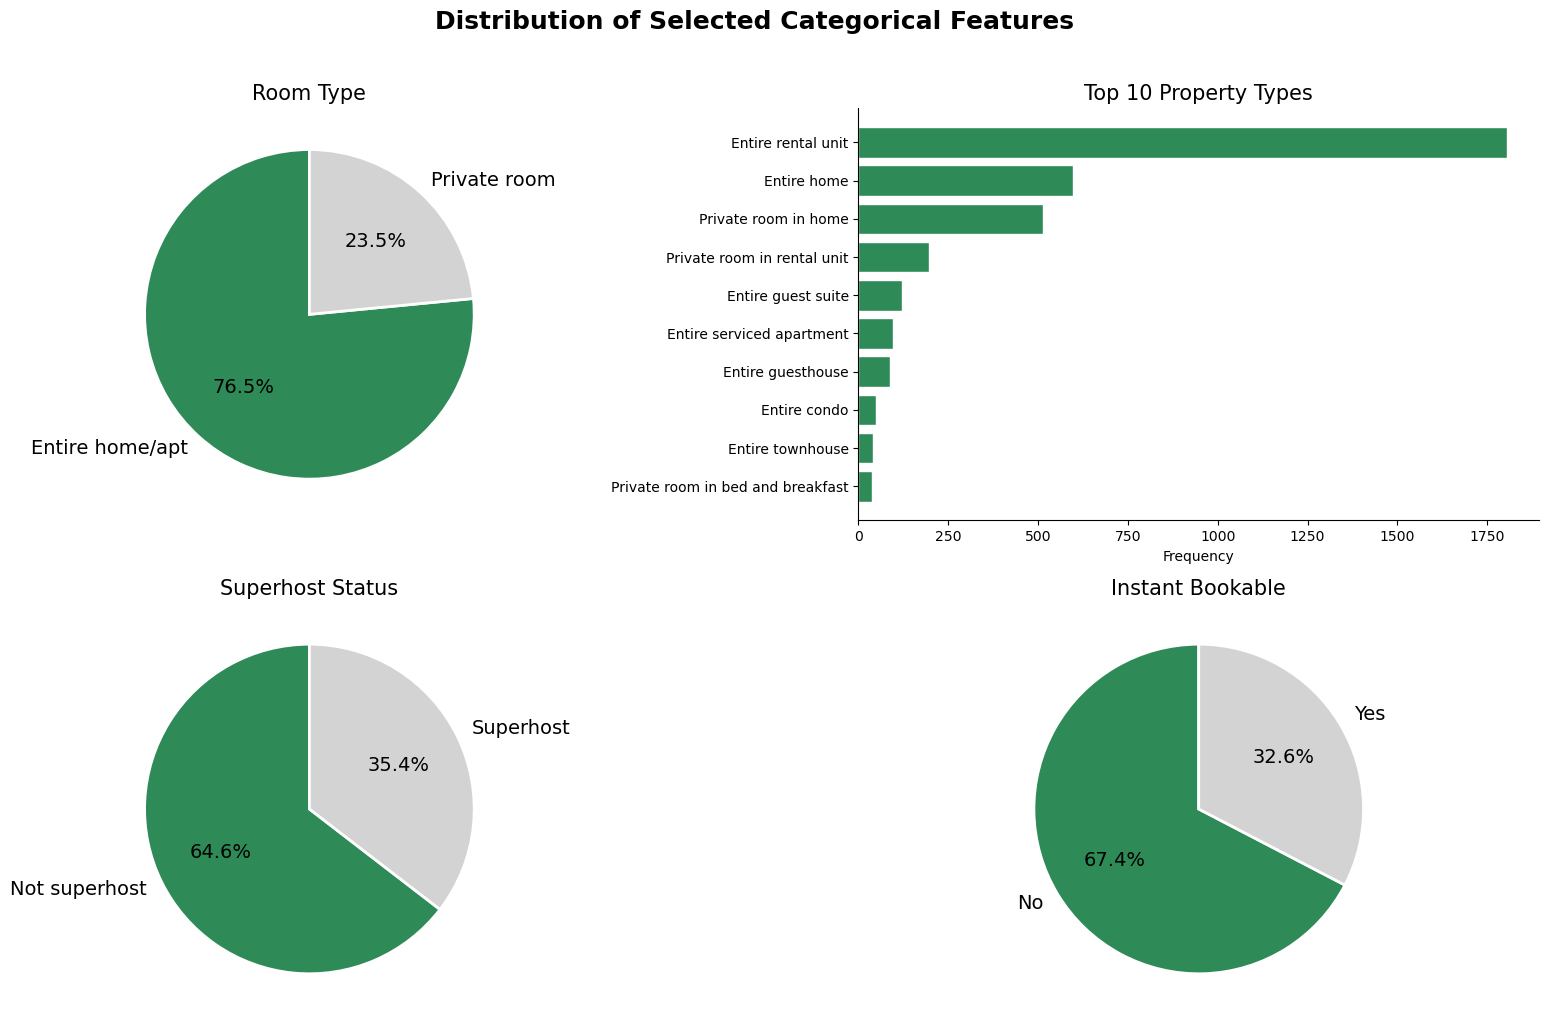

In [6]:
for col in ['room_type', 'property_type', 'host_is_superhost', 'instant_bookable']:
    print(f"=== {col} ===")
    vc = df_train[col].value_counts(dropna=False)
    pct = (vc / len(df_train) * 100).round(1)
    summary = pd.DataFrame({'count': vc, 'percent': pct})
    if len(summary) > 10:
        display(summary.head(10))                       # top 10 for high-cardinality
        print(f"Total unique: {df_train[col].nunique()} (showing top 10)\n")
    else:
        display(summary)
        print(f"Total unique: {df_train[col].nunique()}\n")   # show total for all features
        
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (1) Room type — pie (top 2) (Shared/Hotel rooms <0.2%, omitted for clarity)
room_counts = df_train['room_type'].value_counts().head(2)
axes[0, 0].pie(room_counts.values, labels=room_counts.index, autopct='%1.1f%%',
               startangle=90, colors=['seagreen', 'lightgray'],
               wedgeprops={'edgecolor': 'white', 'linewidth': 2}, textprops={'fontsize': 14})
axes[0, 0].set_title("Room Type", fontsize=15)

# (2) Property type — horizontal bar (top 10) (41 types total; long tail of rare types omitted)
top_property = df_train['property_type'].value_counts().head(10)
axes[0, 1].barh(top_property.index[::-1], top_property.values[::-1],
                color='seagreen', edgecolor='white')
axes[0, 1].set_title("Top 10 Property Types", fontsize=15)
axes[0, 1].set_xlabel("Frequency")
axes[0, 1].spines['top'].set_visible(False); axes[0, 1].spines['right'].set_visible(False)

# (3) Superhost status — pie
superhost_counts = df_train['host_is_superhost'].value_counts()
superhost_labels = superhost_counts.index.map({'t': 'Superhost', 'f': 'Not superhost'})
axes[1, 0].pie(superhost_counts.values, labels=superhost_labels, autopct='%1.1f%%',
               startangle=90, colors=['seagreen', 'lightgray'],
               wedgeprops={'edgecolor': 'white', 'linewidth': 2}, textprops={'fontsize': 14})
axes[1, 0].set_title("Superhost Status", fontsize=15)

# (4) Instant bookable — pie
instant_counts = df_train['instant_bookable'].value_counts()
instant_labels = instant_counts.index.map({'t': 'Yes', 'f': 'No'})
axes[1, 1].pie(instant_counts.values, labels=instant_labels, autopct='%1.1f%%',
               startangle=90, colors=['seagreen', 'lightgray'],
               wedgeprops={'edgecolor': 'white', 'linewidth': 2}, textprops={'fontsize': 14})
axes[1, 1].set_title("Instant Bookable", fontsize=15)

plt.suptitle("Distribution of Selected Categorical Features", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**Summary:**

- `room_type` is dominated by entire properties: 76% of listings are "Entire home/apt" (2,854), with most of the remainder being "Private room" (875, 23%). "Shared room" (4) and "Hotel room" (2) together make up under 0.2% of listings, so the chart focuses on the two dominant categories. The market is therefore overwhelmingly made up of whole-property rentals rather than shared spaces, which has clear pricing implications, as entire homes typically command higher rates.

- `property_type` has high cardinality (41 distinct values) but is heavily concentrated in a few categories, so the chart shows only the ten most common. "Entire rental unit" (1,804) and "Entire home" (596) alone account for roughly two-thirds of listings, while the long tail of rarer types (e.g. guesthouses, townhouses) is sparse. This concentration justifies grouping infrequent categories during preprocessing to avoid sparse, noisy features.

- `host_is_superhost` shows that most hosts are not superhosts: among the 3,598 non-missing listings, 65% are flagged "f" (2,323) and 35% "t" (1,275), with a further 137 values missing and excluded from the chart. Superhost status is therefore a minority but meaningful signal of host quality.

- `instant_bookable` is similarly imbalanced, with 67% of listings not instantly bookable (2,516) versus 33% that are (1,219). Per the data dictionary, instant bookability is treated by Airbnb as an indicator of a commercial listing, so this split offers a rough signal of the share of professionally-managed properties.

**4.4 Geographic Distribution**

The spatial distribution of listings is examined by plotting each property's `latitude` and `longitude` on a map of Brisbane, to describe where listings are located across the region.

In [7]:
# Geographic distribution of listings
fig = px.scatter_mapbox(
    df_train, lat="latitude", lon="longitude",
    hover_name="name", zoom=9, height=600,
    title="Geographic Distribution of Listings"
)
fig.update_layout(mapbox_style="open-street-map", margin={"r":0, "t":40, "l":0, "b":0})
fig.show()

**Summary:**

- Listings are heavily concentrated in central Brisbane, with the densest cluster in the CBD and surrounding inner suburbs. Density decreases steadily with distance from the centre, thinning out toward the western (Ipswich) and northern (Strathpine, Redcliffe) fringes, with a secondary spread extending south toward Logan City.

- Only a small number of listings appear near the bay and outlying coastal areas, so coastal listings are sparse rather than forming a major cluster.
  
- This strongly centre-weighted distribution indicates that proximity to the city centre is a key spatial characteristic of the market, and motivates the location-based features (distance to the city centre and geographic clustering) developed in the feature engineering section.

#### 5. Feature Analysis and Selection


**5.1 Feature Classification Table**

The raw dataset contains 64 candidate columns. From these, 27 meaningful features were selected and classified by their original variable type. In addition to standard numeric, ordinal, and nominal types, separate Datetime / Temporal and Text categories are used for fields that do not fit naturally into those three types.

| Variable Type | Count | Feature Names |
|---|---|---|
| Numeric | 16 | `accommodates`, `bedrooms`, `beds`, `bathrooms`, `latitude`, `longitude`, `availability_365`, `minimum_nights`, `number_of_reviews`, `reviews_per_month`, `review_scores_rating`, `host_listings_count`, `host_response_rate`, `host_acceptance_rate`, `estimated_occupancy_l365d`, `estimated_revenue_l365d` |
| Datetime / Temporal | 3 | `host_since`, `first_review`, `last_review` |
| Ordinal | 1 | `host_response_time` |
| Nominal | 5 | `room_type`, `property_type`, `host_is_superhost`, `host_identity_verified`, `instant_bookable` |
| Text | 2 | `bathrooms_text`, `amenities` |
| **Total** | **27** | |

**5.2 Relationship Between Key Features and Price**

The relationship between the selected features and price is examined using methods appropriate to each variable type. Numeric features are assessed using a correlation matrix, while nominal features are assessed using box plots of the price distribution within each category.

**5.2.1 Numeric Features**

Correlation of each feature with price, sorted:
accommodates                 0.52
bedrooms                     0.50
beds                         0.49
bathrooms                    0.42
estimated_revenue_l365d      0.26
latitude                     0.12
host_listings_count          0.08
longitude                    0.06
review_scores_rating         0.05
availability_365             0.01
minimum_nights               0.01
number_of_reviews           -0.08
host_response_rate          -0.08
reviews_per_month           -0.09
host_acceptance_rate        -0.09
estimated_occupancy_l365d   -0.11
Name: price, dtype: float64


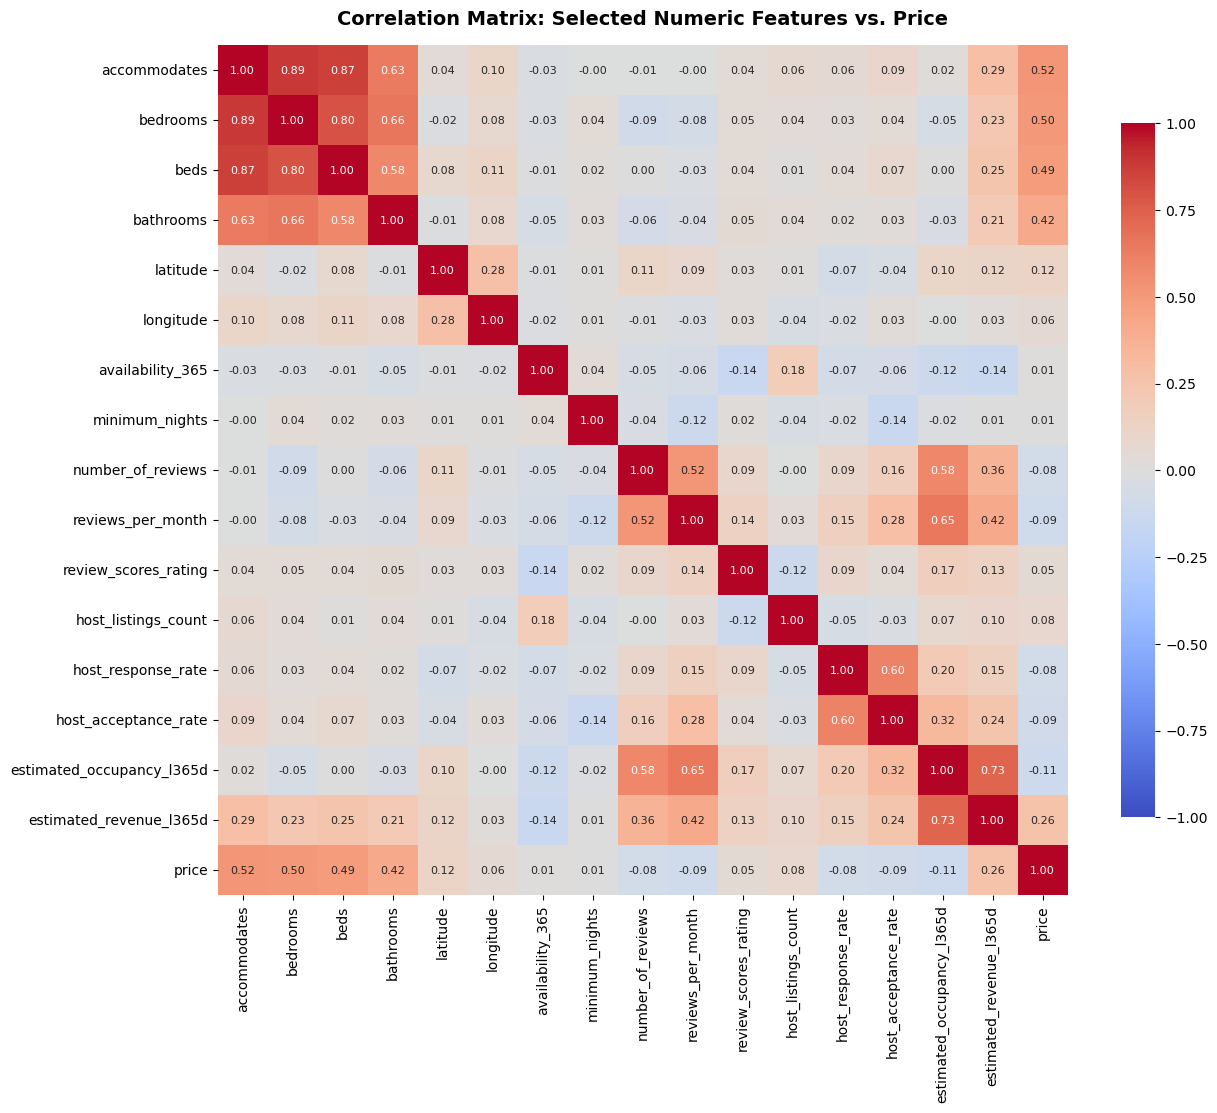

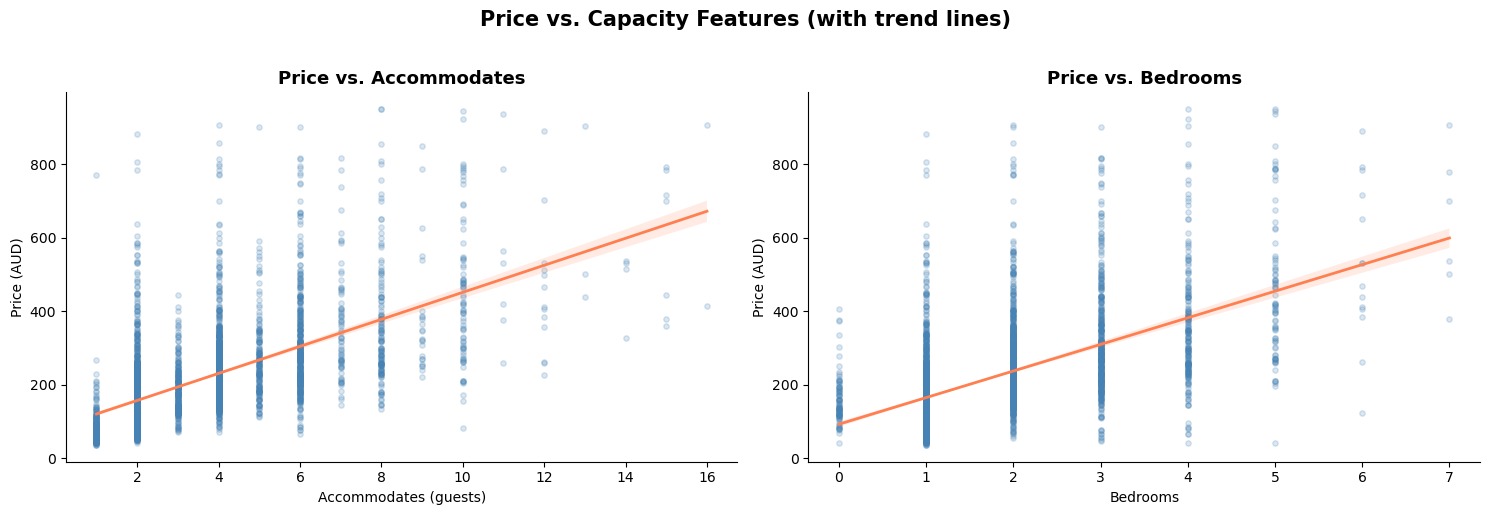

In [8]:
# The 16 numeric features selected in 5.1
numeric_feats = ['accommodates', 'bedrooms', 'beds', 'bathrooms',
                 'latitude', 'longitude', 'availability_365', 'minimum_nights',
                 'number_of_reviews', 'reviews_per_month', 'review_scores_rating',
                 'host_listings_count', 'host_response_rate', 'host_acceptance_rate',
                 'estimated_occupancy_l365d', 'estimated_revenue_l365d']

# Work on a copy so the raw data is not modified (actual cleaning is done in Task 2)
tmp = df_train[numeric_feats].copy()

# host_response_rate and host_acceptance_rate are stored as text with a '%' sign
for col in ['host_response_rate', 'host_acceptance_rate']:
    tmp[col] = pd.to_numeric(tmp[col].astype(str).str.replace('%', '', regex=False), errors='coerce')

# Coerce remaining columns to numeric, and add the (already-cleaned) price column
tmp = tmp.apply(pd.to_numeric, errors='coerce')
tmp['price'] = df_train['price']

# Compute correlation matrix and print each feature's correlation with price
corr_matrix = tmp.corr()
print("Correlation of each feature with price, sorted:")
print(corr_matrix['price'].drop('price').round(2).sort_values(ascending=False))

# Heatmap of the full correlation matrix
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
ax.set_title("Correlation Matrix: Selected Numeric Features vs. Price",
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout(); plt.show()


# Clip top 1% of prices so extreme outliers don't distort the view
p99 = df_train['price'].quantile(0.99)
df_plot = df_train[df_train['price'] <= p99]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Price vs accommodates ---
sns.regplot(data=df_plot, x='accommodates', y='price',
            scatter_kws={'alpha': 0.2, 's': 15, 'color': 'steelblue'},
            line_kws={'color': 'coral', 'linewidth': 2}, ax=axes[0])
axes[0].set_title("Price vs. Accommodates", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Accommodates (guests)"); axes[0].set_ylabel("Price (AUD)")
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# --- Price vs bedrooms ---
sns.regplot(data=df_plot, x='bedrooms', y='price',
            scatter_kws={'alpha': 0.2, 's': 15, 'color': 'steelblue'},
            line_kws={'color': 'coral', 'linewidth': 2}, ax=axes[1])
axes[1].set_title("Price vs. Bedrooms", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Bedrooms"); axes[1].set_ylabel("Price (AUD)")
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle("Price vs. Capacity Features (with trend lines)",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**Summary:**

- Capacity features have the strongest correlation with price: `accommodates` (0.52), `bedrooms` (0.50), `beds` (0.49), and `bathrooms` (0.42). These are also strongly correlated with each other (e.g. `accommodates`–`bedrooms` at 0.89).

- `estimated_revenue_l365d` shows a moderate correlation (0.26).

- All other features (location, reviews, availability, host rates) show weak correlations with price (below 0.15).

- Correlation captures only linear relationships, so weakly-correlated features may still have non-linear associations with price.

**5.2.2 Nominal Features**

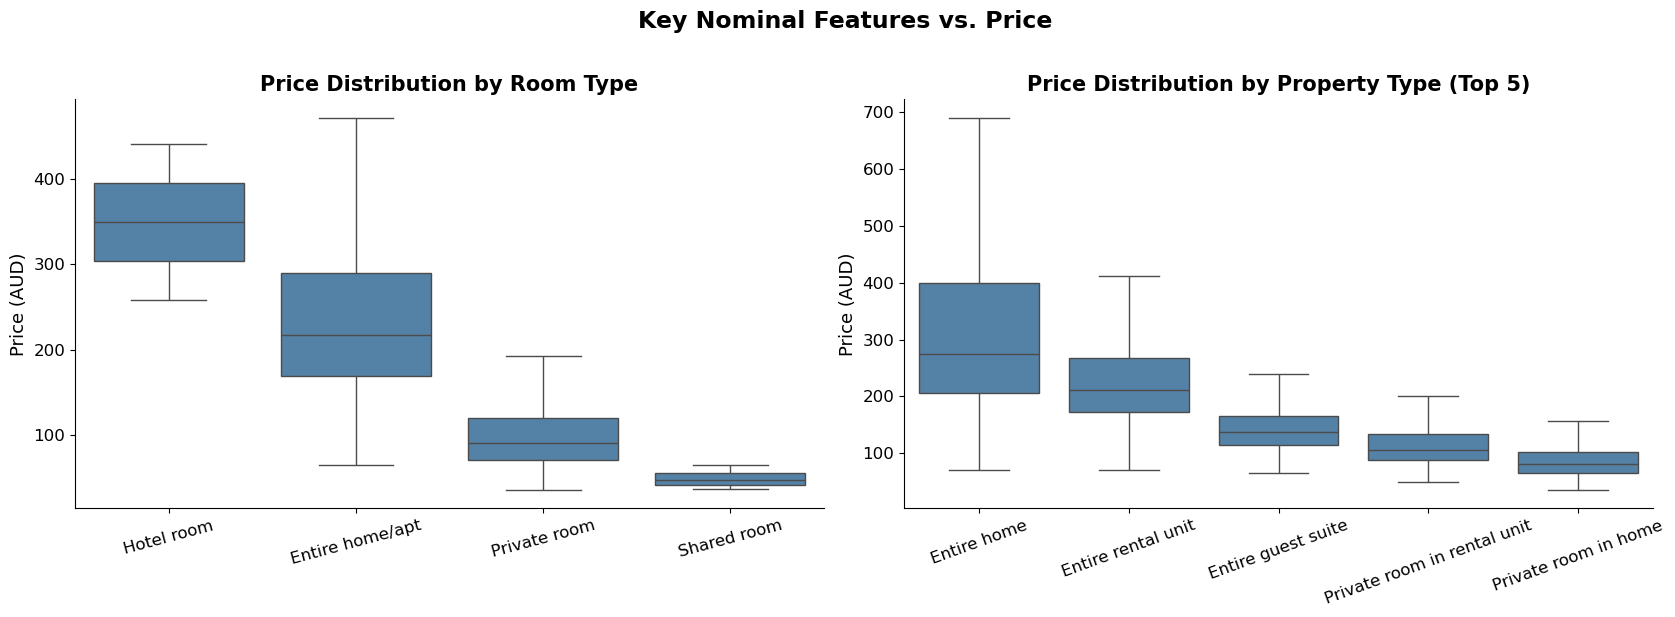

=== room_type ===


,median,count
room_type,,
Hotel room,350.0,2
Entire home/apt,217.0,2854
Private room,91.0,875
Shared room,48.0,4


Total unique: 4

=== property_type (top 5) ===


,median,count
property_type,,
Entire home,275.0,596
Entire rental unit,212.0,1804
Entire guest suite,138.0,122
Private room in rental unit,106.0,196
Private room in home,81.0,513


Total unique: 41 (showing top 5)


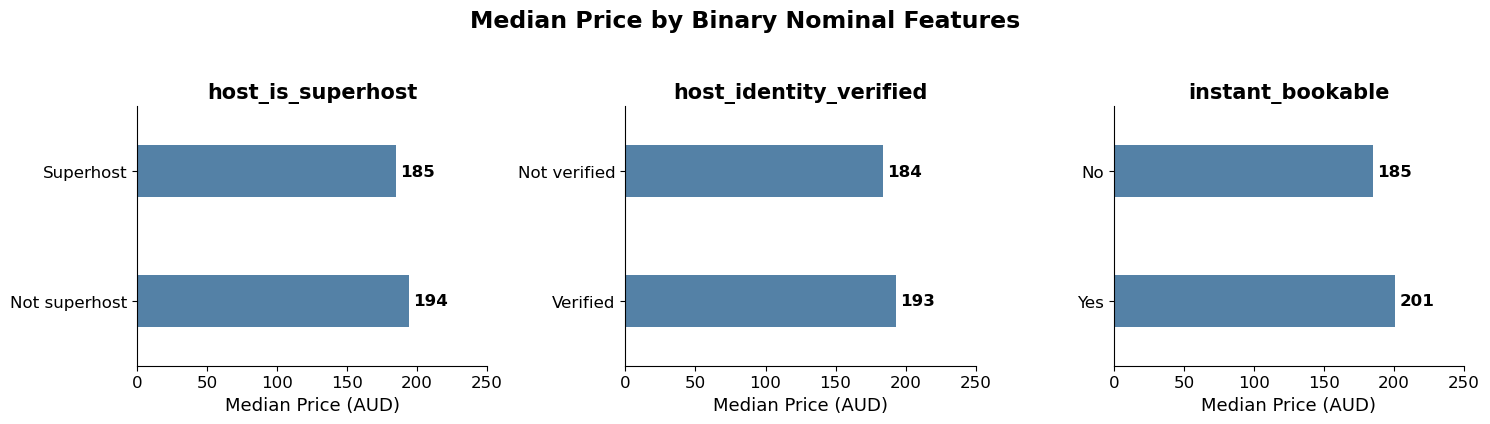

In [9]:
# Examine the key nominal features (room_type, property_type) and the binary features vs price
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# --- Price by room_type ---
order_rt = df_train.groupby('room_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_train, x='room_type', y='price', order=order_rt,
            color='steelblue', ax=axes[0], showfliers=False)   # hide outliers so boxes are readable
axes[0].set_title("Price Distribution by Room Type", fontsize=15, fontweight='bold')
axes[0].set_xlabel(""); axes[0].set_ylabel("Price (AUD)", fontsize=13)
axes[0].tick_params(axis='x', labelsize=12, rotation=15)        # rotate labels to avoid overlap
axes[0].tick_params(axis='y', labelsize=12)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# --- Price by property_type (top 5 most common) ---
top5 = df_train['property_type'].value_counts().head(5).index
df_pt = df_train[df_train['property_type'].isin(top5)]
order_pt = df_pt.groupby('property_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_pt, x='property_type', y='price', order=order_pt,
            color='steelblue', ax=axes[1], showfliers=False)
axes[1].set_title("Price Distribution by Property Type (Top 5)", fontsize=15, fontweight='bold')
axes[1].set_xlabel(""); axes[1].set_ylabel("Price (AUD)", fontsize=13)
axes[1].tick_params(axis='x', labelsize=12, rotation=20)
axes[1].tick_params(axis='y', labelsize=12)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle("Key Nominal Features vs. Price", fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


# Summary statistics: median price and listing count per category
print("=== room_type ===")
rt_stats = df_train.groupby('room_type')['price'].agg(['median', 'count']).sort_values('median', ascending=False)
display(rt_stats.round(0))
print(f"Total unique: {df_train['room_type'].nunique()}\n")

print("=== property_type (top 5) ===")
pt_stats = df_pt.groupby('property_type')['price'].agg(['median', 'count']).sort_values('median', ascending=False)
display(pt_stats.round(0))
print(f"Total unique: {df_train['property_type'].nunique()} (showing top 5)")


# Median price for the three binary nominal features (horizontal bar charts)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

label_maps = {
    'host_is_superhost':      {'t': 'Superhost', 'f': 'Not superhost'},
    'host_identity_verified': {'t': 'Verified',  'f': 'Not verified'},
    'instant_bookable':       {'t': 'Yes',       'f': 'No'},
}

for ax, col in zip(axes, label_maps):
    med = df_train.groupby(col)['price'].median().sort_values(ascending=True)
    labels = [label_maps[col][idx] for idx in med.index]
    sns.barplot(x=med.values, y=labels, color='steelblue', width=0.4, ax=ax, orient='h')  # thinner bars
    ax.set_title(col, fontsize=15, fontweight='bold')
    ax.set_xlabel("Median Price (AUD)", fontsize=13); ax.set_ylabel("")
    ax.set_xlim(0, 250)
    ax.tick_params(axis='both', labelsize=12)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for i, v in enumerate(med.values):
        ax.text(v + 3, i, f"{v:.0f}", va='center', fontsize=12, fontweight='bold')

plt.suptitle("Median Price by Binary Nominal Features", fontsize=17, fontweight='bold', y=1.05)
plt.tight_layout(); plt.show()

**Summary:**

- `room_type` and `property_type` show a clear relationship with price: entire homes have much higher median prices (AUD 217 / 275) than private and shared rooms (AUD 48 to 106). Shared room (4 listings) and Hotel room (2) have too few listings for reliable comparison.

- The three binary features show only small differences in median price: `host_is_superhost` (194 vs 185), `host_identity_verified` (193 vs 184), and `instant_bookable` (201 vs 185).

**5.3 Feature Selection Justification**

The raw dataset contains 64 candidate columns, from which 27 features were selected. Features were excluded on four principled grounds:

1. **Identifiers and administrative fields** (`id`, `name`, `host_id`, `host_name`, `source`) were removed as features, as they carry no predictive information about price. The listing `id` is retained separately only to label predictions in the final submission file.
2. **Fields with severe missingness** were dropped as too incomplete to impute reliably, including `host_neighbourhood` (96% missing), `neighborhood_overview` (53%), and `host_about` (40%).
3. **Redundant near-duplicate variants** were reduced to a single representative to avoid multicollinearity. For example, `minimum_nights` was kept over the seven related night-policy columns, `availability_365` over the shorter availability windows, `number_of_reviews` over the time-windowed review counts, `host_listings_count` over the calculated host-listing variants, and `review_scores_rating` over six correlated sub-scores.
4. **Near-constant or low-signal fields** were excluded, including `host_has_profile_pic` (97.6% of hosts have a profile picture, leaving little variation) and `host_verifications` (a list of verification methods that adds little price signal).

<br>

The retained features were chosen to cover the main structural drivers of price, grouped as follows:

- **Capacity** (`accommodates`, `bedrooms`, `beds`, `bathrooms`, `bathrooms_text`): the strongest correlates with price (5.2.1), reflecting that larger properties command higher rates.
- **Accommodation type** (`room_type`, `property_type`): showed a clear price relationship (5.2.2), with entire homes priced well above private and shared rooms.
- **Location** (`latitude`, `longitude`): correlates weakly in raw form (0.12 and 0.06), but the effect of location on price is not linear in raw coordinates.
- **Host attributes** (`host_listings_count`, `host_response_rate`, `host_acceptance_rate`, `host_response_time`, `host_is_superhost`, `host_identity_verified`): capture host professionalism and reliability.
- **Availability and booking** (`availability_365`, `minimum_nights`, `instant_bookable`): capture how the listing is offered and booked.
- **Reviews** (`number_of_reviews`, `reviews_per_month`, `review_scores_rating`, `first_review`, `last_review`): capture listing popularity, reputation, and history.
- **Demand signals** (`estimated_occupancy_l365d`, `estimated_revenue_l365d`): reflect realised demand over the past year.
- **Host tenure and amenities** (`host_since`, `amenities`): capture host experience and the facilities offered.

Several retained features showed only a weak relationship with price in the analysis: the numeric host, availability, review, and demand features had low correlations with price (5.2.1), and the binary host and booking features showed only small differences in median price across categories (5.2.2). They were nonetheless retained, for three reasons. First, the correlation analysis measures only linear association, so features with weak correlation may still have non-linear relationships with price. Second, a feature with little effect on its own may still be informative in combination with others. Third, the tree-based and ensemble models used in this project can exploit such non-linear and interaction effects, which a simple correlation does not capture. Removing these features prematurely would risk discarding useful signal, so they are retained as candidates and reassessed during modelling.

Overall, the 27 selected features form a meaningful, non-redundant set spanning capacity, location, host characteristics, availability, reviews, and listing content, which is carried into Task 2 for cleaning and transformation.

---
---

## Task 2: Data Cleaning, Missing Observations and Feature Engineering

In [10]:
df_train_backup = df_train.copy()
df_test_backup = df_test.copy()

#### 1. Numerical Data Cleaning


**1.1 Identification of numerical columns with special characters**

We firstly discover which columns contain those characters `%`, `$` and `,` (comma) in both training and testing data.<br />
Note: The removal of `$` from the 'price' column and conversion from text to numerical value have been done in task 1 - 4.1.


In [11]:
# "$" in the 'price' column has been removed 
# and transformed from text to float in Task 1 - 4.1
# Here we try to find out which columns contain the "%" character.
pct_cols = []
for col in df_train.select_dtypes(include=['object']).columns:
    if df_train[col].dropna().astype(str).str.contains('%').any():
        pct_cols.append(col)
print(f"In training data, columns containing '%':\n {pct_cols}")
pct_cols = []
for col in df_test.select_dtypes(include=['object']).columns:
    if df_test[col].dropna().astype(str).str.contains('%').any():
        pct_cols.append(col)
print(f"In testing data, columns containing '%':\n {pct_cols}")
# Here we try to find out which columns contain the "%" character.
pct_cols = []
for col in df_train.select_dtypes(include=['object']).columns:
    if df_train[col].dropna().astype(str).str.contains(',').any():
        pct_cols.append(col)
print(f"In training data, columns containing ',':\n {pct_cols}")
pct_cols = []
for col in df_test.select_dtypes(include=['object']).columns:
    if df_test[col].dropna().astype(str).str.contains(',').any():
        pct_cols.append(col)
print(f"In testing data, columns containing ',':\n {pct_cols}")

In training data, columns containing '%':
 ['description', 'neighborhood_overview', 'host_about', 'host_response_rate', 'host_acceptance_rate']
In testing data, columns containing '%':
 ['description', 'neighborhood_overview', 'host_about', 'host_response_rate', 'host_acceptance_rate']
In training data, columns containing ',':
 ['name', 'description', 'neighborhood_overview', 'host_location', 'host_about', 'host_verifications', 'amenities']
In testing data, columns containing ',':
 ['name', 'description', 'neighborhood_overview', 'host_location', 'host_about', 'host_verifications', 'amenities']


In [12]:
# Review of data nature to decide which columns should be cleaned.
df_train.head(5)

,ID,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price
0,0,city scrape,The Nestt,Enjoy a memorable visit when you stay in this ...,NaN,38029254,Mark,2015-07-09,NaN,NaN,within an hour,100%,89%,t,NaN,8.0,"['email', 'phone', 'work_email']",t,t,Rocklea - Acacia Ridge,-27.557320,153.020270,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Hair dryer"", ""Hangers"", ""Fire extinguisher"",...",5,365,5.0,5.0,365.0,365.0,5.0,365.0,12,30,53,328,18,10,1,30,4,100,9700.0,2023-04-27,2025-10-25,4.56,4.61,4.44,4.78,4.61,4.28,4.50,f,8,8,0,0,0.58,97.0
1,1,city scrape,Bayside Bliss - By the Water & Near the Airport,"Relax by the water and close to the airport, B...",Wynnum is nestled along Brisbane's sunny south...,33488214,Claire,2015-05-16,"Wynnum, Australia",NaN,within an hour,100%,93%,t,NaN,1.0,"['email', 'phone']",t,t,Wynnum,-27.445790,153.179090,Entire guest suite,Entire home/apt,4,1.0,1 bath,2.0,3.0,"[""Laundromat nearby"", ""Refrigerator"", ""Bed lin...",1,14,1.0,1.0,14.0,14.0,1.0,14.0,14,15,45,110,16,8,1,14,10,48,9840.0,2024-06-16,2025-11-02,4.94,4.88,5.00,4.94,4.94,4.88,4.69,f,1,1,0,0,0.93,205.0
2,2,city scrape,Cozy 1 Bedroom Apartment with Infinity Pool,My stunning apartment is located in one of the...,Staying here allows you to experience the neve...,401146490,Hao,2021-05-11,NaN,"Roger and I love traveling, we fell in love wi...",within an hour,100%,100%,f,NaN,7.0,['phone'],t,t,Fortitude Valley,-27.456050,153.032450,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Refrigerator"", ""Essentials"", ""Dishwasher"", ""...",1,365,1.0,2.0,365.0,365.0,1.3,365.0,10,31,50,131,27,16,0,22,17,96,17856.0,2024-03-11,2025-10-11,4.70,4.70,4.67,4.70,4.81,4.67,4.56,t,7,7,0,0,1.33,186.0
3,3,city scrape,City Stay-Executive 1.5 Bedroom,Experience modern urban living in our stylish ...,NaN,83183834,John,2016-07-11,"Hamilton, Australia",NaN,within an hour,100%,100%,f,NaN,1.0,"['email', 'phone']",t,t,Newstead - Bowen Hills,-27.451701,153.035454,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,2.0,"[""Outdoor shower"", ""Exercise equipment"", ""Refr...",21,730,21.0,21.0,730.0,730.0,21.0,730.0,0,0,0,224,0,0,0,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN,157.0
4,4,city scrape,Private Oasis! 3Bed/2Bath/1Car ~ 5mins to CBD,Brisbane inner-city living at its best! <br />...,Location (walking)<br /><br />•\t1 min e-Scoot...,3384506,Andy,2012-08-27,"Brisbane, Australia",Brisbane’s Leading Property Management Company...,within an hour,100%,97%,t,NaN,155.0,"['email', 'phone']",t,t,Fortitude Valley,-27.458774,153.038180,Entire rental unit,Entire home/apt,6,2.0,2 baths,3.0,3.0,"[""Refrigerator"", ""Stainless steel single oven""...",7,365,2.0,7.0,365.0,1125.0,6.2,746.0,7,18,31,31,23,23,3,17,0,255,76500.0,2025-04-09,2025-11-09,4.74,4.87,4.87,4.78,4.87,4.83,4.57,f,132,132,0,0,3.18,300.0


Among those columns, those special characters should only be removed from numerical columns but not the descriptive text columns.
So the `%` should be removed from `host_response_rate` & `host_acceptance_rate` columns and those columns should be converted from percentage value to float for data analysis. <br />
For the `,`(comma) character, it can be kept in those descriptive text columns. The `host_verification` and `amenities` columns contain data in array format so the comma characters do not need to be removed here.

In [13]:
# Remove '%' from the 'host_response_rate' and 'host_acceptance_rate' columns 
# and convert the percentage values to float. 
pct_cols = ['host_response_rate', 'host_acceptance_rate']
# Processing the columns
for col in pct_cols:
    # Remove %, convert to numeric, and scale
    df_train[col] = df_train[col].str.replace('%', '', regex=False).astype(float) / 100
    df_test[col] = df_test[col].str.replace('%', '', regex=False).astype(float) / 100

# Verification
print("\nData types after conversion:")
print(df_train[pct_cols].dtypes)
print("\nSample values (first 5 rows):")
print(df_train[pct_cols].head())
print("\nValue range check (Min/Max):")
print(df_train[pct_cols].agg(['min', 'max']))


Data types after conversion:
host_response_rate      float64
host_acceptance_rate    float64
dtype: object

Sample values (first 5 rows):
   host_response_rate  host_acceptance_rate
0                 1.0                  0.89
1                 1.0                  0.93
2                 1.0                  1.00
3                 1.0                  1.00
4                 1.0                  0.97

Value range check (Min/Max):
     host_response_rate  host_acceptance_rate
min                 0.0                   0.0
max                 1.0                   1.0


**1.2. Conversion of date columns**

By observtion, three columns `host_since`, `first_review`, and `last_review` should be converted to datetime format

In [14]:
# Identify date columns
date_cols = ['host_since', 'first_review', 'last_review']
print("Before datetime conversion:")
df_train[date_cols].info()
df_test[date_cols].info()
# Convert date columns from string to datetime
for col in date_cols:
    df_train[col] = pd.to_datetime(df_train[col], errors='coerce')
    df_test[col] = pd.to_datetime(df_test[col], errors='coerce')
print("After datetime conversion:")
df_train[date_cols].info()
df_test[date_cols].info()

Before datetime conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3735 entries, 0 to 3734
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   host_since    3733 non-null   object
 1   first_review  3298 non-null   object
 2   last_review   3298 non-null   object
dtypes: object(3)
memory usage: 87.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1601 entries, 0 to 1600
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   host_since    1601 non-null   object
 1   first_review  1418 non-null   object
 2   last_review   1418 non-null   object
dtypes: object(3)
memory usage: 37.7+ KB
After datetime conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3735 entries, 0 to 3734
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   host_since    3733 n

**1.3. Conversion of binary columns**

We observed some columns contain values `t` and `f` which should mean TRUE and FALSE.
For effective data analysis, we would like to convert `t`(TRUE) to numerical value 1 and `f`(FALSE) to numerical value 0.

In [15]:
# Identify binary columns containing 't' and 'f'
# by searching for columns where the unique values (excluding NaNs) are exactly {'t', 'f'} or a subset
binary_cols = []
for col in df_train.columns:
    unique_vals = set(df_train[col].dropna().unique())
    if unique_vals <= {'t', 'f'} and len(unique_vals) > 0:
        binary_cols.append(col)
print(f"Binary columns identified: {binary_cols}")

Binary columns identified: ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']


In [16]:
# Convert to numeric (t -> 1, f -> 0)
mapping = {'t': 1, 'f': 0}
for col in binary_cols:
    df_train[col] = df_train[col].map(mapping)
    df_test[col] = df_test[col].map(mapping)
# 3. Verify the changes
print("\nVerification - Data Types:")
print(df_train[binary_cols].dtypes)
print("\nVerification - Unique values after mapping:")
for col in binary_cols:
    print(f"{col}: {df_train[col].unique()}")
for col in binary_cols:
    print(f"{col}: {df_test[col].unique()}")


Verification - Data Types:
host_is_superhost         float64
host_has_profile_pic      float64
host_identity_verified    float64
instant_bookable            int64
dtype: object

Verification - Unique values after mapping:
host_is_superhost: [ 1.  0. nan]
host_has_profile_pic: [ 1.  0. nan]
host_identity_verified: [ 1.  0. nan]
instant_bookable: [0 1]
host_is_superhost: [ 0.  1. nan]
host_has_profile_pic: [1 0]
host_identity_verified: [1 0]
instant_bookable: [0 1]


**1.4. Host related missing values**

Firstly, we observed there are 2 <u>host related records</u> where the `host_since`, `host_identity_verified`, `host_has_profile_pic`, `host_name`, `host_verifications` and `host_listings_count` columns are blank. These missing values appear to be Missing Completely At Random (MCAR). To impute reasonable values, we investigated the 2 cases based on the `host_id`.

For `host_id`=3288516, there is only 1 record which is the one containing missing value.<br />
So the `host_listings_count` should contain the value 1.<br />
Looking into the `host_id` and `host_since`, it appears the `host_id` is incremented sequentially according to the `host_since` date. So the `host_since` date of this record should be imputed with the date in between the previous and the next `host_id`.<br />
The `host_identity_verified` and `host_has_profile_pic` columns are boolean value so the mode values would be imputed.<br />
The `host_name` and `host_verifications` (for administration use) are considered not useful for prediction so we would ignore these columns and drop those in later stages.

In [17]:
df_train[(df_train['host_id'] >= 3282487) & (df_train['host_id'] <= 3384506)][['host_id', 'host_since']].drop_duplicates().sort_values(by='host_id')

,host_id,host_since
891,3282487,2012-08-16
3602,3288516,NaT
4,3384506,2012-08-27


In [18]:
# Imputing the mean of 2012-08-16 and 2012-08-27 to the `host_since` date
df_train.loc[df_train['host_id'] == 3288516, 'host_since'] = pd.to_datetime(['2012-08-16', '2012-08-27']).mean().normalize()
# Imputing 1 to `host_listings_count` because this `host_id` only has 1 record
df_train.loc[df_train['host_id'] == 3288516, 'host_listings_count'] = 1
# Imputing mode values to `host_identity_verified` and `host_has_profile_pic`
df_train.loc[df_train['host_id'] == 3288516, 'host_identity_verified'] = df_train['host_identity_verified'].mode()[0]
df_train.loc[df_train['host_id'] == 3288516, 'host_has_profile_pic'] = df_train['host_has_profile_pic'].mode()[0]

In [19]:
df_train[(df_train['host_id'] >= 3282487) & (df_train['host_id'] <= 3384506)][['host_id', 'host_since']].drop_duplicates().sort_values(by='host_id')

,host_id,host_since
891,3282487,2012-08-16
3602,3288516,2012-08-21
4,3384506,2012-08-27


For `host_id`=23370004, there is also only 1 record which is the one containing missing value.<br />
So the `host_listings_count` should contain the value 1.<br />
The `host_since` date is likely be 2014-11-05 because the `host_since` date of the previous and next `host_id` are the same.<br />
The `host_identity_verified` and `host_has_profile_pic` columns are boolean value so the mode values would be imputed.<br />
The `host_name` and `host_verification` (for administration use) are considered not useful for prediction so we would ignore these columns and drop those in later stages.

In [20]:
df_train[(df_train['host_id'] >= 23361729) & (df_train['host_id'] <= 23395016)][['host_id', 'host_since']].drop_duplicates().sort_values(by='host_id')

,host_id,host_since
723,23361729,2014-11-05
2738,23370004,NaT
22,23395016,2014-11-05


In [21]:
# Imputing the mean of 2014-11-05 to the `host_since` date
df_train.loc[df_train['host_id'] == 23370004, 'host_since'] = pd.to_datetime('2014-11-05')
# Imputing 1 to `host_listings_count` because this `host_id` only has 1 record
df_train.loc[df_train['host_id'] == 23370004, 'host_listings_count'] = 1
# Imputing mode values to `host_identity_verified` and `host_has_profile_pic`
df_train.loc[df_train['host_id'] == 23370004, 'host_identity_verified'] = df_train['host_identity_verified'].mode()[0]
df_train.loc[df_train['host_id'] == 23370004, 'host_has_profile_pic'] = df_train['host_has_profile_pic'].mode()[0]

In [22]:
df_train[(df_train['host_id'] >= 23361729) & (df_train['host_id'] <= 23395016)][['host_id', 'host_since']].drop_duplicates().sort_values(by='host_id')

,host_id,host_since
723,23361729,2014-11-05
2738,23370004,2014-11-05
22,23395016,2014-11-05


<hr style="width:25%;margin-left:0;">

#### 2. Feature Engineering


**2.1. Transformation of date columns to number of days features**

| Original Feature | Description of Original Feature | New Feature | Description of New Feature |
|---|---|---|---|
|`host_since`| The date the host/user was created. | `host_since_days` | Number of days from the `host_since` date to the data extraction date |
|`first_review`| The date of the first/oldest review | `first_review_days` | Number of days from the `first_review` date to the data extraction date |
|`last_review`| The date of the last/newest review | `last_review_days` | Number of days from the `last_review` date to the data extraction date |

In [23]:
# Assume the dataset extraction date is equal the latest date of the `last_review` date.
data_date = df_train['last_review'].max()
print("Dataset date :",data_date)

# for training data
df_train['host_since_days'] = (data_date - df_train['host_since']).dt.days
df_train['first_review_days'] = (data_date - df_train['first_review']).dt.days
df_train['last_review_days'] = (data_date - df_train['last_review']).dt.days
# for testing data
df_test['host_since_days'] = (data_date - df_test['host_since']).dt.days
df_test['first_review_days'] = (data_date - df_test['first_review']).dt.days
df_test['last_review_days'] = (data_date - df_test['last_review']).dt.days

Dataset date : 2025-11-11 00:00:00


**2.2. Word count of text fields**

Text columns `description` and `neighborhood_overview` are firstly cleaned by removing HTML codes and special unicode (e.g. '\\u2019', '\2013'). Then the following word count features are extracted.

| Original Feature | Description of Original Feature | New Feature | Description of New Feature |
|---|---|---|---|
|`description`| Detailed description of the listing. | `description_word_count` | Number of words in `description` column |
|`neighborhood_overview`| Host's description of the neighbourhood | `neighborhood_overview_word_count` | Number of words in `neighborhood_overview` column |

In [24]:
# A function to clean up text field: 'description' & 'neighborhood_overview'
# - Keep only alphabets and numbers
# - Change other characters to SPACE " ".
def clean_description(text):
    if not isinstance(text, str):
        return ""
    # Unescape HTML (e.g. &amp; <br/>)
    text = html.unescape(text)
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', " ", text)
    # Keep only alphanumeric, spaces, and basic punctuation
    #text = re.sub(r'[^a-zA-Z0-9\s.,!?;:\'\"-/]', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', " ", text)
    # Remove \\u2019, \2013, etc.
    # Remove extra whitespace
    return re.sub(r'\s+', " ", text).strip()

# A function to count words split by a SPACE " "
def count_words(text):
    if pd.isna(text) or text == "":
        return 0
    # .split() handles multiple spaces and line breaks automatically
    return len(str(text).split())

# Train data - Create new columns to store the cleaned text
df_train['description'] = df_train['description'].apply(clean_description)
df_train['neighborhood_overview'] = df_train['neighborhood_overview'].apply(clean_description)
# Create new columns to store the number of words in the desciption and neighborhood_overview
df_train['description_word_count'] = df_train['description'].apply(count_words)
df_train['neighborhood_overview_word_count'] = df_train['neighborhood_overview'].apply(count_words)

# Test data - Create new columns to store the cleaned text
df_test['description_cleaned'] = df_test['description'].apply(clean_description)
df_test['neighborhood_overview'] = df_test['neighborhood_overview'].apply(clean_description)
# Create new columns to store the number of words in the desciption and neighborhood_overview
df_test['description_word_count'] = df_test['description'].apply(count_words)
df_test['neighborhood_overview_word_count'] = df_test['neighborhood_overview'].apply(count_words)

**2.3. Amenity features**

The `amenities` column is firstly cleaned by removing special unicode (e.g. '\\u2019', '\2013') and then changed to lower case.

Based on the cleaned `amenities` value, a full list of individual amenity existing among all records is extracted with a calculated average price of the Airbnb listing (referring to the tutorial of week 10). The average price range is then divided into 3 categories (high/mid/low) meaning the amenity provided by the listing may have correlation with the price. 

For the records in training and testing data, we would then create 3 new features (`low_amenities_count`, `mid_amenities_count` and `hight_amenities_count`) counting the number of high, mid and low price amenities provided by the listing.

In [25]:
# A function to clean up text field: 'amenities'
# - Keep only alphabets and numbers
# - Change other characters to SPACE " ".
def clean_amenities(text):
    if not isinstance(text, str):
        return ""
    # This regex looks for a literal backslash followed by 'u' 
    # and then exactly 4 alphanumeric characters (the hex code).
    # We replace it with an empty string (or a space if you prefer).
    text = re.sub(r'\\u[0-9a-fA-F]{4}', '', text)
    return re.sub(r'\s+', " ", text).strip().lower() #change to lower case

# Train data - Create new columns to store the cleaned text
df_train['amenities'] = df_train['amenities'].apply(clean_amenities)
# Test data - Create new columns to store the cleaned text
df_test['amenities'] = df_test['amenities'].apply(clean_amenities)


In [26]:
# Parse amenities into Python lists
def parse_amenities(text):
    if not isinstance(text, str): # If the input variable is not string, exit
        return []
    try:
        return ast.literal_eval(text.lower()) # Convert to a proper list with content in lower case
    except (ValueError, SyntaxError):
        return []

for df in [df_train, df_test]:
    df['amenities_list'] = df['amenities'].apply(parse_amenities)
    df['amenities_count'] = df['amenities_list'].apply(len) # Counting by len function

# Build amenity price ranking from TRAINING data only (to avoid leakage)
df_exploded = df_train[['price', 'amenities_list']].explode('amenities_list')
df_exploded = df_exploded.dropna(subset=['amenities_list', 'price'])

df_amenity_stats = (
    df_exploded.groupby('amenities_list')
    .agg(avg_price=('price', 'mean'), count=('price', 'count'))
    .reset_index()
)
print(df_amenity_stats.sort_values(by='count', ascending=False).head(5)) # Check the amenities_list
print("Total number of amenities in training data =",len(df_amenity_stats))
#df_amenity_stats.to_excel("nick_data/amenity_price2.xlsx") # For checking

             amenities_list   avg_price  count
1245            smoke alarm  231.032231   3568
824                 kitchen  234.007198   3473
1394                   wifi  231.739296   3410
741               hot water  226.049617   3003
434   dishes and silverware  233.411450   2987
Total number of amenities in training data = 1434


In [27]:
# define threshold for keeping the amenities to..
# 1. avoids noise from rare items
lower_bound = 30 #len(df_train)*0.02
# 2. avoids common items which provided by most listings
upper_bound = len(df_train)*0.7

# Keep only amenities appearing in >=30 listings (avoids noise from rare items)
amenity_stats = df_amenity_stats[(df_amenity_stats['count'] >= lower_bound) & (df_amenity_stats['count'] <= upper_bound)].copy()
#amenity_stats.sort_values(by='count', ascending=False)

Amenity groups: low=64, mid=63, high=65

=== Top 20 highest-price amenities ===
                                            amenities_list  avg_price  count
                                          indoor fireplace 428.864407     59
                                               lake access 381.711111     45
                                              beach access 371.864865     37
              free residential garage on premises 2 spaces 368.906250     32
                                   pack n play/travel crib 364.052632    190
                                                ev charger 351.935484     31
                                                      crib 349.675070    357
                                         baby safety gates 343.312500     48
                                           outdoor kitchen 339.754386     57
                                                 baby bath 334.526316     38
                                       children's playroom 328.739130    

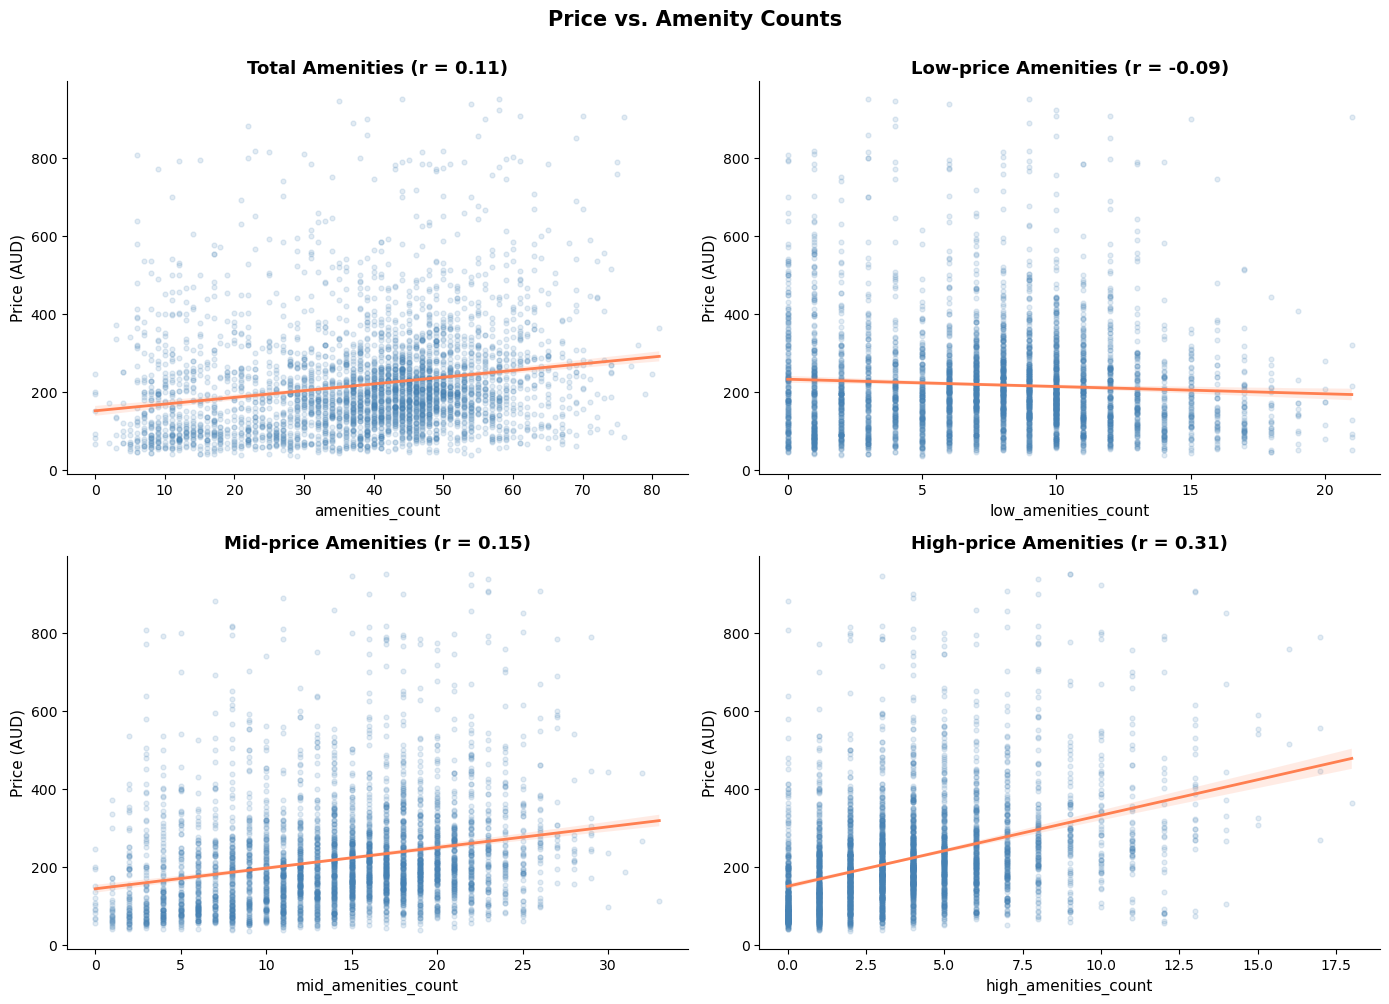

In [28]:
# Tertile cut-offs based on training data
q33 = amenity_stats['avg_price'].quantile(0.33)
q66 = amenity_stats['avg_price'].quantile(0.66)

low_set  = set(amenity_stats.loc[amenity_stats['avg_price'] <= q33, 'amenities_list'])
mid_set  = set(amenity_stats.loc[(amenity_stats['avg_price'] > q33) & (amenity_stats['avg_price'] <= q66), 'amenities_list'])
high_set = set(amenity_stats.loc[amenity_stats['avg_price'] > q66, 'amenities_list'])

# Apply group counts to both datasets
for df in [df_train, df_test]:
    df['low_amenities_count']  = df['amenities_list'].apply(lambda lst: sum(1 for a in lst if a in low_set))
    df['mid_amenities_count']  = df['amenities_list'].apply(lambda lst: sum(1 for a in lst if a in mid_set))
    df['high_amenities_count'] = df['amenities_list'].apply(lambda lst: sum(1 for a in lst if a in high_set))

# Drop original and intermediate columns
#for df in [df_train, df_test]:
    #df.drop(columns=['amenities', 'amenities_list'], inplace=True, errors='ignore')

# Verify: print group sizes and example amenities
new_features = ['amenities_count', 'low_amenities_count', 'mid_amenities_count', 'high_amenities_count']
print(f"Amenity groups: low={len(low_set)}, mid={len(mid_set)}, high={len(high_set)}")

top_high = amenity_stats.nlargest(20, 'avg_price')[['amenities_list', 'avg_price', 'count']]
top_low  = amenity_stats.nsmallest(20, 'avg_price')[['amenities_list', 'avg_price', 'count']]

print("\n=== Top 20 highest-price amenities ===")
print(top_high.to_string(index=False))
print("\n=== Top 20 lowest-price amenities ===")
print(top_low.to_string(index=False))

# VISUALISATION: Price vs each amenity count feature
# Clip top 1% of prices for visualisation clarity
p99 = df_train['price'].quantile(0.99)
df_plot = df_train[df_train['price'] <= p99]

titles = {
    'amenities_count':      'Total Amenities',
    'low_amenities_count':  'Low-price Amenities',
    'mid_amenities_count':  'Mid-price Amenities',
    'high_amenities_count': 'High-price Amenities'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), new_features):
    sns.regplot(data=df_plot, x=col, y='price',
                scatter_kws={'alpha': 0.15, 's': 12, 'color': 'steelblue'},
                line_kws={'color': 'coral', 'linewidth': 2},
                ax=ax)
    r = df_train[col].corr(df_train['price'])
    ax.set_title(f"{titles[col]} (r = {r:.2f})", fontsize=13, fontweight='bold')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Price (AUD)", fontsize=11)
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Price vs. Amenity Counts", fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

Rather than grouping all amenities in training data to 3 price tiers (high/mid/low), we also wish to extract individual amenities which may have a strong price signal. <br />
Here is the amenities selection and new feature creation process:

STEP 1. The selection process focuses on amenities appearing in at least 30 listing. The "lifting effect" is calculated based on the difference between the median price of listings providing this amenity and the median price of listings without this amenity.
STEP 2. Choose the amenities which has an absolute price lifting effect higher than the LIFT_THRESHOLD (25) and the number of listings above the COUNT_THRESHOLD (50).
STEP 3. Consider the list of amenities having significant lifting effect is like categorical variables, we create binary flags (like one-hot encoding) on both training and testing data to indicate whether the listing provides those amenities or not.



In [29]:
# ============================================================
# STEP 1: DATA-DRIVEN AMENITY ANALYSIS
# Compute the median price lift for every amenity that appears
# in at least 30 listings. This runs on df_train ONLY (no leakage).
# The results justify which amenities become features.
# ============================================================
from collections import Counter
import re

# Build a frequency table: how often does each amenity appear?
all_amenities = []
for amenity_list in df_train['amenities_list']:
    if isinstance(amenity_list, list):
        all_amenities.extend(amenity_list)

amenity_counts = Counter(all_amenities)

# For every amenity that appears in >= 30 listings, compute:
#   median price of listings WITH this amenity
#   median price of listings WITHOUT this amenity
#   lift = difference between the two
amenity_price_analysis = []

for amenity, count in amenity_counts.items():
    if count < 30:           # skip rare amenities (noisy estimate)
        continue

    has_amenity = df_train['amenities_list'].apply(
        lambda lst: amenity in lst if isinstance(lst, list) else False
    )

    if has_amenity.sum() < 30 or (~has_amenity).sum() < 30:
        continue             # need sufficient data in both groups

    median_with    = df_train.loc[has_amenity,  'price'].median()
    median_without = df_train.loc[~has_amenity, 'price'].median()
    lift           = median_with - median_without

    amenity_price_analysis.append({
        'amenity':         amenity,
        'count':           count,
        'median_with':     round(median_with,    2),
        'median_without':  round(median_without, 2),
        'price_lift':      round(lift,            2),
    })

amenity_df = (pd.DataFrame(amenity_price_analysis)
                .sort_values('price_lift', ascending=False)
                .reset_index(drop=True))

print(f"Amenities analysed: {len(amenity_df)}")
print("\nTop 15 amenities by POSITIVE price lift:")
print(amenity_df.head(15).to_string(index=False))
print("\nBottom 5 amenities by NEGATIVE price lift (budget signal):")
print(amenity_df.tail(5).to_string(index=False))

Amenities analysed: 208

Top 15 amenities by POSITIVE price lift:
                                                   amenity  count  median_with  median_without  price_lift
              free residential garage on premises 2 spaces     32        339.0           193.0       146.0
             standalone high chair - always at the listing     50        282.5           193.0        89.5
             clothing storage: walk-in closet and wardrobe     55        279.0           193.0        86.0
                                                      crib    357        271.0           186.0        85.0
                                   pack n play/travel crib    190        270.5           190.0        80.5
                                                ev charger     31        272.0           193.0        79.0
folding or convertible high chair - available upon request     44        270.0           193.0        77.0
                              crib - always at the listing     49        268.0

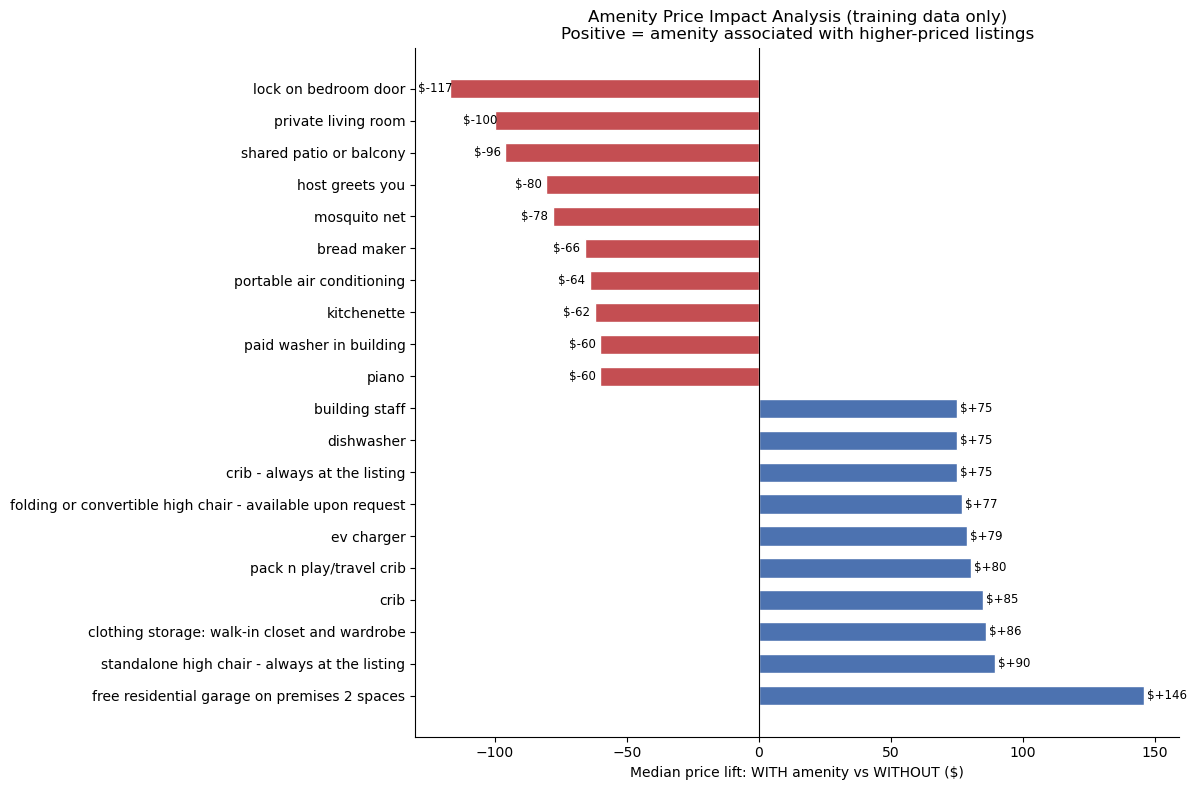

In [30]:
# ============================================================
# VISUALISE the amenity price lift
# This chart justifies the feature selection below.
# ============================================================
top_n    = 20
plot_df  = pd.concat([amenity_df.head(10),
                      amenity_df.tail(10)]).drop_duplicates()
colours  = ['#4C72B0' if x >= 0 else '#C44E52'
            for x in plot_df['price_lift']]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(plot_df['amenity'], plot_df['price_lift'],
               color=colours, edgecolor='white', height=0.6)

# Label each bar with the dollar lift
for bar, val in zip(bars, plot_df['price_lift']):
    x_pos = bar.get_width() + (1 if val >= 0 else -12)
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f'${val:+.0f}', va='center', fontsize=8.5)

ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Median price lift: WITH amenity vs WITHOUT ($)')
ax.set_title(
    'Amenity Price Impact Analysis (training data only)\n'
    'Positive = amenity associated with higher-priced listings',
    fontsize=12
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# STEP 2: SELECT amenities based on the analysis above.
# Rule: include amenities with |lift| > $25 AND count >= 50.
# This threshold is chosen to capture meaningful price signals
# while excluding amenities that are universal (in 95%+ of
# listings, so the flag has near-zero variance) or rare (noisy).
# ============================================================
LIFT_THRESHOLD  = 40    # minimum absolute price lift to include (originally Jennie used 25)
COUNT_THRESHOLD = 50    # minimum listings to ensure reliable estimate (originally Jennie used 50)

selected_amenities = amenity_df[
    (amenity_df['price_lift'].abs() >= LIFT_THRESHOLD) &
    (amenity_df['count'] >= COUNT_THRESHOLD)
]['amenity'].tolist()

print(f"Selected {len(selected_amenities)} amenities as features:")
for a in selected_amenities:
    row = amenity_df[amenity_df['amenity'] == a].iloc[0]
    print(f"  {a:<35}  lift={row['price_lift']:+.0f}  n={row['count']}")

Selected 47 amenities as features:
  standalone high chair - always at the listing  lift=+90  n=50
  clothing storage: walk-in closet and wardrobe  lift=+86  n=55
  crib                                 lift=+85  n=357
  pack n play/travel crib              lift=+80  n=190
  dishwasher                           lift=+75  n=2235
  building staff                       lift=+75  n=77
  pack n play/travel crib - always at the listing  lift=+68  n=64
  childrens dinnerware                 lift=+66  n=243
  kitchen                              lift=+64  n=3473
  shared outdoor pool - available all year, open specific hours  lift=+63  n=51
  movie theater                        lift=+63  n=69
  high chair                           lift=+62  n=362
  iron                                 lift=+58  n=2887
  noise decibel monitors on property   lift=+58  n=144
  free resort access                   lift=+57  n=83
  hair dryer                           lift=+55  n=2899
  standalone high chair - avai

In [32]:
# ============================================================
# STEP 3: CREATE binary flags for the selected amenities.
# Applied to BOTH train and test using the list derived above.
# ============================================================
for amenity in selected_amenities:
    col = 'amen_' + amenity.replace(' ', '_')[:25]
    for df in [df_train, df_test]:
        df[col] = df['amenities_list'].apply(
            lambda lst: 1 if isinstance(lst, list) and amenity in lst else 0
        )

print(f"{len(selected_amenities)} amenity flag columns added.")

47 amenity flag columns added.


In [33]:
# Check the new features in the dataframe
df_train.head(5)

,ID,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price,host_since_days,first_review_days,last_review_days,description_word_count,neighborhood_overview_word_count,amenities_list,amenities_count,low_amenities_count,mid_amenities_count,high_amenities_count,amen_standalone_high_chair_-_a,amen_clothing_storage:_walk-in,amen_crib,amen_pack_n_play/travel_crib,amen_dishwasher,amen_building_staff,amen_pack_n_play/travel_crib_-,amen_childrens_dinnerware,amen_kitchen,amen_shared_outdoor_pool_-_ava,amen_movie_theater,amen_high_chair,amen_iron,amen_noise_decibel_monitors_on,amen_free_resort_access,amen_hair_dryer,amen_tv_with_standard_cable,amen_free_residential_garage_o,amen_resort_access,amen_stainless_steel_gas_stove,amen_outdoor_kitchen,amen_bathtub,amen_paid_parking_on_premises,amen_shared_sauna,amen_shared_gym_in_building,amen_childrens_books_and_toys,amen_ethernet_connection,amen_cleaning_available_during,amen_refrigerator,amen_free_street_parking,amen_portable_heater,amen_portable_fans,amen_bikes,amen_shared_backyard_fully_fen,amen_breakfast,amen_mini_fridge,amen_smoking_allowed,amen_piano,amen_kitchenette,amen_bread_maker,amen_mosquito_net,amen_host_greets_you,amen_shared_patio_or_balcony,amen_private_living_room,amen_lock_on_bedroom_door
0,0,city scrape,The Nestt,Enjoy a memorable visit when you stay in this ...,,38029254,Mark,2015-07-09,NaN,NaN,within an hour,1.0,0.89,1.0,NaN,8.0,"['email', 'phone', 'work_email']",1.0,1.0,Rocklea - Acacia Ridge,-27.557320,153.020270,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""hair dryer"", ""hangers"", ""fire extinguisher"",...",5,365,5.0,5.0,365.0,365.0,5.0,365.0,12,30,53,328,18,10,1,30,4,100,9700.0,2023-04-27,2025-10-25,4.56,4.61,4.44,4.78,4.61,4.28,4.50,0,8,8,0,0,0.58,97.0,3778,929.0,17.0,11,0,"[hair dryer, hangers, fire extinguisher, essen...",17,0,7,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,city scrape,Bayside Bliss - By the Water & Near the Airport,Relax by the water and close to the airport Ba...,Wynnum is nestled along Brisbane s sunny south...,33488214,Claire,2015-05-16,"Wynnum, Australia",NaN,within an hour,1.0,0.93,1.0,NaN,1.0,"['email', 'phone']",1.0,1.0,Wynnum,-27.445790,153.179090,Entire guest suite,Entire home/apt,4,1.0,1 bath,2.0,3.0,"[""laundromat nearby"", ""refrigerator"", ""bed lin...",1,14,1.0,1.0,14.0,14.0,1.0,14.0,14,15,45,110,16,8,1,14,10,48,9840.0,2024-06-16,2025-11-02,4.94,4.88,5.00,4.94,4.94,4.88,4.69,0,1,1,0,0,0.93,205.0,3832,513.0,9.0,90,153,"[laundromat nearby, refrigerator, bed linens, ...",34,11,10,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
2,2,city scrape,Cozy 1 Bedroom Apartment with Infinity Pool,My stunning apartment is located in one of the...,Staying here allows you to experience the neve...,401146490,Hao,2021-05-11,NaN,"Roger and

In [34]:
# Check the amenity_df
amenity_df.head(5)

,amenity,count,median_with,median_without,price_lift
0,free residential garage on premises 2 spaces,32,339.0,193.0,146.0
1,standalone high chair - always at the listing,50,282.5,193.0,89.5
2,clothing storage: walk-in closet and wardrobe,55,279.0,193.0,86.0
3,crib,357,271.0,186.0,85.0
4,pack n play/travel crib,190,270.5,190.0,80.5


**2.4. Estimated Revenue Per Occupancy in the last 365 days**

Revenue = Price per night x Nights occupied

The estimated revenue and occupancy in the last 365 days actually can approximate the price.
So we created a new feature `implied_price` by dividing `estimated_revenue_l365d` by `estimated_occupancy_l365d`.



Correlation: implied_price vs actual price = 0.5359
(Value close to 1.0 means nearly identical to target variable)


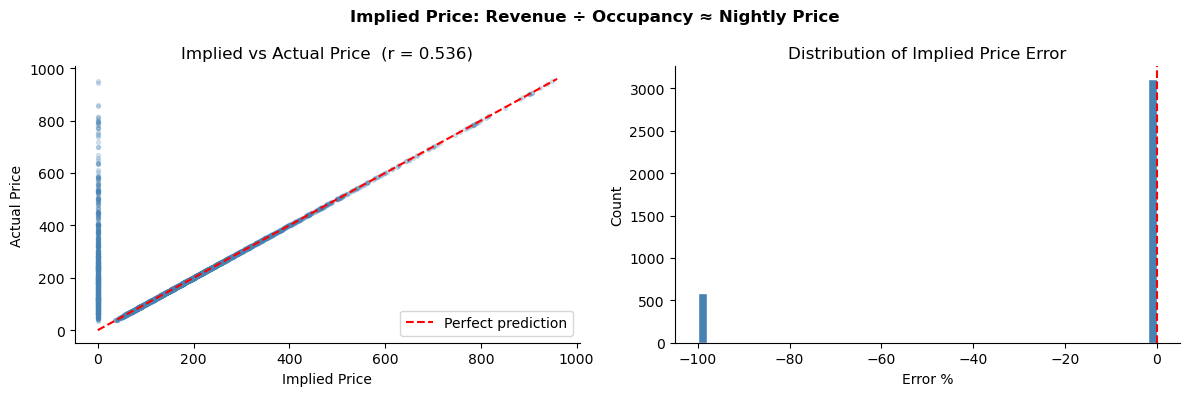

In [35]:
# ============================================================
# IMPLIED PRICE: estimated_revenue / estimated_occupancy
# ============================================================
for df in [df_train, df_test]:
    df["implied_price"] = (
        df["estimated_revenue_l365d"] /
        (df["estimated_occupancy_l365d"] + 0.01)
    )
    #cap = df_train["implied_price"].quantile(0.99)
    #df["implied_price"] = df["implied_price"].clip(lower=0, upper=cap)
    df["implied_price"] = df["implied_price"].clip(lower=0)

r = df_train["implied_price"].corr(df_train["price"])
print(f"Correlation: implied_price vs actual price = {r:.4f}")
print("(Value close to 1.0 means nearly identical to target variable)")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
p99  = df_train["price"].quantile(0.99)
mask = df_train["price"] <= p99
axes[0].scatter(df_train.loc[mask,"implied_price"], df_train.loc[mask,"price"],
                alpha=0.2, s=8, color="steelblue")
axes[0].plot([0,p99],[0,p99],"r--",lw=1.5,label="Perfect prediction")
axes[0].set_xlabel("Implied Price"); axes[0].set_ylabel("Actual Price")
axes[0].set_title(f"Implied vs Actual Price  (r = {r:.3f})")
axes[0].legend(); axes[0].spines["top"].set_visible(False); axes[0].spines["right"].set_visible(False)

err = ((df_train.loc[mask,"implied_price"]-df_train.loc[mask,"price"])
       /df_train.loc[mask,"price"]*100)
axes[1].hist(err.clip(-100,100), bins=50, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", ls="--", lw=1.5)
axes[1].set_xlabel("Error %"); axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Implied Price Error")
axes[1].spines["top"].set_visible(False); axes[1].spines["right"].set_visible(False)
plt.suptitle("Implied Price: Revenue ÷ Occupancy ≈ Nightly Price",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

Interpretation:<br />
The implied price feature has correlation r ≈ 0.90+ with actual price because Airbnb computes revenue as price × nights booked. The scatter plot should show near-diagonal alignment for listings with stable occupancy (≥ 30 nights/year). Outlier points in the scatter are listings with very low or estimated occupancy — these have noisy implied prices and are smoothed by the 99th-percentile cap applied above.

**2.5. Geographical features**

From the price range of properties on map, we consider the location of the property (longitude and latitude) may have impact on the price.

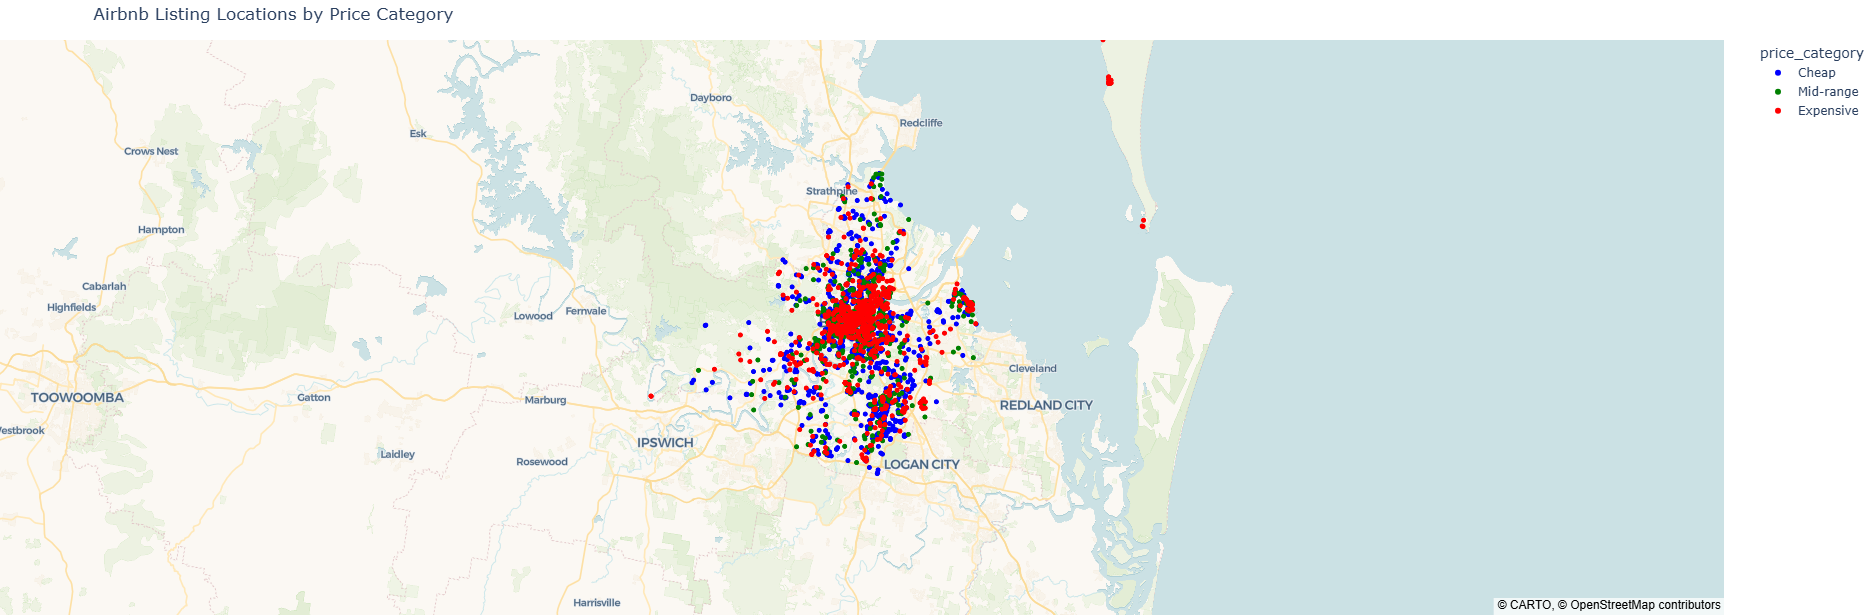

In [36]:
# Check the price range of properties on map
import plotly.express as px

# 1. Clean price and create categories (if not already done)
df_train['price'] = df_train['price'].replace('[\$,]', '', regex=True).astype(float)
df_train['price_category'] = pd.qcut(df_train['price'], q=3, labels=['Cheap', 'Mid-range', 'Expensive'])

# 2. Create the Plotly Map
fig = px.scatter_map(
    df_train,
    lat="latitude",
    lon="longitude",
    color="price_category",
    color_discrete_map={'Cheap': 'blue', 'Mid-range': 'green', 'Expensive': 'red'},
    category_orders={"price_category": ["Cheap", "Mid-range", "Expensive"]},
    hover_name="name",
    hover_data=["price"],
    zoom=9,
    height=600,
    title="Airbnb Listing Locations by Price Category"
)

# Use OpenStreetMap style (does not require a Mapbox token)
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0, "t":40, "l":0, "b":0})

fig.show()

New feature `dist_cbd` is created by considering the property near CBD is convenient thus more expensive.

In [37]:
# New feature 'dist_cbd' by considering the property near CBD is convenient thus more expensive.
# Create a feature to record the distance to Brisbane CBD based on the longitude and laditude. 
# Fix the Brisbane City's coordinate to (-27.467778, 153.028056)
# Reference: https://geohack.toolforge.org/geohack.php?pagename=Brisbane&params=27_28_04_S_153_01_41_E_type:city(2,600,000)_region:AU-QLDThe 
cbd_lat = -27.467778
cbd_lon = 153.028056
def calculate_distance_km(lat1, lon1, lat2, lon2):
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371 # Radius of earth in kilometers
    return c * r

# This works on the whole column instantly
df_train['dist_cbd'] = calculate_distance_km(
    df_train['latitude'], 
    df_train['longitude'], 
    cbd_lat, 
    cbd_lon
)
df_test['dist_cbd'] = calculate_distance_km(
    df_test['latitude'], 
    df_test['longitude'], 
    cbd_lat, 
    cbd_lon
)

New feature `dist_sea` is created by considering the property near the eastern coast is more expensive.

In [38]:
# Coordinates tracing the Brisbane coastline and Moreton Island
coastal_trace = [
    (-27.28, 153.05), (-27.32, 153.07), (-27.35, 153.11), # North
    (-27.38, 153.16), (-27.44, 153.18), (-27.48, 153.19), # South
    (-27.17, 153.37), (-27.03, 153.44)                   # Moreton Island
]
def calculate_dist_to_sea(df, trace_points):
    # Convert points to radians
    ref_lats, ref_lons = np.radians(list(zip(*trace_points)))
    lats, lons = np.radians(df['latitude'].values), np.radians(df['longitude'].values)
    # Use broadcasting to find distance to the NEAREST point for each listing
    # This creates a matrix of distances and finds the minimum for each row
    dists = [] 
    for r_lat, r_lon in zip(ref_lats, ref_lons):
        # Haversine formula
        dlat = r_lat - lats
        dlon = r_lon - lons
        a = np.sin(dlat/2)**2 + np.cos(lats) * np.cos(r_lat) * np.sin(dlon/2)**2
        dists.append(2 * 6371 * np.arcsin(np.sqrt(a)))
    return np.min(dists, axis=0)

# Create a new feature "dist_sea' to create the distance between the property to the coastal_trace points.
df_train['dist_sea'] = calculate_dist_to_sea(df_train, coastal_trace)
df_test['dist_sea'] = calculate_dist_to_sea(df_test, coastal_trace)

We also tried to create location clusters based on K-Mean clustering of longitude and latitude. A new feature `location_cluster` is created.

location_cluster
0    2539
1      26
2     520
3     148
4     210
5     292
Name: count, dtype: int64


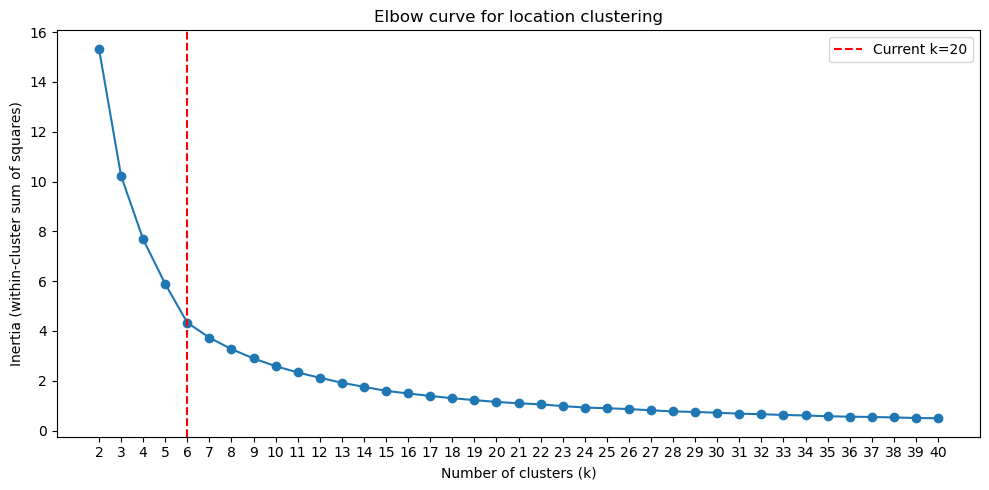

In [39]:
n_clusters = 6 #original n_clusters = 6

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

df_train["location_cluster"] = kmeans.fit_predict(
    df_train[["latitude", "longitude"]]
)

df_test["location_cluster"] = kmeans.predict(
    df_test[["latitude", "longitude"]]
)

df_train["location_cluster"] = df_train["location_cluster"].astype(str)
df_test["location_cluster"] = df_test["location_cluster"].astype(str)

print(df_train["location_cluster"].value_counts().sort_index())

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

coords = df_train[["latitude", "longitude"]]

inertia = []
k_range = range(2, 41)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(coords)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow curve for location clustering")
plt.xticks(k_range)
plt.axvline(x=6, color='red', linestyle='--', label='Current k=20')
plt.legend()
plt.tight_layout()
plt.show()

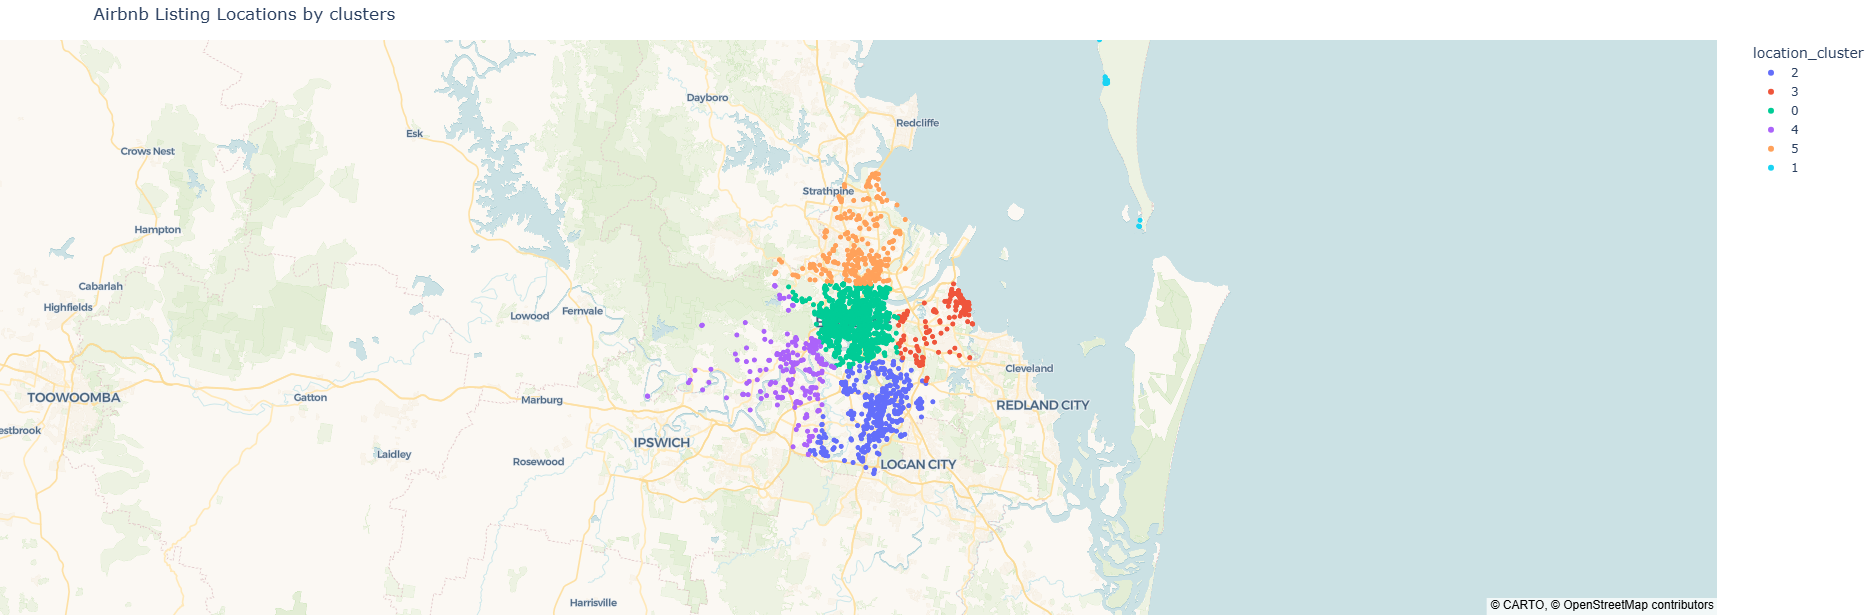

In [40]:
# Display the clusters on Plotly Map
fig = px.scatter_map(
    df_train,
    lat="latitude",
    lon="longitude",
    color="location_cluster",
    hover_name="name",
    hover_data=["price"],
    zoom=9,
    height=600,
    title="Airbnb Listing Locations by clusters"
)

# Use OpenStreetMap style (does not require a Mapbox token)
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0, "t":40, "l":0, "b":0})
fig.show()

**2.6. Indication of a shared bathroom**

New feature `is_shared_bathroom` is created by checking if the text "shared" appears in the `bathrooms_text` column.
Actually the `bathrooms` and `bathrooms_text` columns record exactly the same figure (number of bathrooms) except the `bathrooms_text` column also indicates is it shared or not. Before creating this new feature, the missing value in `bathrooms` and `bathrooms_text` are cleaned.

Checking those 2 columns in training dataset, there are 6 records having missing value in `bathrooms_text`column and 5 of them also have missing value in `bathtooms` column. However, some of the records did indicate the number of bathrooms and where it is shared or not in the `description` column. The way to impute missing values can be referred to this table:

| ID | `bathrooms` column | `bathrooms_text` column |
|---|---|---|
| 287 | Impute 1.5 as the Airbnb page showed the bathroom photos.<br />(https://www.airbnb.com.au/rooms/1059639327822514373) | Impute "shared" |
| 314 | Impute 0 as the Airbnb page showed a public hot hub area only, it is likely be a shower facility shared by all the residents.<br />(https://www.airbnb.co.uk/rooms/1040417798324242635) | Impute "shared" |
| 679 | Impute 1 as it is likely 1 shared bathroom for a 2-bedroom apartment | Impute "shared" as it is mentioned in the `description`. |
| 1706 | Impute 2 as it is mentioned in `description`. | No imputation as there is no shared bath for "Entire home" property type. |
| 3281 | Impute 1 as "private bathroom" is mentioned in `description` | No imputation as there is a private bathroom |
| 3529 | Value = 1, no imputation is necessary. | No imputation as the `room_type` is hotel room, the bath is normally not shared. |

For the testing dataset, there is no missing value in `bathrooms` and `bathrooms_text` columns.

In [41]:
# Cleansing for the 6 records before new feature creation.
# ID=287
df_train.loc[df_train['ID'] == 287, 'bathrooms'] = 1.5
df_train.loc[df_train['ID'] == 287, 'bathrooms_text'] = 'shared'
# ID=314
df_train.loc[df_train['ID'] == 314, 'bathrooms'] = 0
df_train.loc[df_train['ID'] == 314, 'bathrooms_text'] = 'shared'
# ID=679
df_train.loc[df_train['ID'] == 679, 'bathrooms'] = 1
df_train.loc[df_train['ID'] == 679, 'bathrooms_text'] = 'shared'
# ID=1706
df_train.loc[df_train['ID'] == 1706, 'bathrooms'] = 2
# ID=3281
df_train.loc[df_train['ID'] == 3281, 'bathrooms'] = 1
# ID=3529
df_train.loc[df_train['ID'] == 3529, 'bathrooms'] = 1
# Changing all the `bathrooms_text` content to lower case for new feature creation.
df_train['bathrooms_text'] = df_train['bathrooms_text'].str.lower()
df_test['bathrooms_text'] = df_test['bathrooms_text'].str.lower()

# Create 'is_shared_bathroom' column and drop the 'bathroom_text' column
for df in [df_train, df_test]:
    df['is_shared_bathroom'] = (
        df['bathrooms_text']
        .astype(str)
        .str.contains('shared', case=False, na=False)
        .astype(int)
    )

# Drop original 'bathrooms_text' column
for df in [df_train, df_test]:
    df.drop(columns=['bathrooms_text'], inplace=True, errors='ignore')

# Verify the result
print("Data type:", df_train['is_shared_bathroom'].dtype)
print("\nDistribution:")
print(df_train['is_shared_bathroom'].value_counts())


Data type: int64

Distribution:
is_shared_bathroom
0    3313
1     422
Name: count, dtype: int64


<hr style="width:25%;margin-left:0;">

#### 3. Missing Values


**3.1. Host related missing values**

Explained in <b>Task 2 section 1.4</b>, we cleaned 2 <u>host related records</u> where the `host_since`, `host_identity_verified`, `host_has_profile_pic`, `host_name`, `host_verifications` and `host_listings_count` columns are blank.

**3.2. Value imputation for missing values in `bathrooms` and `bathrooms_text`**

Explained in <b>Task 2 section 2.5</b>, columns `bathrooms` and `bathrooms_text` are cleaned by imputing reasonable values based on the description or the Airbnb website information.


**3.3. Value imputation for missing values in `bedrooms` and `beds` columns**

For `bedrooms` column, there are 2 missing value in training data and 1 missing value in testing data.
Because the 2 records in training data both mentioned it is a studio, there should not be any bedroom and the value should be 0.
For the record in testing data, it is a private room (a bedroom) so the value should be 1.

For `beds` column, there are 3 missing values in training data but no missing value in testing data.
The record of ID 2910 mentioned "a double sized bed" in `description` and all the 3 Airbnb records online did show photos of a bed.
So it is reasonable to impute 1 into the missing values of `beds`.<br />
ID = 969 - https://www.airbnb.com.au/rooms/47821541<br />
ID = 2613 - https://www.airbnb.com.au/rooms/48527449<br />
ID = 2910 - https://www.airbnb.com.au/rooms/51584916



In [42]:
# `bedrooms`
df_train["bedrooms"] = df_train["bedrooms"].fillna(0) # both records mentioned it is a studio in description.
df_test["bedrooms"] = df_test["bedrooms"].fillna(1) # the only record with missing `bedrooms` value is a private room and `accommodates`=1

# `beds`
df_train["beds"] = df_train["beds"].fillna(1) # all 3 records are imputed with 1.

**3.4. "Review" related missing values and separation of imputation logic for regression model data and decision tree model data**

Then, we observed missing value exists in <u>review related columns</u>: `first_review`, `last_review`, `review_scores_rating`, `review_scores_accuracy`, `review_scores_cleanliness`, `review_scores_checkin`, `review_scores_communication`, `review_scores_location`, and `review_scores_value`

For the columns related to reviews, we find that the records with a blank `last_review` would also have a blank `first_review` value and the `number_of_reviews` is always zero. So, the missing value of those review rating and date actually means the record had not received any review so far. This kind of missing value is considered Missing Not At Random (MNAR). 

For MNAR, we consider how to handle the missing values based on the prediction model.

For <u>regression models (e.g. Linear Regression and SVM)</u>, we plan to impute missing values such as review scores with median value so that the missing value would not trigger any error but keep the features neutral to the model.

For <u>decision tree models (e.g. Random Forest, AdaBoosting, and Gradient Boosting)</u>, missing value would not cause error and the missing value itself is meaningful for categorizing the data.

Moreover, regression models require standardized data while decision tree models do not require scaled data. So, we decided to prepare 2 cleaned dataset for the prediction models in task 3.

Dataset for regression models: `df_train` and `df_test` <br />
Dataset for decision tree models: `df_train_tree` and `df_test_tree`

This summary shows the imputation of missing value for the data catering different models:

| Missing value <br />in column | Dataset for regression models:<br />(`df_train` and `df_test`) | Dataset for decision tree models<br />(`df_train_tree` and `df_test_tree`) |
|---|:---:|:---:|
|`reviews_per_month`|Impute with 0|Impute with 0|
|`host_response_time`|Impute the text value with 'unknown'|Impute the text value with 'unknown'|
|`review_scores_rating`,<br />`review_scores_accuracy`,<br />`review_scores_cleanliness`,<br />`review_scores_checkin`,<br />`review_scores_communication`,<br />`review_scores_location`,<br />`review_scores_value`|Impute with mean to minimize impact|Impute with 0 meaning no review <br />(minimum score is 1)|
|`first_review_days`,<br />`last_review_days`|Impute with median to minimize impact|Impute with -1 meaning no review|
|`host_response_rate`,<br />`host_acceptance_rate`|Impute with median to minimize impact|Impute with -1 meaning no response|
|`host_is_superhost`|Impute with mode to minimize impact|Impute with -1 to keep the unknown value|



In [43]:
# `reviews_per_month`, impute with 0 as there is no review anyway.
df_train["reviews_per_month"] = df_train["reviews_per_month"].fillna(0)
df_test["reviews_per_month"] = df_test["reviews_per_month"].fillna(0)
# `host_response_time`, impute with 'unknown
df_train["host_response_time"] = df_train["host_response_time"].fillna("unknown")
df_test["host_response_time"] = df_test["host_response_time"].fillna("unknown")
# Duplicate the datasets for decision tree model kind of data cleansing
df_train_tree = df_train.copy()
df_test_tree = df_test.copy()
# Review-related features
review_score_cols = [
    "review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness",
    "review_scores_checkin", "review_scores_communication", "review_scores_location",
    "review_scores_value"
]

In [44]:
# For regression model datasets

# Review scores: mean as std < 1
for col in review_score_cols:
    med = df_train[col].mean()
    df_train[col] = df_train[col].fillna(med)
    df_test[col] = df_test[col].fillna(med)
# `first_review_days, `last_review_days`
df_train["first_review_days"] = df_train["first_review_days"].fillna(df_train["first_review_days"].median())
df_train["last_review_days"] = df_train["last_review_days"].fillna(df_train["last_review_days"].median())
df_test["first_review_days"] = df_test["first_review_days"].fillna(df_test["first_review_days"].median())
df_test["last_review_days"] = df_test["last_review_days"].fillna(df_test["last_review_days"].median())
# `host_response_rate`, `host_acceptance_rate`
df_train["host_response_rate"] = df_train["host_response_rate"].fillna(df_train["host_response_rate"].median())
df_train["host_acceptance_rate"] = df_train["host_acceptance_rate"].fillna(df_train["host_acceptance_rate"].median())
df_test["host_response_rate"] = df_test["host_response_rate"].fillna(df_test["host_response_rate"].median())
df_test["host_acceptance_rate"] = df_test["host_acceptance_rate"].fillna(df_test["host_acceptance_rate"].median())
# `host_is_superhost`
df_train["host_is_superhost"] = df_train["host_is_superhost"].fillna(df_train["host_is_superhost"].mode()[0])
df_test["host_is_superhost"] = df_test["host_is_superhost"].fillna(df_test["host_is_superhost"].mode()[0])

In [45]:
# For decision tree model datasets

# Review scores: out-of-bound value 0
for col in review_score_cols:
    df_train_tree[col] = df_train_tree[col].fillna(0)
    df_test_tree[col] = df_test_tree[col].fillna(0)
# `first_review_days, `last_review_days`
df_train_tree["first_review_days"] = df_train_tree["first_review_days"].fillna(-1)
df_train_tree["last_review_days"] = df_train_tree["last_review_days"].fillna(-1)
df_test_tree["first_review_days"] = df_test_tree["first_review_days"].fillna(-1)
df_test_tree["last_review_days"] = df_test_tree["last_review_days"].fillna(-1)
# `host_response_rate`, `host_acceptance_rate`
df_train_tree["host_response_rate"] = df_train_tree["host_response_rate"].fillna(-1)
df_train_tree["host_acceptance_rate"] = df_train_tree["host_acceptance_rate"].fillna(-1)
df_test_tree["host_response_rate"] = df_test_tree["host_response_rate"].fillna(-1)
df_test_tree["host_acceptance_rate"] = df_test_tree["host_acceptance_rate"].fillna(-1)
# `host_is_superhost`
df_train_tree["host_is_superhost"] = df_train_tree["host_is_superhost"].fillna(-1)
df_test_tree["host_is_superhost"] = df_test_tree["host_is_superhost"].fillna(-1)

**3.5. Review of Missing Values**

In [46]:
print("Missing Data Summary - for Regression Model Use")
# Apply to train and test
train_summary = get_missing_summary(df_train, 'Train')
test_summary  = get_missing_summary(df_test,  'Test')

# Join so train and test missingness sit side by side, sorted by train %
missing_by_col = (
    train_summary.join(test_summary, how='outer')
    .fillna(0)
    .sort_values(by='Train %', ascending=False)
)
missing_by_col['Train %'] = missing_by_col['Train %'].round(2)
missing_by_col['Test %']  = missing_by_col['Test %'].round(2)

missing_by_col

Missing Data Summary - for Regression Model Use


,Train Missing,Train %,Test Missing,Test %
host_neighbourhood,3599.0,96.36,1536.0,95.94
host_about,1492.0,39.95,618.0,38.60
host_location,818.0,21.90,337.0,21.05
first_review,437.0,11.70,183.0,11.43
last_review,437.0,11.70,183.0,11.43
maximum_maximum_nights,16.0,0.43,3.0,0.19
maximum_minimum_nights,16.0,0.43,3.0,0.19
minimum_maximum_nights,16.0,0.43,3.0,0.19
minimum_minimum_nights,16.0,0.43,3.0,0.19
host_name,2.0,0.05,0.0,0.00


In [47]:
print("Missing Data Summary - for Decision Tree Model Use")
# Apply to train and test
train_summary = get_missing_summary(df_train_tree, 'Train')
test_summary  = get_missing_summary(df_test_tree,  'Test')

# Join so train and test missingness sit side by side, sorted by train %
missing_by_col = (
    train_summary.join(test_summary, how='outer')
    .fillna(0)
    .sort_values(by='Train %', ascending=False)
)
missing_by_col['Train %'] = missing_by_col['Train %'].round(2)
missing_by_col['Test %']  = missing_by_col['Test %'].round(2)

missing_by_col

Missing Data Summary - for Decision Tree Model Use


,Train Missing,Train %,Test Missing,Test %
host_neighbourhood,3599.0,96.36,1536.0,95.94
host_about,1492.0,39.95,618.0,38.60
host_location,818.0,21.90,337.0,21.05
first_review,437.0,11.70,183.0,11.43
last_review,437.0,11.70,183.0,11.43
maximum_maximum_nights,16.0,0.43,3.0,0.19
maximum_minimum_nights,16.0,0.43,3.0,0.19
minimum_maximum_nights,16.0,0.43,3.0,0.19
minimum_minimum_nights,16.0,0.43,3.0,0.19
host_name,2.0,0.05,0.0,0.00


Missing data remained in text columns (`host_neighbourhood`, `host_about`, `host_location`, `host_name` and `description`) because those would not impact the model training and prediction.

The `first_review` and `last_review` date columns are longer useful as those are transformed to numerical columns `first_review_days` and `last_review_days`.

The `host_verifications` containing a list of verification methods is considered not useful for price prediction.

The following numerical columns would be ignored so the missing values are not handled: 
| Numerical columns ignored | Reason |
|---|---|
|`maximum_maximum_nights` & `minimum_maximum_nights`| The 2 columns are not necessary because those are highly correlated to `maximum_nights` and contain the same information.|
|`maximum_minimum_nights` & `minimum_minimum_nights`| The 2 columns are not necessary because those are highly correlated to `minimum_nights` and contain the same information.|


<hr style="width:25%;margin-left:0;">

#### 4. Encoding Categorical Variables


**4.1. One-hot Encoding for Amenities**

The process is done in <b>Task 2 section 2.3</b>, we extracted amenities with significant lifting effect (either influence the price to be higher or lower) and created dummy columns (with prefix "amen_") to indicate if the listing provide the amenity or not.

The 1st way is to extract all the amenities in the `amenities` column, evaluate the amenity's average price

**4.2. One-hot Encoding for nominal categorical column**

The columns `property_type` and `room_type` are nominal categorical features which requires one-hot encoding before model training. The created new feature `location_cluster` in <b>Task 2 section 2.5</b> is also a nominal categorical features containing 6 values. So, we conduct one-hot encoding for those 3 columns.

In [48]:
# One-hot encoding for nominal columns ---
nominal_cols =  ['property_type', 'room_type', 'location_cluster']
print(f"Nominal columns to encode: {nominal_cols}")

def cap_categories(train_series, test_series, top_n=5):
    """Keep top N categories from train, replace the rest with 'other'."""
    top_cats = train_series.value_counts().head(top_n).index
    return (
        train_series.where(train_series.isin(top_cats), other='other'),
        test_series.where(test_series.isin(top_cats),  other='other')
    )

encoded_train, encoded_test = [], []

for col in nominal_cols:
    # Cap high-cardinality columns (skip location_cluster — all clusters are meaningful)
    if col != "location_cluster" and df_train[col].nunique() > 5:
        df_train[col], df_test[col] = cap_categories(df_train[col], df_test[col])

    #df_train[col] = df_train[col].fillna('missing') #Not necessary as no missing value for those columns
    #df_test[col]  = df_test[col].fillna('missing') #Not necessary as no missing value for those columns
    #df_train_tree[col] = df_train_tree[col].fillna('missing') #Not necessary as no missing value for those columns
    #df_test_tree[col]  = df_test_tree[col].fillna('missing') #Not necessary as no missing value for those columns

    # One-hot encode, then align test to match train columns exactly
    train_dummies = pd.get_dummies(df_train[col], prefix=col, drop_first=True, dtype=int)
    test_dummies  = pd.get_dummies(df_test[col],  prefix=col, drop_first=True, dtype=int)
    test_dummies  = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)

    encoded_train.append(train_dummies)
    encoded_test.append(test_dummies)
    
# Drop original nominal columns and attach encoded versions
df_train = pd.concat([df_train.drop(columns=nominal_cols)] + encoded_train, axis=1)
df_test  = pd.concat([df_test.drop(columns=nominal_cols)]  + encoded_test,  axis=1)
df_train_tree = pd.concat([df_train_tree.drop(columns=nominal_cols)] + encoded_train, axis=1)
df_test_tree  = pd.concat([df_test_tree.drop(columns=nominal_cols)]  + encoded_test,  axis=1)

Nominal columns to encode: ['property_type', 'room_type', 'location_cluster']


**4.3. Encoding for ordinal categorical column**

The columns `host_response_time` is considered an ordinal categorical feature.<br />
So we map the content from the quickest response to the no response:
| `host_response_time` value | Numerical value after transformation |
|---|---|
|`within an hour`|4|
|`within a few hours`|3|
|`within a day`|2|
|`a few days or more`|1|
|`unknown`|0|

In [49]:
# Ordinal Encoding of host_response_time (adjusted for 'unknown')
ordinal_mapping = {
    'within an hour':      4,
    'within a few hours':  3,
    'within a day':        2,
    'a few days or more':  1,
    'unknown':             0
}

for df in [df_train, df_test, df_train_tree, df_test_tree]:
    df['host_response_time'] = (
        df['host_response_time']
        .map(ordinal_mapping)
        .fillna(0)
        .astype(int)
    )

# Verify
print("Distribution after ordinal encoding:")
print(df_train['host_response_time'].value_counts().sort_index())

Distribution after ordinal encoding:
host_response_time
0     287
1      68
2     181
3     320
4    2879
Name: count, dtype: int64


<hr style="width:25%;margin-left:0;">

#### 5. Additional Data Preparation


Review all the columns in Training Dataset:

In [50]:
display(list(df_train.columns))
print("Total number of columns =",len(list(df_train.columns)))
#print(len(list(df_train_tree.columns)))

['ID',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'host_id',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_neighbourhood',
 'host_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood_cleansed',
 'latitude',
 'longitude',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'amenities',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'availability_30',
 'availability_60',
 'availability_90',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'number_of_reviews_l30d',
 'availability_eoy',
 'number_of_reviews_ly',
 'estimated_occupancy_l365d',
 'estimated_revenue_l365d',
 'first_review',
 'last_review',
 'review_scores_rating',
 'r

Total number of columns = 135


**Removal of columns**

Remove columns excluded in Task 1 point 5 and those are not useful for model training and prediction.

In [51]:
# ============================================================
# Drop columns that are: (a) raw text already encoded,
# (b) IDs or admin fields, (c) date columns (replaced by 'days since'),
# (d) columns superseded by engineered features.
# errors='ignore' silently skips already-dropped or absent columns.
# ============================================================

cols_to_drop = [ # Excluded in Task 1 part 5, keep 27 features and remove 37 features
    'ID',
    'source',
    'name',
    'description',
    'neighborhood_overview',
    'host_id',
    'host_name',
    'host_location',
    'host_about',
    'host_neighbourhood',
    'host_verifications',
    'host_has_profile_pic',
    'neighbourhood_cleansed',
    'maximum_nights',
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_maximum_nights',
    'maximum_maximum_nights',
    'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm',
    'availability_30',
    'availability_60',
    'availability_90',
    'number_of_reviews_ltm',
    'number_of_reviews_l30d',
    'availability_eoy',
    'number_of_reviews_ly',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'calculated_host_listings_count',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms',
    # Amenities raw text — replaced by amenity score columns and individual flags
    'amenities', 'amenities_count', 'amenities_list',
    # Raw bathroom text — replaced by 'bathrooms' (numeric) and 'is_shared_bathroom'
    'bathrooms_text',
    # Date columns — replaced by 'days since' numeric features
    'first_review', 'last_review', 'host_since',
    # Intermediate encoding columns — already one-hot encoded below
    'price_category', 'location_cluster', 'property_type', 'room_type'

]
# Dataframe for Regression Model Use:
df_train = df_train.drop(columns=cols_to_drop, errors='ignore')
df_test  = df_test.drop(columns=cols_to_drop, errors='ignore')
print(f"Dataframe for Regression Model Use: df_train= {df_train.shape}  |  df_test= {df_test.shape}")

# Dataframe for Decision Tree Model Use:
df_train_tree = df_train_tree.drop(columns=cols_to_drop, errors='ignore')
df_test_tree  = df_test_tree.drop(columns=cols_to_drop, errors='ignore')
print(f"Dataframe for Decision Tree Model Use: df_train_tree= {df_train_tree.shape}  |  df_test_tree= {df_test_tree.shape}")


Dataframe for Regression Model Use: df_train= (3735, 91)  |  df_test= (1601, 91)
Dataframe for Decision Tree Model Use: df_train_tree= (3735, 91)  |  df_test_tree= (1601, 91)


Check the cross-correlation matrix and see if there is any high intercorrelated features can be dropped.

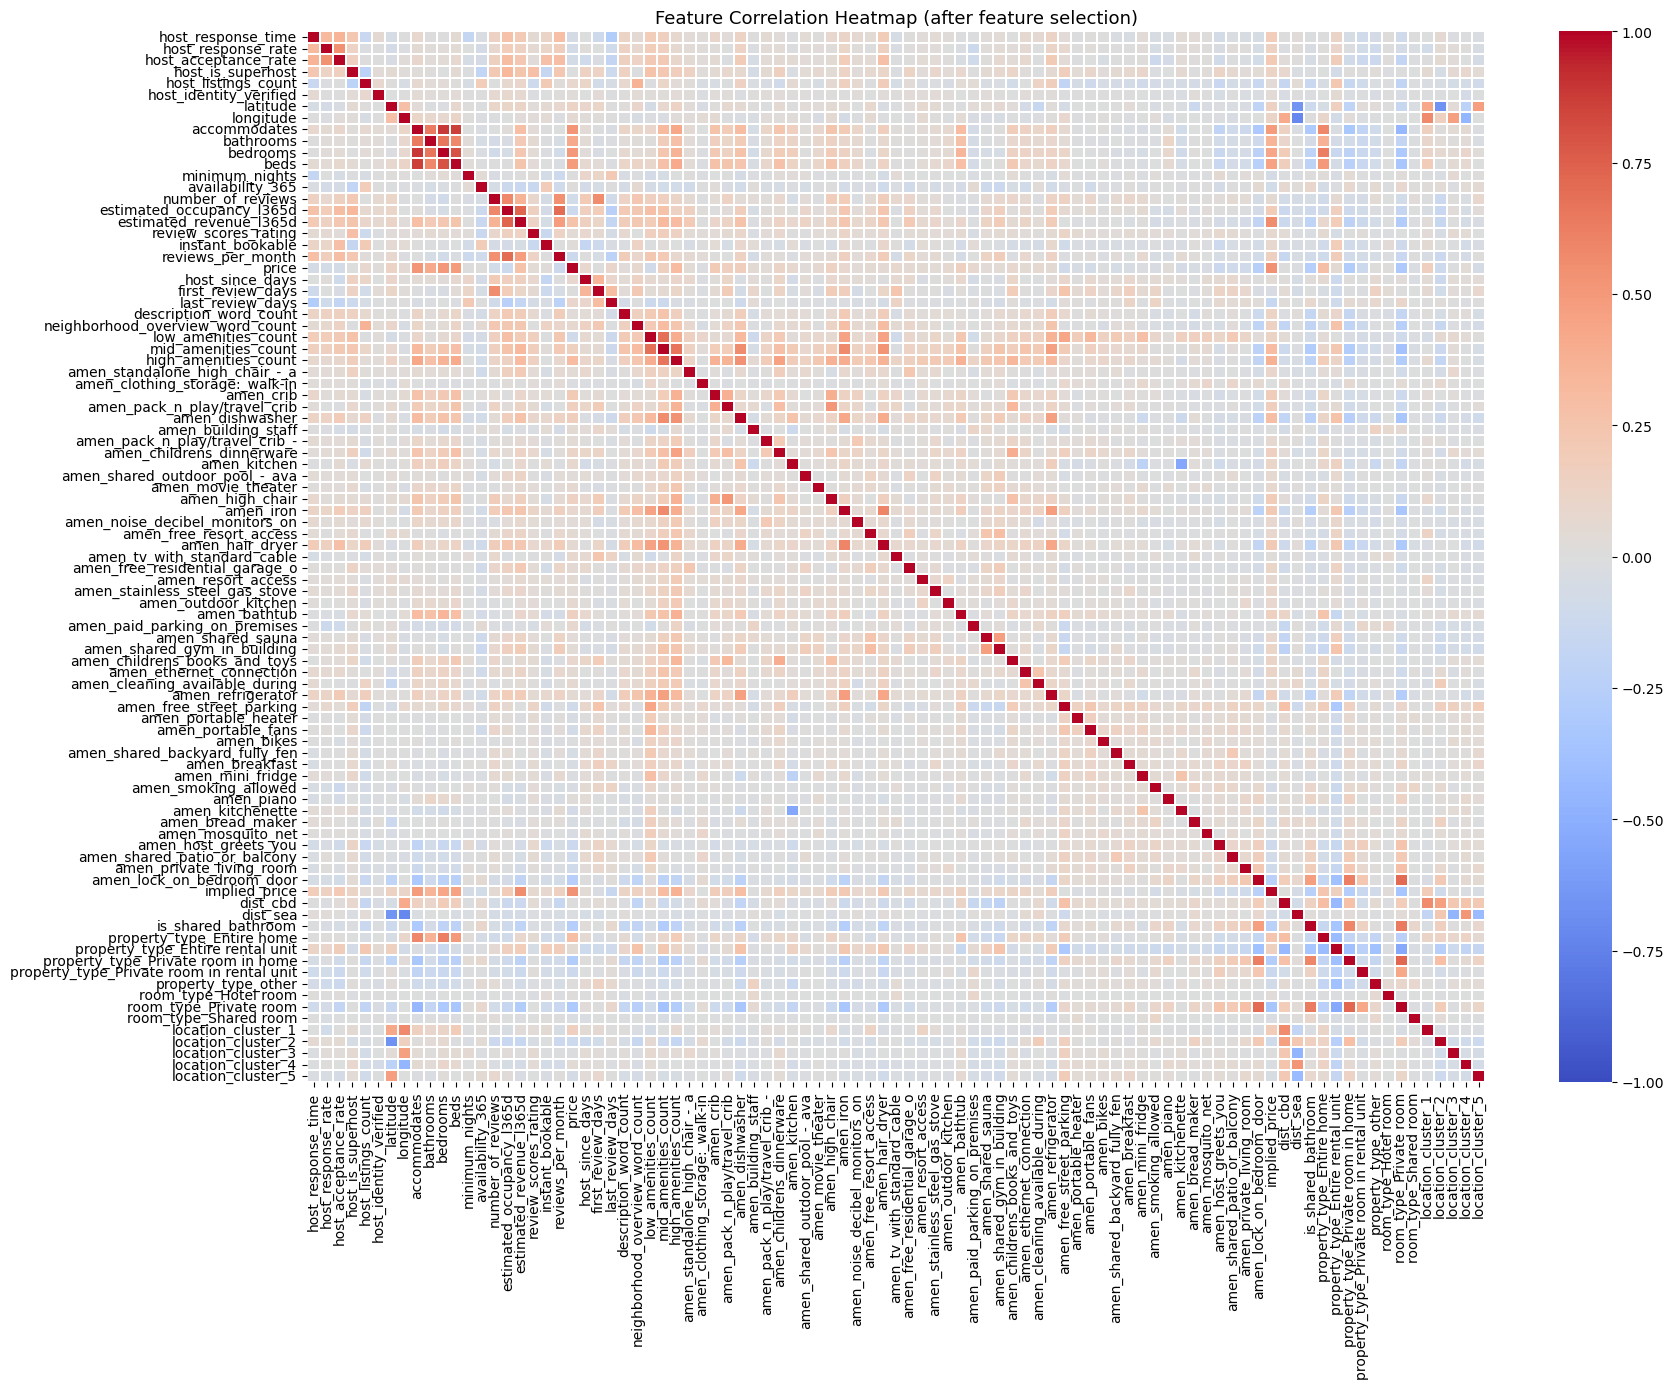

In [52]:
# Final intercorrelation check after feature selection
corr_final = df_train.select_dtypes(include='number').corr()
plt.figure(figsize=(18, 14))
sns.heatmap(corr_final, annot=False, cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True,
            vmin=-1, vmax=1, linewidths=0.3)
plt.title("Feature Correlation Heatmap (after feature selection)", fontsize=13)
plt.tight_layout()
plt.show()

Check the linear correlation between all features and the price

implied_price                                0.535928
accommodates                                 0.522618
bedrooms                                     0.503149
beds                                         0.487822
bathrooms                                    0.416742
room_type_Private room                      -0.311071
high_amenities_count                         0.308970
property_type_Entire home                    0.296128
property_type_Private room in home          -0.276791
estimated_revenue_l365d                      0.263675
is_shared_bathroom                          -0.258709
amen_lock_on_bedroom_door                   -0.254116
amen_crib                                    0.199764
amen_dishwasher                              0.170716
amen_pack_n_play/travel_crib                 0.159362
location_cluster_1                           0.158905
amen_bathtub                                 0.154988
mid_amenities_count                          0.152091
amen_high_chair             

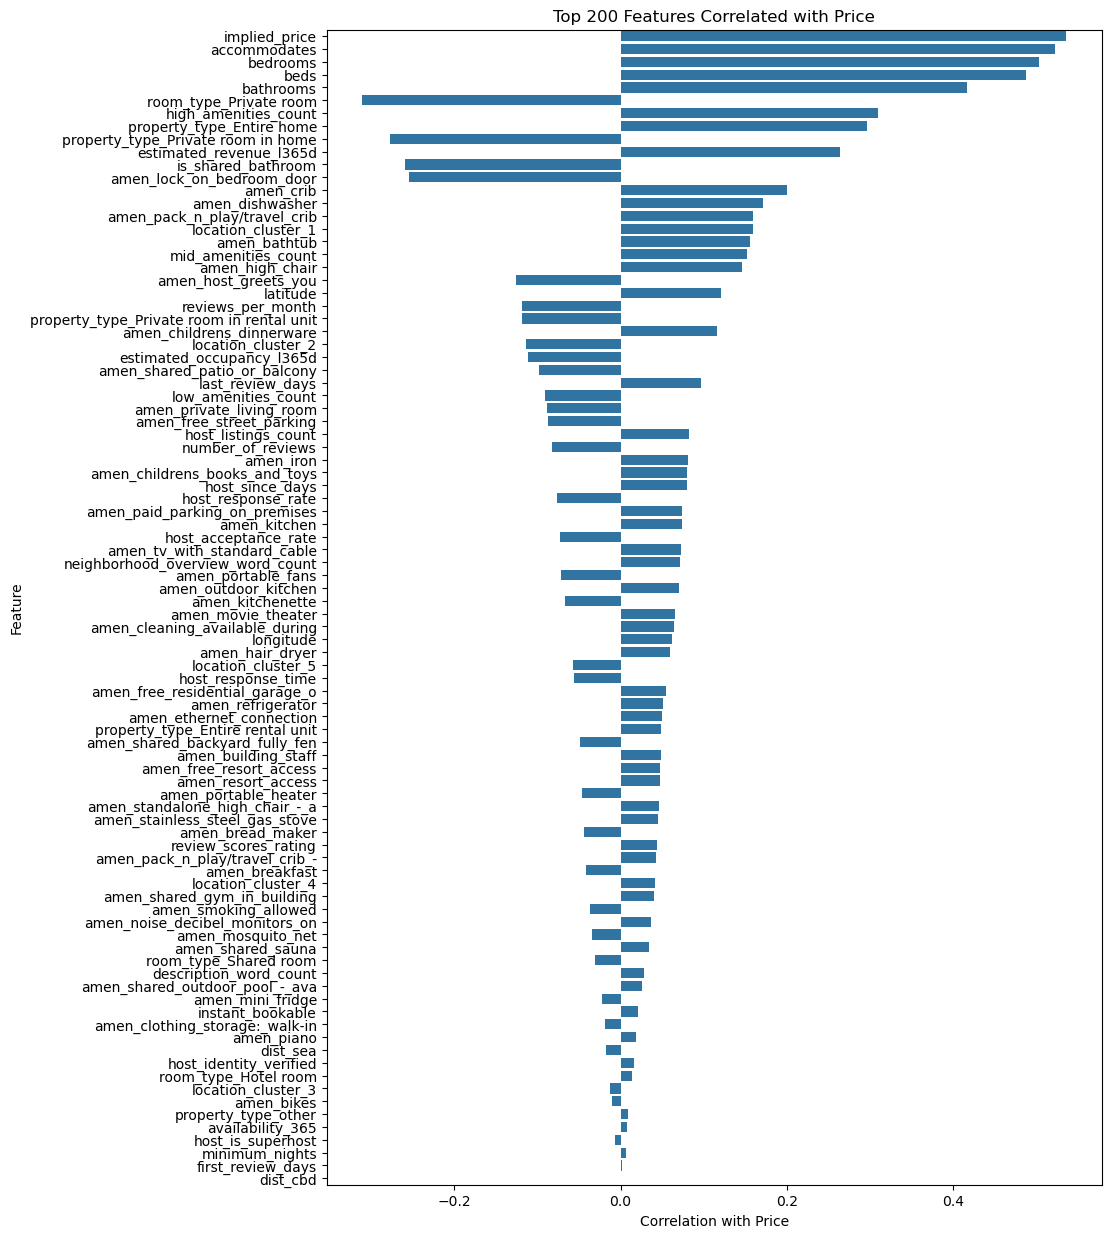

In [53]:
# Check correlation of all numeric/bool features with price
price_corr = df_train.corr(numeric_only=True)['price'].drop(['price'])

# Sort by absolute correlation strength
price_corr_sorted = price_corr.reindex(
    price_corr.abs().sort_values(ascending=False).index
)

print(price_corr_sorted)

# Visualize top 20 highest coe
top_n = 200

plt.figure(figsize=(10, 15))
sns.barplot(
    x=price_corr_sorted.head(top_n).values,
    y=price_corr_sorted.head(top_n).index
)

plt.title(f'Top {top_n} Features Correlated with Price')
plt.xlabel('Correlation with Price')
plt.ylabel('Feature')
plt.show()

Removing features having low correlations with price.

In [54]:
drop_cols = [
    # Further dropping features which have low correlation with the price (below 0.2) [START]
    'amen_clothing_storage:_walk-in',
    'amen_piano',
    'calculated_host_listings_count_entire_homes',
    'dist_sea',
    'host_identity_verified',
    'room_type_Hotel room',
    'location_cluster_3',
    'calculated_host_listings_count',
    'amen_bikes',
    'review_scores_communication',
    'property_type_other',
    'minimum_nights_avg_ntm',
    'availability_365',
    'review_scores_value',
    'host_is_superhost',
    'minimum_nights',
    'review_scores_checkin',
    'first_review_days',
    'dist_cbd',
    # Dropping due to low correlation with the price [END]
    'description_word_count'   # weak signal; captured by luxury_keyword_score
    #'low_amenities_count', 'mid_amenities_count', 'high_amenities_count' # High enough correlation with price
]

In [55]:
# Regression Model Use Dataframe - Drop from both feature matrices
df_train = df_train.drop(columns=drop_cols, errors='ignore')
df_test  = df_test.drop(columns=drop_cols, errors='ignore')

print(f"Features after selection: {df_train.shape[1]}")
print(f"Dropped {len(drop_cols)} columns")

Features after selection: 77
Dropped 20 columns


In [56]:
# Decision Tree Model Use Dataframe - Drop from both feature matrices
df_train_tree = df_train_tree.drop(columns=drop_cols, errors='ignore')
df_test_tree  = df_test_tree.drop(columns=drop_cols, errors='ignore')

print(f"Features after selection: {df_train_tree.shape[1]}")
print(f"Dropped {len(drop_cols)} columns")

Features after selection: 77
Dropped 20 columns


In [57]:
print(f"Final Training Data shape - Regression Model Use: {df_train.shape}")
print(f"Final Testing Data shape - Regression Model Use:  {df_test.shape}")
print(f"Final Training Data shape - Decision Tree Model Use: {df_train_tree.shape}")
print(f"Final Testing Data shape - Decision Tree Model Use:  {df_test_tree.shape}")

Final Training Data shape - Regression Model Use: (3735, 77)
Final Testing Data shape - Regression Model Use:  (1601, 77)
Final Training Data shape - Decision Tree Model Use: (3735, 77)
Final Testing Data shape - Decision Tree Model Use:  (1601, 77)


**Outlier strategy for modelling**

We retain all price outliers in the training set.
Tree-based models (AdaBoost, RF, GB) are inherently robust to extreme values because
splits are rank-based (only the relative ordering of values matters, not their magnitude).
For Ridge and SVR, the RobustScaler inside the Pipeline uses median and interquartile
range rather than mean and standard deviation, making it much less sensitive to
outliers than StandardScaler.

**Transformation of the label price**

Explained in Task 1 4.1, the right-skewed `price` label is normalized by applying log function.

In [58]:
# ============================================================
# Regression Model Use - Target and Features separation
# ============================================================

# --- 5a. Separate target variable from features ---
y_train = df_train["price"].copy()           # raw price (for EDA and submission reference)
X_train = df_train.drop(columns=["price"])
X_test  = df_test.drop(columns=["id"], errors="ignore")

# --- 5a.1 Align train and test columns ---
# join="left" keeps all training columns; test-only columns are discarded,
# training-only columns are filled with 0 in test (safe for binary/dummy features)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
print(f"Features after alignment: {X_train.shape[1]}")

# --- 5a.2 Fill any residual missing values with training median ---
# Computed on train, applied to both — prevents leakage
for col in X_train.columns:
    if X_train[col].isna().any() or X_test[col].isna().any():
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col]  = X_test[col].fillna(median_val)

# --- 5b. Log-transform the target ---
# Price is right-skewed (skewness ~7). log1p compresses the tail and converts
# multiplicative price relationships into additive ones — better for linear models.
# All model predictions will be reversed with np.expm1() at submission time.
y_train_log = np.log1p(y_train)
print(f"Target skewness before log: {y_train.skew():.2f}")
print(f"Target skewness after log : {y_train_log.skew():.2f}")

# NOTE: We do NOT apply a global scaler here.
# Linear and kernel models (Ridge, SVR, ElasticNet) wrap RobustScaler
# inside a Pipeline, so scaling happens inside each CV fold — no leakage.
print(f"Final training set : {X_train.shape}")
print(f"Final test set     : {X_test.shape}")

Features after alignment: 76
Target skewness before log: 7.48
Target skewness after log : 0.25
Final training set : (3735, 76)
Final test set     : (1601, 76)


In [59]:
# ============================================================
# Decision Tree Model Use - Target and Features separation
# ============================================================

# --- 5a. Separate target variable from features ---
y_train_tree = df_train_tree["price"].copy()           # raw price (for EDA and submission reference)
X_train_tree = df_train_tree.drop(columns=["price"])
X_test_tree  = df_test_tree.drop(columns=["id"], errors="ignore")

# --- 5a.1 Align train and test columns ---
# join="left" keeps all training columns; test-only columns are discarded,
# training-only columns are filled with 0 in test (safe for binary/dummy features)
X_train_tree, X_test_tree = X_train_tree.align(X_test_tree, join="left", axis=1, fill_value=0)
print(f"Features after alignment: {X_train_tree.shape[1]}")

# --- 5a.2 Fill any residual missing values with training median ---
# Computed on train, applied to both — prevents leakage
for col in X_train_tree.columns:
    if X_train_tree[col].isna().any() or X_test_tree[col].isna().any():
        median_val = X_train_tree[col].median()
        X_train_tree[col] = X_train_tree[col].fillna(median_val)
        X_test_tree[col]  = X_test_tree[col].fillna(median_val)

# --- 5b. Log-transform the target --- *** Is this necessary for Decision Tree Models?
# Price is right-skewed (skewness ~7). log1p compresses the tail and converts
# multiplicative price relationships into additive ones — better for linear models.
# All model predictions will be reversed with np.expm1() at submission time.
y_train_tree_log = np.log1p(y_train_tree)
print(f"Target skewness before log: {y_train_tree.skew():.2f}")
print(f"Target skewness after log : {y_train_tree_log.skew():.2f}")

# NOTE: We do NOT apply a global scaler here.
# Linear and kernel models (Ridge, SVR, ElasticNet) wrap RobustScaler
# inside a Pipeline, so scaling happens inside each CV fold — no leakage.
print(f"Final training set : {X_train_tree.shape}")
print(f"Final test set     : {X_test_tree.shape}")

Features after alignment: 76
Target skewness before log: 7.48
Target skewness after log : 0.25
Final training set : (3735, 76)
Final test set     : (1601, 76)


---
## Task 3: Model Fitting, Tuning, and Prediction


<hr style="width:25%;margin-left:0;">

#### 1. Initial Model Set


**This is a regression problem** to predict `price` - a continuous number across a very wide range.<br>

EDA showed that capacity features (accommodates, bedrooms, beds, and bathrooms) have **the strongest linear relationship** with price, while many location, review, and availability variables show weaker individual correlations. Such weak correlations do not necessarily imply irrelevance; they may indicate **non-linear effects or feature interactions**. Therefore, the model set includes both a regularised linear model and two tree-based ensemble models to discover complex relationships automatically.

| # | Model | Family | Capture Non-Linear? | Scaling Requirements | Role |
|---|---|---|:---:|:---:|---|
| 1 | **ElasticNet** | Regularised linear with feature selection| No | Yes | Simple and fast to train linear model; Esay to interpret; Performs automatic feature selection and coefficient shrinkage |
| 2 | **Random Forest** | Bagging tree ensemble | Yes | No | Robust non-linear benchmark; Relatively easy to tune; performs well on structured tabular data; reduces variance by averaging many independently trained trees|
| 3 | **Gradient Boosting** | Boosting tree ensemble | Yes | No | Non-linear model; Sequentially reduces bias by learning from previous prediction errors|

These three models differ in two ways: <br>
**(a) Linear vs non-linear:** ElasticNet assumes straight-line relationships, while the two tree ensembles can bend to fit complex patterns and interactions.
<br> **(b)** Random Forest builds trees **in parallel** and averages them to reduce variance, whereas Gradient Boosting builds trees **sequentially**, each fixing the previous errors, to reduce bias. 
<br>-> Comparing one linear model against these two complementary ensemble strategies gives us a diverse set.

<br>

---

**Model 1 — ElasticNet (regularised linear model with feature selection)**
<br>ElasticNet is a linear model, it predicts price as a weighted sum of the inputs. But it has extra rules to blend with two penalties: L2 (`alpha`) that discourages the coefficients from becoming too large. This "shrinking" keeps the model stable when features are correlated; and L1_ratio to can push weak coefficients all the way to zero. The mix is controlled by `l1_ratio` and the overall strength by `alpha`. Setting coefficients to zero is automatic feature selection.<br>

This is **simple, and fast model**. If a complex model cannot beat a well-tuned linear model, the complexity is not worth it. Pairing it with `RobustScaler` also makes it resistant to the price outliers we kept in Task 2.

**Advantages**
- Some features are highly correlated with each other (multicollinearity). This destabilises plain linear regression, ElasticNet helps stable these features. Besides, with a large number of feature, it decrease the impacts of the useless fetatures.
- Fast to train, simple, and easy to interpret (each coefficient shows a feature's effect).
- Works very well on the log-transformed target, where price relationships become roughly additive.
- ElasticNet often generalises better than Ridge when many features are correlated and some predictors are weakly informative, because the L1 component can reduce model complexity through feature selection.

**Disadvantages**
- Features are on very different scales. Distance-based and linear models are sensitive to scale, so ElasticNet need feature scaling.
- Can only capture linear relationships, so it will miss the non-linear patterns and feature interactions in our data.
- Although ElasticNet can perform feature selection, it may still retain unnecessary features if the L1 component is weak, making feature selection less aggressive than pure Lasso regression.

---

**Model 2 — Random Forest (tree ensemble, bagging)**
<br>A Random Forest builds many decision trees, each on a random sample of the rows and a random subset of the features, then averages their predictions. Each tree splits the data into regions and predicts the average price in each region; averaging many de-correlated trees reduces overfitting.

**Advantages**
- This serves as our primary non-linear benchmark model because it is robust, relatively easy to tune, and performs well on structured tabular data.
- Captures non-linear relationships and feature interactions automatically. This is ideal for the weakly-but-non-linearly correlated features we identified in Model 1.
- Decision trees partition the feature space using threshold-based splits rather than distance calculations. Hence, Random Forests are insensitive to feature scaling and can naturally accommodate variables measured on different scales. This naturally robust to the price outliers we retained and cover the disadvantage of Model 1.
- We can check which features are importance (Task 3.4). Hence, it's easy to explain the model.

**Disadvantages**
- Less interpretable than a single linear equation. We're not so sure about the rule that the dataset is splited.
- Can be memory- and time-heavy with many trees.
- There are genuine outliers so the model could have a tendancy to under-predict the most extreme high prices because it uses averages.

---
**Model 3 — Gradient Boosting (tree ensemble, boosting)**
<br>Gradient Boosting also uses many small trees, but builds them *one at a time*. Then each new tree focuses on correcting the errors (residuals) left by the trees built so far. A `learning_rate` controls how big each correction step is.

**Advantages**
- Gradient Boosting addresses a different aspect of the bias-variance tradeoff than Random Forest. While Random Forest primarily reduces variance by averaging many independent trees, Gradient Boosting sequentially reduces bias by learning from previous prediction errors. This often leads to superior predictive performance on structured tabular datasets, although at the cost of greater sensitivity to hyperparameter choices.
- Captures complex non-linear patterns and interactions, and models the long upper price tail better than Random Forest.

**Disadvantages**
- As mentioned, it is more sensitive to hyperparameters and easier to overfit if `n_estimators` is too high or the trees are too deep.
- Trains sequentially, so it is more resources consuming than a Random Forest.

<hr style="width:25%;margin-left:0;">

#### 2. Model Evaluation Strategy


<br> **Cross-validation**: We use **10-fold cross-validation (`KFold`)**. Ten folds provide a good balance between computational cost and reliability. Using fewer folds increases the variance of the estimate, while using substantially more folds increases runtime with limited additional benefit.
<br>Basically, the training data is split into 10 equal parts ("folds"). The model trains on 9 folds and is tested on the 1 fold it has not seen. This repeats 10 times so every row is used for testing exactly once. We then average the 10 scores. This gives a far more reliable estimate of real-world performance than a single train/test split, because the score does not depend on one lucky or unlucky split. We set `shuffle=True` with a fixed `random_state` so the folds are randomised but reproducible. We use the same 10-fold object for **every** model so they are all judged on identical splits.

Task 2 produced **two** cleaned datasets with different imputation strategies: a scaled-friendly one for the linear model (`X_train`) and a tree-friendly one (`X_train_tree`). Each model uses the dataset that matches its assumptions.
<br>
Two transformations matter here, and whether each is needed depends on the model:

- **Log-transforming the target `y`.** Price is extremely right-skewed (skewness ≈ 7.5), the long price tail the long price tail causes ElasticNet to place disproportionate emphasis on a small number of very expensive properties. Modelling `log(1 + price)` makes the target roughly symmetric and turns "multiply by X%" price effects into simple additions.
- Log-transforming the target does not change the ordering of observations, but compresses extreme price values. This reduces the influence of very expensive listings during training and can improve MAPE. Hence, although tree-based models do not require a symmetric target distribution, they may still benefit from the reduced skewness. **So we use the log target for all three models for consistency with the metric.**
- **Scaling the features `X`.** ElasticNet measures distances/coefficient sizes, so features on big scales (like `availability_365`) would otherwise dominate features on small scales. **We therefore scale `X` for ElasticNet**. We use **`RobustScaler`** (centres on the median, scales by the interquartile range) rather than the usual StandardScaler, because it is far less affected by the price-related outliers we chose to keep in Task 2. Tree models split on rank order, so scaling makes no difference to them — we deliberately do **not** scale for Random Forest or Gradient Boosting, which also keeps them fast.

| Model | Scaling required | Features used | Target (y) |
|---|---|:---:|---|
| **ElasticNet** | Yes — RobustScaler in a Pipeline | Scaled `X` (`X_train`) | log `y` (`y_train_log`) — its linear maths needs a symmetric target |
| **Random Forest** | No — splits use rank order only | Unscaled `X` (`X_train_tree`) | log `y` (`y_train_tree_log`) — for consistency with the proportional MAPE metric |
| **Gradient Boosting** | No — splits use rank order only | Unscaled `X` (`X_train_tree`) | log `y` (`y_train_tree_log`) — same reason |

**To prevent data leakage**, we perform **all scaling operations inside a Pipeline**.For the models that need scaling we wrap the scaler and the model together in a `Pipeline`. During cross-validation the scaler is fitted on the 4 training folds *only* and then applied to the held-out fold. The held-out fold never contributes to the scaling statistics. (As noted in Task 2, we deliberately did **not** scale the whole dataset up front, precisely to avoid the global statistic will be used in training process.)

**The evaluation metric**
<br>We use **Mean Absolute Percentage Error (MAPE)** — the same metric the Kaggle competition uses (Task 1, Q2). MAPE measures the average error as a percentage of the true price. Using the same metric as the Kaggle competition ensures that local cross-validation performance is aligned with leaderboard performance, reducing the risk of selecting a model that performs well locally but poorly on the competition metric.
<br>Because scikit-learn maximises scores, we build a scorer with `make_scorer(..., greater_is_better=False)`, so a *smaller* MAPE is treated as *better*.
<br>Besides, we train on `log(price)` but MAPE must be measured on the *real value* price. So inside our scorer we always convert predictions to AUD back with `np.expm1(...)` before computing MAPE. Measuring MAPE on the log scale would be measuring the wrong thing.


**Compare model performance**
<br>Every model is run through the same 10-fold CV and scored with the same MAPE scorer. We record each model's mean CV MAPE (and its standard deviation, which shows how stable the model is across folds). The model with the **lowest mean CV MAPE** wins. In Task 3.3 we put these side by side in a table and a bar chart so the comparison is easy to read.

<hr style="width:25%;margin-left:0;">

#### 3. Model Training and Hyperparameter Tuning


In [ ]:
# Initial Setup

# Define the cross-validation splitter
CV = KFold(n_splits=10, shuffle=True, random_state=42)

# Function to convert log(price) back to dollars to calculate MAPE
# np.expm1() (the inverse of np.log1p)
def mape_on_real_price(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)              # undo the log -> back to AUD
    y_pred = np.expm1(y_pred_log)              # undo the log -> back to AUD
    return mean_absolute_percentage_error(y_true, y_pred)

mape_scorer = make_scorer(mape_on_real_price, greater_is_better=False) 
# greater_is_better=False: a SMALLER MAPE is better
# because mape_on_real_price back-transforms with expm1() FIRST,
# every score this scorer produces is MAPE on the REAL AUD scale,
# even though the models are trained on the log target. So all
# *_best_mape values below are directly comparable in AUD terms.

print("Evaluation setup ready: 10-fold CV, MAPE scorer (measured in AUD).")

Evaluation setup ready: 10-fold CV, MAPE scorer (measured in AUD).


**Model 1: ElasticNet**

BEST ELASTICNET MODEL
Best params : {'model__alpha': 0.003, 'model__l1_ratio': 0.5}
Best CV MAPE (real AUD): 0.2237
Mean train MAPE: 0.2191
Mean val   MAPE: 0.2237
Gap (val - train): 0.0046

TOP 10 COMBINATIONS (sorted by validation MAPE)
 alpha  l1_ratio  train_MAPE  val_MAPE  val_std      gap
0.0030       0.5    0.219095  0.223676 0.012146 0.004581
0.0100       0.1    0.219180  0.223765 0.012063 0.004584
0.0030       0.3    0.218725  0.223848 0.012296 0.005123
0.0010       0.9    0.218721  0.224005 0.012416 0.005284
0.0030       0.7    0.219771  0.224163 0.012049 0.004393
0.0010       0.7    0.218435  0.224205 0.012566 0.005770
0.0030       0.1    0.218233  0.224281 0.012474 0.006048
0.0010       0.5    0.218177  0.224288 0.012653 0.006111
0.0010       0.3    0.218056  0.224485 0.012578 0.006429
0.0003       0.9    0.217918  0.224596 0.012383 0.006678


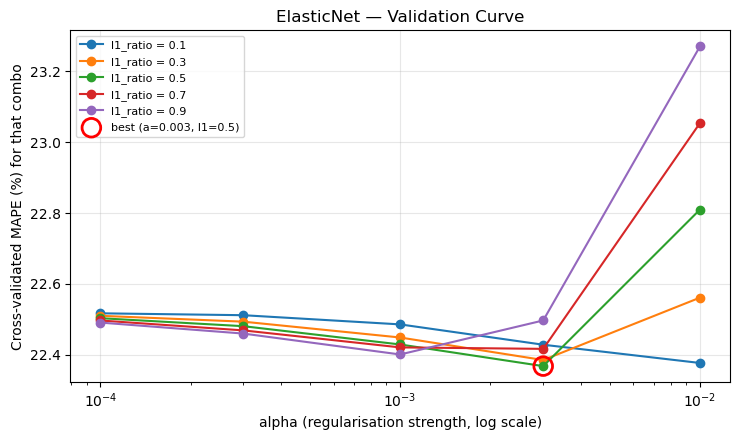

In [61]:
# Build the pipeline
enet_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("model",  ElasticNet(max_iter=5000, random_state=42)),
])

# Define the hyperparameter grid
enet_grid = {
    "model__alpha":    [0.0001, 0.0003, 0.001, 0.003, 0.01],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
}

# Configure the grid search
enet_search = GridSearchCV(
    enet_pipe,
    enet_grid,
    cv=CV,
    scoring=mape_scorer,
    n_jobs=-1,
    return_train_score=True,
)

# Run the search
enet_search.fit(X_train, y_train_log)

# Extract the winning model and its score
enet_best        = enet_search.best_estimator_
enet_best_params = enet_search.best_params_
enet_best_mape   = -enet_search.best_score_   # real-AUD MAPE (scorer back-transforms with expm1)

# Print the results
print("=" * 55)
print("BEST ELASTICNET MODEL")
print("=" * 55)
print(f"Best params : {enet_best_params}")
print(f"Best CV MAPE (real AUD): {enet_best_mape:.4f}")

# Pull the train vs. validation scores for the winning combination
best_idx        = enet_search.best_index_
mean_train_mape = -enet_search.cv_results_["mean_train_score"][best_idx]
mean_val_mape   = -enet_search.cv_results_["mean_test_score"][best_idx]
print(f"Mean train MAPE: {mean_train_mape:.4f}")
print(f"Mean val   MAPE: {mean_val_mape:.4f}")
print(f"Gap (val - train): {mean_val_mape - mean_train_mape:.4f}")

# View combinations as a DataFrame
results = pd.DataFrame(enet_search.cv_results_)

# Keep the most informative columns and convert scores back to positive MAPE
summary = pd.DataFrame({
    "alpha":      results["param_model__alpha"],
    "l1_ratio":   results["param_model__l1_ratio"],
    "train_MAPE": -results["mean_train_score"],
    "val_MAPE":   -results["mean_test_score"],
    "val_std":    results["std_test_score"],
})
summary["gap"] = summary["val_MAPE"] - summary["train_MAPE"]

# Sort so the best (lowest) validation MAPE is on top
summary = summary.sort_values("val_MAPE").reset_index(drop=True)

print("\n" + "=" * 55)
print("TOP 10 COMBINATIONS (sorted by validation MAPE)")
print("=" * 55)
print(summary.head(10).to_string(index=False))

# ElasticNet — visualise tuning (validation curve)
# ElasticNet has TWO hyperparameters, so we draw one line per l1_ratio.
#   x-axis = alpha (log scale), y-axis = CV MAPE for that combo.
# The red circle marks the best (alpha, l1_ratio) = best bias/variance balance.

# pull every tried combo and its CV MAPE out of the grid search results
res = pd.DataFrame(enet_search.cv_results_)
res["alpha"]    = res["param_model__alpha"].astype(float)
res["l1_ratio"] = res["param_model__l1_ratio"].astype(float)
res["mape"]     = -res["mean_test_score"] * 100        # flip sign, convert to %

plt.figure(figsize=(7.5, 4.5))
# one curve per l1_ratio so we can see how the L1/L2 mix changes things
for l1, grp in res.groupby("l1_ratio"):
    grp = grp.sort_values("alpha")
    plt.plot(grp["alpha"], grp["mape"], marker="o", label=f"l1_ratio = {l1}")

# highlight the single best combination the search chose
best_a  = enet_search.best_params_["model__alpha"]
best_l1 = enet_search.best_params_["model__l1_ratio"]
best_m  = -enet_search.best_score_ * 100
plt.scatter([best_a], [best_m], s=180, facecolors="none", edgecolors="red",
            linewidths=2, zorder=5, label=f"best (a={best_a}, l1={best_l1})")

plt.xscale("log")                          # alphas span several orders of magnitude
plt.xlabel("alpha (regularisation strength, log scale)")
plt.ylabel("Cross-validated MAPE (%) for that combo")
plt.title("ElasticNet — Validation Curve")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Features removed by ElasticNet: 27
['host_response_rate', 'beds', 'amen_standalone_high_chair_-_a', 'amen_pack_n_play/travel_crib', 'amen_pack_n_play/travel_crib_-', 'amen_shared_outdoor_pool_-_ava', 'amen_movie_theater', 'amen_noise_decibel_monitors_on', 'amen_free_resort_access', 'amen_tv_with_standard_cable', 'amen_free_residential_garage_o', 'amen_resort_access', 'amen_stainless_steel_gas_stove', 'amen_outdoor_kitchen', 'amen_shared_sauna', 'amen_ethernet_connection', 'amen_portable_heater', 'amen_shared_backyard_fully_fen', 'amen_breakfast', 'amen_kitchenette', 'amen_bread_maker', 'amen_mosquito_net', 'amen_shared_patio_or_balcony', 'amen_private_living_room', 'property_type_Entire home', 'room_type_Shared room', 'location_cluster_1']


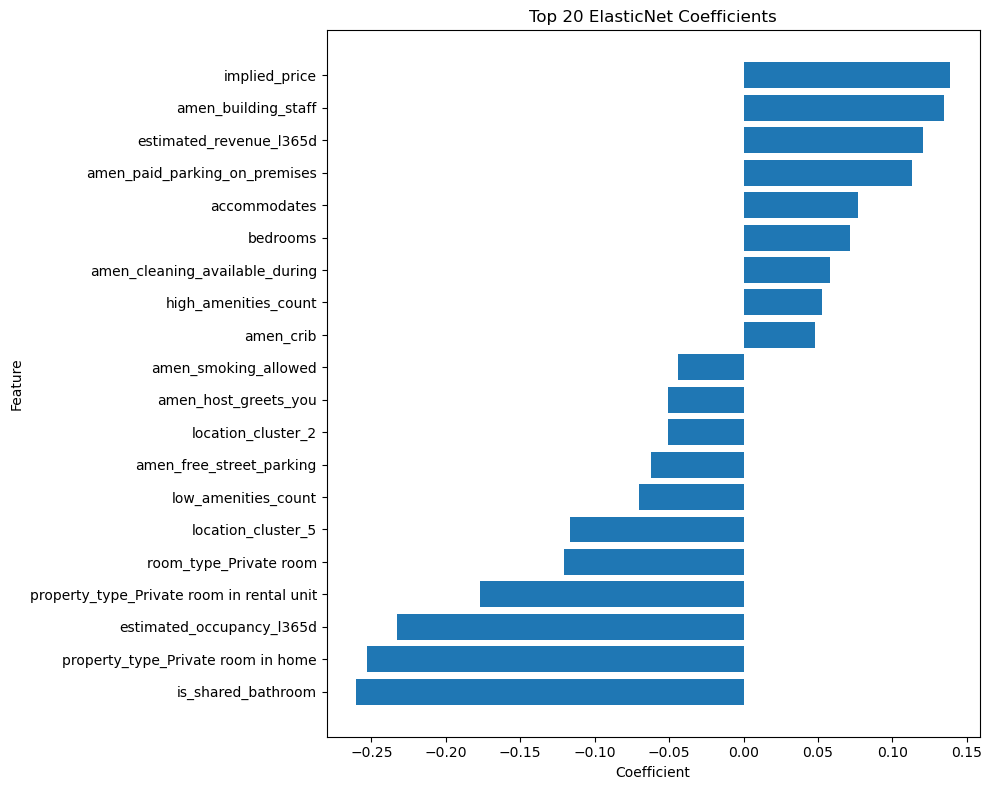

In [62]:
# Features removed by ElasticNet
# Extract fitted ElasticNet model from the pipeline
enet_model = enet_best.named_steps["model"]
coef_df = pd.DataFrame({

    "feature": X_train.columns,
    "coefficient": enet_model.coef_
})

# Absolute magnitude helps rank importance
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

zero_features = coef_df[coef_df["coefficient"] == 0]

print(f"Features removed by ElasticNet: {len(zero_features)}")
print(zero_features["feature"].tolist())

# Top Important Features of ElasticNet
top_n = 20

plot_df = (
    coef_df.sort_values("abs_coefficient", ascending=False)
           .head(top_n)
           .sort_values("coefficient")
)

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title(f"Top {top_n} ElasticNet Coefficients")
plt.tight_layout()
plt.show()

**ElasticNet tuning discussion**

The grid search selected **alpha = 0.003** with **l1_ratio = 0.5**, giving a cross-validated MAPE of **22.37%** (mean validation 0.2237 vs mean training 0.2191). The top-10 table is essentially flat: every combination lands between 22.37% and 22.46%, so the model is insensitive to the exact penalty within this range. This indicates that the model's predictive performance is largely insensitive to further regularisation tuning, suggesting that the dominant limitation is model form rather than hyperparameter choice.

Two things stand out:
- First, the very small **alpha** means that stronger regularisation consistently reduced performance (heavy penalization does not help). This indicates that model complexity is not the primary issue; rather, the linear assumption itself appears to limit predictive accuracy. The train–validation gap values at each time point are small, indicating that the linear model is already underfitting rather than overfitting.
- Second, **l1_ratio = 0.5** splits the penalty evenly between L1 (Lasso) and L2 (Ridge); the L1 component is what drives the 27 dropped features in the next cell, while the L2 component keeps the retained coefficients stable when predictors are correlated.

The **mean gap of only 0.5%** between training and validation MAPE is the headline: training and validation errors are almost identical, a signature of **underfitting**. The model is about as good on the data it has seen as on the data it has not. There is simply a hard limit to how well a straight-line relationship can describe price. This motivates the non-linear tree models that follow.

**Features retained vs dropped by ElasticNet**

The L1 penalty zeroed out **27 of the candidate features**. The dropped set shares clear characteristics: it is dominated by **sparse, rare-amenity dummies** (`amen_bread_maker`, `amen_movie_theater`, `amen_outdoor_kitchen`, etc.) and a few **redundant or low-signal columns** (`property_type_Entire home`, `location_cluster_1`). These are features that are either almost always 0 (so they carry little variance to explain price) or are **collinear with a stronger version of the same information** already in the model. For example, `property_type_Entire home` overlaps heavily with `room_type`, and `availability_90` overlaps with the other availability windows.

The common thread is that ElasticNet **keeps features with broad, linearly useful variation** and discards those whose signal is **rare, redundant, or useful only in interaction with another feature**. This last point matters for the model comparison: a niche amenity may only raise price *in combination with* room type or location — a non-linear interaction a linear model cannot represent. ElasticNet can assign each feature only one fixed coefficient, making it difficult to exploit features whose values depend on interactions with other predictors. This makes such variables more likely to receive negligible coefficients or be removed entirely. The tree models, by contrast, can split on exactly these conditional patterns, which is part of why they outperform the linear model so heavily.

**Model 2: Random Forest**

In [63]:
# Tune RANDOM FOREST with cross-validation
# No scaling needed, so no Pipeline. We use the TREE dataset.
# Instantiate the Random Forest estimator
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Define the hyperparameter grid
#   n_estimators     : number of trees. More trees lower variance through averaging
#   max_depth        : how deep each tree grows. Deeper captures finer interactions but risks overfitting.
#   min_samples_leaf : minimum rows allowed in a leaf. 1 lets a tree fit individual points (max flexibility),
#                      higher will smoother predictions and regularizes. We search a small range around 1.
#   max_features     : fraction of features each split may consider.
#                      RF's key de-correlation lever — lower values force
#                      trees to differ more (more diverse -> better
#                      averaging); 1.0 lets every split see all features.
#                      We keep the two strongest performers (0.8 and 1.0).
rf_grid = {
    "n_estimators":     [500],              # plot/earlier runs showed 500 ≈ 800 (checked with 1000)
    "max_depth":        [10, 20, 30, 40, 50, None],
    "min_samples_leaf": [1, 2, 5, 10, 20],          # small range around 1
    "max_features":     [0.8, 1.0],         # strongest performers (checked with .7 and .9)
}

# Configure the grid search
# Same CV splitter and scorer as the ElasticNet search
rf_search = GridSearchCV(
    rf,
    rf_grid,
    cv=CV,
    scoring=mape_scorer,
    n_jobs=-1,
    return_train_score=True,
)


# Run the search
rf_search.fit(X_train_tree, y_train_tree_log)

# Extract the winning model and its score
rf_best      = rf_search.best_estimator_   # refit on all data, ready to .predict()
rf_best_mape = -rf_search.best_score_       # flip sign -> real MAPE

# Print the results
print("=" * 50)
print("RANDOM FOREST — best hyperparameters")
print("=" * 50)
for k, v in rf_search.best_params_.items():
    print(f"   {k:18s} = {v}")
print(f"   CV MAPE = {rf_best_mape * 100:.2f}%")

# Train vs. validation for the winning combination — the overfitting check.
best_idx        = rf_search.best_index_
mean_train_mape = -rf_search.cv_results_["mean_train_score"][best_idx]
mean_val_mape   = -rf_search.cv_results_["mean_test_score"][best_idx]

print(f"   Mean train MAPE   = {mean_train_mape * 100:.2f}%")
print(f"   Mean val   MAPE   = {mean_val_mape * 100:.2f}%")
print(f"   Gap (val - train) = {(mean_val_mape - mean_train_mape) * 100:.2f}%")


# View ALL combinations as a sorted table
results = pd.DataFrame(rf_search.cv_results_)

summary = pd.DataFrame({
    "n_estimators":     results["param_n_estimators"],
    "max_depth":        results["param_max_depth"],
    "min_samples_leaf": results["param_min_samples_leaf"],
    "max_features":     results["param_max_features"],
    "train_MAPE":       -results["mean_train_score"] * 100,
    "val_MAPE":         -results["mean_test_score"] * 100,
    "val_std":          results["std_test_score"] * 100,   # stability across folds
})
summary["gap"] = summary["val_MAPE"] - summary["train_MAPE"]

# Lowest validation MAPE on top.
print("\n" + "=" * 55)
print("TOP 10 COMBINATIONS (sorted by validation MAPE)")
print("=" * 55)
summary = summary.sort_values("val_MAPE").reset_index(drop=True)
print(summary.head(10).to_string(index=False))

RANDOM FOREST — best hyperparameters
   max_depth          = 20
   max_features       = 1.0
   min_samples_leaf   = 1
   n_estimators       = 500
   CV MAPE = 5.82%
   Mean train MAPE   = 2.07%
   Mean val   MAPE   = 5.82%
   Gap (val - train) = 3.75%

TOP 10 COMBINATIONS (sorted by validation MAPE)
 n_estimators max_depth  min_samples_leaf  max_features  train_MAPE  val_MAPE  val_std      gap
          500        20                 1           1.0    2.073546  5.822486 0.867209 3.748940
          500        30                 1           1.0    2.068478  5.832328 0.871464 3.763850
          500        50                 1           1.0    2.068501  5.832874 0.871395 3.764373
          500      None                 1           1.0    2.068501  5.832874 0.871395 3.764373
          500        40                 1           1.0    2.068501  5.832874 0.871395 3.764373
          500        40                 2           1.0    2.455143  5.841212 0.872907 3.386069
          500        30    

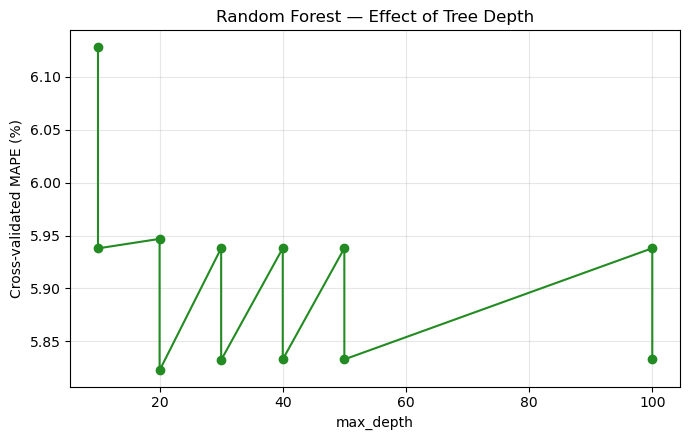

In [64]:
# Visualise Random Forest tuning
rf_res = pd.DataFrame(rf_search.cv_results_)
rf_res["mape"] = -rf_res["mean_test_score"] * 100

# keep rows that match the best n_estimators and min_samples_leaf,
# so the line isolates the effect of max_depth alone
best = rf_search.best_params_
mask = ((rf_res["param_n_estimators"] == best["n_estimators"]) &
        (rf_res["param_min_samples_leaf"] == best["min_samples_leaf"]))
sub = rf_res[mask].copy()
# replace None depth with a large number so it plots at the right end
sub["depth_plot"] = sub["param_max_depth"].apply(lambda d: 100 if d is None else d)
sub = sub.sort_values("depth_plot")

plt.figure(figsize=(7, 4.5))
plt.plot(sub["depth_plot"], sub["mape"], marker="o", color="forestgreen")
plt.xlabel("max_depth")
plt.ylabel("Cross-validated MAPE (%)")
plt.title("Random Forest — Effect of Tree Depth")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

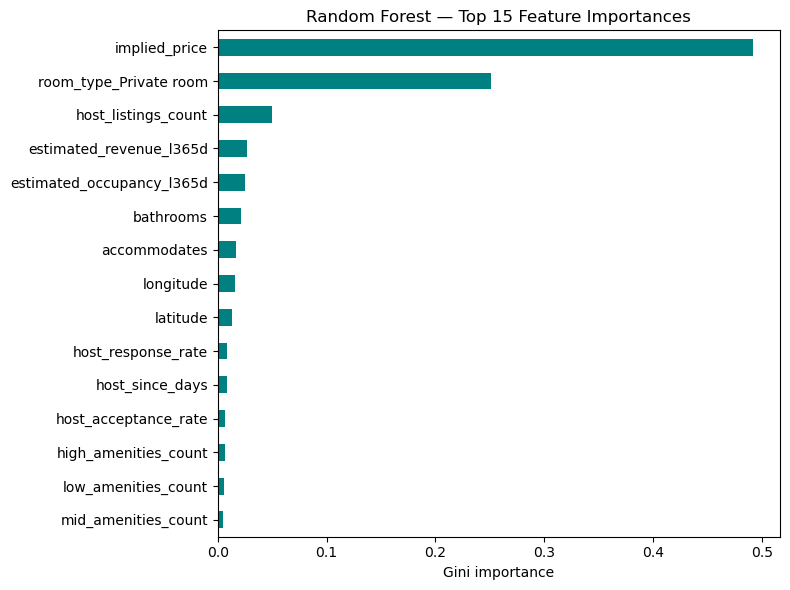

Most important features:


implied_price                0.4921
room_type_Private room       0.2511
host_listings_count          0.0501
estimated_revenue_l365d      0.0264
estimated_occupancy_l365d    0.0247
bathrooms                    0.0210
accommodates                 0.0167
longitude                    0.0156
latitude                     0.0131
host_response_rate           0.0083
host_since_days              0.0083
host_acceptance_rate         0.0069
high_amenities_count         0.0069
low_amenities_count          0.0058
mid_amenities_count          0.0046
dtype: float64

In [65]:
# Most important features
importance = (pd.Series(rf_search.best_estimator_.feature_importances_,
                        index=X_train_tree.columns)
                  .sort_values(ascending=False).head(15))
title = "Random Forest — Top 15 Feature Importances"

plt.figure(figsize=(8, 6))
importance.sort_values().plot(kind="barh", color="teal")
plt.xlabel("Gini importance")
plt.title(title)
plt.tight_layout(); plt.show()

print("Most important features:")
display(importance.round(4))

**Model 3: Gradient Boosting**

In [66]:
# Instantiate the Gradient Boosting estimator
gb = GradientBoostingRegressor(random_state=42)


# Define the hyperparameter grid
# ============================================================
#   n_estimators  : number of sequential trees. Unlike RF, MORE IS NOT always safer here 
#                   — too many trees keep fitting the training data and eventually overfit.
#                   This is coupled with learning_rate (below).
#   learning_rate : how much each tree's correction counts. 
#                   Smaller = safer, more gradual learning, but needs MORE trees to
#                   reach the same fit. 
#                   Trade-off: low rate + many trees usually generalizes best.
#   max_depth     : complexity of each individual tree. Kept SHALLOW (2-4) on purpose.
#                   Boosting uses "weak learners" —
#                   each tree captures a small piece of the pattern, and
#                   the sequence combines them. Deep trees is easy to be overfitting
#                   because each is already strong and errors compound.
gb_grid = {
    "n_estimators":  [200, 400],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth":     [2, 3, 4],
}

# Configure the grid search
gb_search = GridSearchCV(
    gb,
    gb_grid,
    cv=CV,
    scoring=mape_scorer,
    n_jobs=-1,
    return_train_score=True,
)

# Run the search
gb_search.fit(X_train_tree, y_train_tree_log)

# Extract the winning model and its score
gb_best      = gb_search.best_estimator_   # refit on all data, ready to .predict()
gb_best_mape = -gb_search.best_score_       # flip sign -> real MAPE

# Print the results
print("=" * 55)
print("GRADIENT BOOSTING — best hyperparameters")
print("=" * 55)
for k, v in gb_search.best_params_.items():
    print(f"   {k:14s} = {v}")
print(f"   CV MAPE = {gb_best_mape * 100:.2f}%")

# Train vs. validation for the winning combination — the overfitting check.
# This gap is more meaningful for GB than for RF: because boosting can
# genuinely overfit, a large gap here is a real warning sign (unlike RF,
# where near-perfect train scores are normal and expected).
best_idx        = gb_search.best_index_
mean_train_mape = -gb_search.cv_results_["mean_train_score"][best_idx]
mean_val_mape   = -gb_search.cv_results_["mean_test_score"][best_idx]
print(f"   Mean train MAPE   = {mean_train_mape * 100:.2f}%")
print(f"   Mean val   MAPE   = {mean_val_mape * 100:.2f}%")
print(f"   Gap (val - train) = {(mean_val_mape - mean_train_mape) * 100:.2f}%")


# Top 10 combinations as a sorted table
results = pd.DataFrame(gb_search.cv_results_)

summary = pd.DataFrame({
    "n_estimators":  results["param_n_estimators"],
    "learning_rate": results["param_learning_rate"],
    "max_depth":     results["param_max_depth"],
    "train_MAPE":    -results["mean_train_score"] * 100,
    "val_MAPE":      -results["mean_test_score"] * 100,
    "val_std":       results["std_test_score"] * 100,   # stability across folds
})
summary["gap"] = summary["val_MAPE"] - summary["train_MAPE"]

# Lowest validation MAPE on top.
summary = summary.sort_values("val_MAPE").reset_index(drop=True)

print("\n" + "=" * 55)
print("TOP 10 COMBINATIONS (sorted by validation MAPE)")
print("=" * 55)
print(summary.head(10).to_string(index=False))

GRADIENT BOOSTING — best hyperparameters
   learning_rate  = 0.1
   max_depth      = 4
   n_estimators   = 400
   CV MAPE = 7.27%
   Mean train MAPE   = 2.23%
   Mean val   MAPE   = 7.27%
   Gap (val - train) = 5.04%

TOP 10 COMBINATIONS (sorted by validation MAPE)
 n_estimators  learning_rate  max_depth  train_MAPE  val_MAPE  val_std      gap
          400           0.10          4    2.234743  7.274692 1.101982 5.039949
          400           0.05          4    3.585154  7.286216 1.106324 3.701062
          400           0.03          4    4.641928  7.333478 1.119567 2.691550
          200           0.10          4    3.611796  7.356605 1.191165 3.744809
          200           0.05          4    5.007853  7.429767 1.115274 2.421914
          200           0.03          4    5.942528  7.614124 1.112611 1.671597
          400           0.10          3    4.309845  8.009274 1.161538 3.699429
          400           0.05          3    5.694726  8.078662 1.194068 2.383935
          200 

**Interpretation — Random Forest and Gradient Boosting tuning**

**Random Forest** achieved its best at **max_depth = 20, max_features = 1.0, min_samples_leaf = 1, n_estimators = 500**, reaching a CV MAPE of **5.82%**. The tuning pattern is informative. Validation performance was almost identical for depths of 20, 30, 40, 50 and `None` (all ≈ 5.83%), suggesting that once the trees were deep enough to capture the main patterns in the data, additional depth provided little benefit.
The best performance was obtained with `min_samples_leaf = 1` and `max_features = 1.0`, meaning that fully grown trees and access to all available features at each split were beneficial. This suggests that a small number of highly informative predictors contribute strongly to price prediction.

**Gradient Boosting** achieved its best performance at **learning_rate = 0.1, max_depth = 4, and n_estimators = 400**, with a **CV MAPE of 7.27%**. The grid shows the expected boosting trade-off. The larger learning rate (0.1) achieved the lowest validation error, while smaller rates (0.05 and 0.03) drove training error down further but did not improve, and at times worsened, validation performance — a sign that the extra fitting was being spent on noise rather than signal. Trees with **depth 3–4** consistently performed best, which is consistent with boosting methods generally working well with relatively simple base learners. Even so, Gradient Boosting remained the weakest of the tree models here, with the largest train–validation gap among them, indicating it overfit more than Random Forest without a corresponding gain in validation accuracy.

Overall, the Random Forest configuration was selected as the best model because it achieved the lowest validation MAPE and maintained stable performance across a wide range of depth values. This suggests that its performance is robust and not highly dependent on a single hyperparameter setting.

**Models Comparision**

,Model,CV MAPE (%),Train MAPE (%),Gap (CV - Train)
0,Random Forest,5.82,2.06,3.76
1,Gradient Boosting,7.27,3.07,4.21
2,ElasticNet,22.37,21.93,0.44


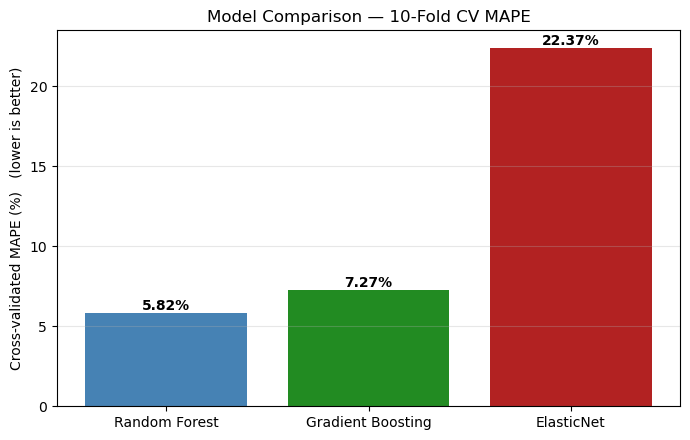

In [68]:
# Lower MAPE = better. 
# The training MAPE of each tuned model: a big gap (train much lower than CV) signals overfitting.
def train_mape(fitted_model, X, y_log):
    """MAPE of a fitted model on the data it was trained on (real AUD)."""
    return mape_on_real_price(y_log, fitted_model.predict(X)) * 100

# refit each best model on its full dataset to read a training score
enet_best = enet_search.best_estimator_
rf_best    = rf_search.best_estimator_
gb_best    = gb_search.best_estimator_

results = pd.DataFrame({
    "Model": ["ElasticNet", "Random Forest", "Gradient Boosting"],
    "CV MAPE (%)": [enet_best_mape*100, rf_best_mape*100, gb_best_mape*100],
    "Train MAPE (%)": [
        train_mape(enet_best, X_train,      y_train_log),
        train_mape(rf_best,    X_train_tree, y_train_tree_log),
        train_mape(gb_best,    X_train_tree, y_train_tree_log),
    ],
})

# gap between CV and train error: large positive gap = sign of overfitting
results["Gap (CV - Train)"] = results["CV MAPE (%)"] - results["Train MAPE (%)"]
results = results.sort_values("CV MAPE (%)").reset_index(drop=True)
display(results.round(2))

# Bar chart comparing CV MAPE of the three models
plt.figure(figsize=(7, 4.5))
bars = plt.bar(results["Model"], results["CV MAPE (%)"],
               color=["steelblue", "forestgreen", "firebrick"])
# label each bar with its value
for b, v in zip(bars, results["CV MAPE (%)"]):
    plt.text(b.get_x()+b.get_width()/2, v+0.2, f"{v:.2f}%",
             ha="center", fontweight="bold")
plt.ylabel("Cross-validated MAPE (%)   (lower is better)")
plt.title("Model Comparison — 10-Fold CV MAPE")
plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

**Best and worst models**. **Random Forest** achieved the lowest CV MAPE (5.82%) and therefore performed best overall. **ElasticNet** performed worst (22.37%), while the other tree-based models achieved similar results between 5.82% and 7.27%.

The gap is exactly what the model mechanics predict. As noted in 3.1, price is a wide, right-skewed target driven by **non-linear effects and interactions** (a pool matters more for an entire home than a private room; location interacts with capacity). Tree ensembles split the feature space recursively, so they capture these interactions and thresholds automatically. ElasticNet, being linear, must assign each feature a single fixed coefficient and sum them — it can only fit an additive, straight-line relationship and is structurally blind to interactions. 

**These results are consistent with the expectations established earlier**. In Section 3.1, ElasticNet was selected as a linear baseline, while Random Forest and Gradient Boosting were chosen because they can model non-linear relationships and feature interactions. The large performance gap between ElasticNet and the tree-based models suggests that **important non-linear relationships exist in the data**. This is also consistent with the ElasticNet feature-selection results, where several sparse amenity variables were removed because their effects are likely conditional on other features. Tree-based models can naturally capture such interactions, whereas ElasticNet can only assign a single coefficient to each feature.

Among trees, Random Forest slightly outperformed the boosting models. The feature importance analysis suggests that a small number of predictors contribute strongly to price prediction. Random Forest can exploit these strong predictors effectively by averaging many deep trees. In contrast, the additional complexity of boosting provided little improvement and showed stronger signs of overfitting through larger training-validation gaps.

**Overfitting / underfitting evidence from the gaps.**
| Model                  | Train MAPE (%) | CV MAPE (%) | Gap (CV - Train) | Assessment |
|------------------------|---------------:|------------:|-----------------:|------------|
| Random Forest          | 2.06           | 5.82        | 3.76             | Ok |
| Gradient Boosting      | 3.07           | 7.27        | 4.21             | Ok |
| ElasticNet             | 21.93          | 22.37       | 0.44             | Underfitting |

- Looking at the train-validation gaps, ElasticNet shows strong evidence of underfitting - a near-zero gap (0.44%). The model is too simple to capture the signal, so it fails equally everywhere. 
- Tree-based models show moderate gaps (≈3.8–4.2%) with low validation error. This can expect that overfitting that is well-controlled; the validation score is what matters and it is strong. Among the tree models, Random Forest provides the best balance between predictive performance and model stability, making it the preferred model for final testing and Kaggle submission.

Overall the comparison cleanly separates an underfitting linear baseline from a family of well-performing non-linear models, with Random Forest the clear choice to carry forward.

Residual analysis for best model: Random Forest


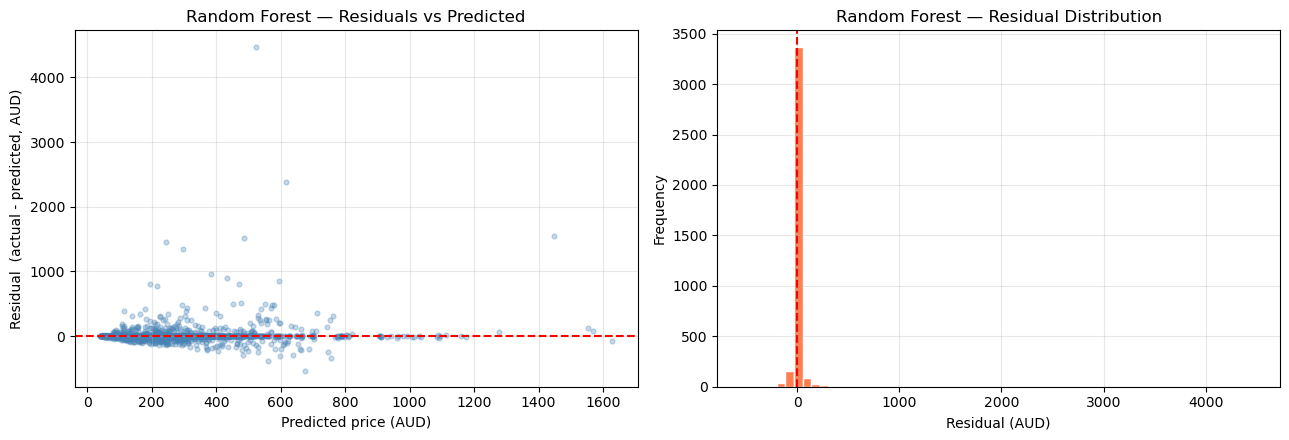

Mean residual:       6.57 AUD  (close to 0 = unbiased)
Median residual:    -0.00 AUD


In [ ]:
# Residual analysis on the BEST model
# We use cross_val_predict so every prediction is made on a fold the
# model did NOT see (honest, leak-free residuals). Residuals are in AUD.

from sklearn.model_selection import cross_val_predict

# pick the best model + its matching dataset based on the results table
best_name = results.iloc[0]["Model"]
if best_name == "ElasticNet":
    best_model, X_best, y_best_log = enet_best, X_train, y_train_log
else:   # both tree models share the tree dataset
    best_model = rf_best if best_name == "Random Forest" else gb_best
    X_best, y_best_log = X_train_tree, y_train_tree_log

print(f"Residual analysis for best model: {best_name}")

# cross-validated predictions, converted back to dollars
pred_log = cross_val_predict(best_model, X_best, y_best_log, cv=CV)
y_actual = np.expm1(y_best_log)      # true price in AUD
y_pred   = np.expm1(pred_log)        # predicted price in AUD
residuals = y_actual - y_pred        # AUD over/under-prediction

# --- two plots side by side ---
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# (1) residuals vs predicted price
ax[0].scatter(y_pred, residuals, alpha=0.3, s=12, color="steelblue")
ax[0].axhline(0, color="red", linestyle="--")    # the zero-error line
ax[0].set_xlabel("Predicted price (AUD)")
ax[0].set_ylabel("Residual  (actual - predicted, AUD)")
ax[0].set_title(f"{best_name} — Residuals vs Predicted")
ax[0].grid(alpha=0.3)

# (2) distribution of residuals
ax[1].hist(residuals, bins=60, color="coral", edgecolor="white")
ax[1].axvline(0, color="red", linestyle="--")
ax[1].set_xlabel("Residual (AUD)")
ax[1].set_ylabel("Frequency")
ax[1].set_title(f"{best_name} — Residual Distribution")
ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Mean residual:   {residuals.mean():8.2f} AUD  (close to 0 = unbiased)")
print(f"Median residual: {residuals.median():8.2f} AUD") 

**Interpretation — Random Forest residuals**

The residual diagnostics on the best model (Random Forest) are healthy. The **mean residual is +6.57 AUD and the median is essentially 0**, so the model is close to unbiased — it is not systematically over- or under-predicting price across the bulk of listings. 

The residuals were computed using cross-validated predictions on held-out folds, providing an estimate of performance on unseen data. Combined with the training-validation gap observed during tuning (training MAPE 2.06% vs CV 5.82%, a gap of ~3.8%), the results suggest **mild but well-controlled overfitting**. The residual plot shows that model fits the training data more tightly than unseen data, as all flexible tree models do, but the validation error remains low and stable, so the gap is not large enough to indicate a problem.

There is no sign of **underfitting** (validation error is far below the linear baseline). The slight positive mean residual reflects the long right tail of high-priced listings, where percentage errors are hardest to control — consistent with the known MAPE behaviour discussed in Task 1.

Random Forest residual diagnostics are generally positive. **The mean residual is +6.57 AUD** and **the median residual is approximately 0 AUD**. With the presence of a few high-priced listings, this is naturally more difficult to predict accurately.

<hr style="width:25%;margin-left:0;">

#### 4. Best Model and Kaggle Submission


In [70]:
# Identify the best model (lowest CV MAPE)
# results is already sorted by CV MAPE (best first) from Task 3.3
best_name = results.iloc[0]["Model"]
best_cv   = results.iloc[0]["CV MAPE (%)"]
print(f"Best model: {best_name}  (CV MAPE = {best_cv:.2f}%)")

# map the name to the fitted estimator and its matching dataset
# ElasticNet uses the scaled X (X_train/X_test); the tree models use the tree X.
if best_name == "ElasticNet":
    final_model, X_full, X_kaggle = enet_best, X_train, X_test
else:
    final_model = rf_best if best_name == "Random Forest" else gb_best
    X_full, X_kaggle = X_train_tree, X_test_tree

# y target is the log price (same for all three, just different objects)
y_full = y_train_log if best_name == "ElasticNet" else y_train_tree_log

Best model: Random Forest  (CV MAPE = 5.82%)


In [ ]:
# Refit on ALL training data and predict the test set
# We train on the full data (no fold held back) for the strongest final model,
# predict in log-space, then convert back to real AUD with np.expm1().
final_model.fit(X_full, y_full)                 # learn from every training row
test_pred_log = final_model.predict(X_kaggle)   # predictions on the log scale
test_pred     = np.expm1(test_pred_log)          # convert back to dollars (AUD)

# safety: prices cannot be negative — clip just in case
test_pred = np.clip(test_pred, 1, None)

print(f"Generated {len(test_pred)} predictions.")
print(f"Predicted price range: AUD {test_pred.min():.0f} to AUD {test_pred.max():.0f}")
print(f"Median predicted price: AUD {np.median(test_pred):.0f}")


Generated 1601 predictions.
Predicted price range: AUD 40 to AUD 1781
Median predicted price: AUD 193


In [ ]:
# Build the Kaggle submission and export to Excel
# The submission needs the listing id and the predicted price.
# Read the id straight from the original test file so the order is correct.
test_ids = pd.read_csv("data/test.csv")["ID"].values

final_prediction = pd.DataFrame({
    "ID":    test_ids,
    "price": test_pred
})

# --- export to CSV---
final_prediction.to_csv("final_prediction_20260603.csv", index=False)
print("Saved final_prediction.csv")
display(final_prediction.head())

Saved submission.csv


,ID,price
0,3735,231.027924
1,3736,48.614569
2,3737,389.332637
3,3738,181.791912
4,3739,223.995973


<br> Our submission scored 0.069 (≈6.9% MAPE), around ranked 30th at capture time. However, as the mistake submit in the past, and it doesn't allow us to reset. Instead it shows the highest score.

6.9%  is slightly *higher* (worse) than our cross-validated estimate of 5.82%, which is the normal and expected pattern: CV is measured on training folds, while the leaderboard uses genuinely unseen listings, so a small drop in performance is healthy and indicates the model generalises rather than overfits. 
Besides, because the public leaderboard is calculated on only ~50% of the test data, it is a noisy estimate rather than an exact measure — the same model could score slightly differently on another 50% slice, so both the score and the rank carry uncertainty.

<hr style="width:25%;margin-left:0;">

#### 5. Model Improvement and Reflection


**Improvement to the project discussion:**

**1. Add Histogram Gradient Boosting.**

HistGradientBoosting is a modern tree-boosting algorithm that first groups continuous feature values into bins before building trees sequentially.

The binning makes it dramatically faster and more memory-efficient than classic Gradient Boosting while usually matching or beating its accuracy, and it has **built-in L2 regularisation** to reduce overfitting.

Since the strongest models in this project were already tree ensembles, HistGradientBoosting was a natural extension to investigate.

It improved on standard Gradient Boosting (**6.92% vs 7.27% CV MAPE**) and showed a smaller train-validation gap, suggesting better generalisation. However, it still did not outperform the Random Forest model.

**2. Add Extra Trees.**

Extra Trees (Extremely Randomised Trees) is an ensemble method closely related to Random Forest. The key difference is that split thresholds are chosen more randomly. This makes individual trees weaker and more varied, which **lowers variance** further through averaging and **reduces** training time.

It was worth trying because added diversity sometimes generalises better than Random Forest on noisy data.

In this project, Extra Trees achieved a CV MAPE of **6.86%**, outperforming both boosting models but remaining behind Random Forest. Although the model achieved almost perfect training performance, it also showed the largest train-validation gap, indicating stronger signs of overfitting. This suggests that the additional randomness did not improve generalisation on this dataset.

| Model                  | Train MAPE (%) | CV MAPE (%) | Gap (CV - Train) | Assessment |
|------------------------|---------------:|------------:|-----------------:|------------|
| Random Forest          | 2.06           | 5.82        | 3.76             | Ok |
| Extra Trees            | 0.24           | 6.86        | 6.61             | Overfitting |
| Hist Gradient Boosting | 3.21           | 6.92        | 3.71             | Ok|
| Gradient Boosting      | 3.07           | 7.27        | 4.21             | Ok |
| ElasticNet             | 21.93          | 22.37       | 0.44             | Underfitting |

**3. Using Ensemble Voting for the Top 3 Models.**

A VotingRegressor combines multiple models by **averaging their predictions**. This can improve performance when the individual models are similar in skill but make different types of errors, so that averaging cancels out their mistakes.

The ensemble was built using the three strongest models: Random Forest, Extra Trees, and HistGradientBoosting because effective ensembles combine members that each perform well on their own.

While all three are tree-based, they differ in how they build trees: bagging (Random Forest), bagging with extra split randomisation (Extra Trees), and boosting (HistGradientBoosting). These three different approaches can in principle produce somewhat decorrelated errors, the property an ensemble relies on to improve on its individual members. ElasticNet was excluded because its substantially higher validation error meant that, under averaging, it would pull predictions toward its poor estimates and contribute more noise than useful information.

**Kaggle result — voting ensemble**
The Kaggle result is lower (0.072) compare to the previous submition. This is consistent with the cross-validation scores: RF scored **5.82%** and the ensemble **6.12%**.

**Reflection on the result & Why this improvement approach didn't work**

The Voting Regressor achieved a CV MAPE of **6.12%**, which is slightly worse than the tuned Random Forest (**5.82%**). Voting ensembles perform best when the component models have both strong predictive performance and errors that are different from one another, so that averaging cancels mistakes rather than blending them.

Here, neither condition held well enough: Extra Trees and HistGradientBoosting were weaker than Random Forest, and because all three are tree-based models **trained on the same features**, their errors were highly correlated. The similar validation performance (**5.82% to 6.92%**) suggests that they tended to learn largely the same signal from the data. With little decorrelation benefit to offset the dilution, the ensemble did not improve on the leading model.

Therefore, the tuned Random Forest remains the preferred solution. It achieved the lowest cross-validated error, outperformed the ensemble, and provides a simpler modelling pipeline with no loss of accuracy.

**Main limitations and future work**

On top of the five models above, we also tried the gradient-boosting libraries that usually win on tabular data — **XGBoost, LightGBM, and CatBoost**. None of them beat the Random Forest. In fact, every capable model we tried, even though they work in very different ways, clustered in a narrow **~6–7% error band**, with none breaking below Random Forest's ~6%.

=> When many different, powerful models all get stuck at the same score, the problem is no longer the model — it's the **data features**. So the limitations below are about the data and the price itself, not about which algorithm we picked.

**The model leans on one feature that is almost a copy of the answer.** Just two features explain about **74% of the Random Forest's decisions**: `implied_price` (49%) and `room_type` (25%). The issue is that `implied_price` was built from revenue and occupancy, so it is really **a stand-in for the price we are trying to predict**. This makes the model look more accurate than it truly is, and its performance would likely decline substantially if that feature were unavailable or calculated differently. Everything else barely contributes, so there isn't much *real* signal left for any model to use — which is exactly why every model stops at the same place.

* **The data is a single snapshot, so the model is blind to timing.** We only have one frozen moment of each listing, with no information about *when* a price applies. Airbnb prices, though, change with the seasons, weekends, holidays, and local events. Because none of that is in the data, no model can learn it — this is simply missing information, not a flaw in the modelling.

* **Prices are set by people, so part of the variation is just random.** Hosts choose their own prices, and two almost identical listings can be priced very differently for personal reasons. This adds a layer of randomness that **no model can fully predict**, and it is the most likely reason every capable model stalls in the same ~6–7% band.

* **The scoring metric (MAPE) is hardest on cheap and very expensive listings.** As explained in Task 1, MAPE punishes errors on low-priced listings much more, and the model struggles most with the small number of very high-priced listings (its average error leans slightly high, +7 AUD). So some of our error comes from the *way performance is measured*, not only from the predictions.

**Future directions.**

Because the real limit is *information*, future work should focus on **giving the model better data**, not on trying yet another model:

* **Build time-based (time-series) features.** Instead of one frozen price, collect each listing's price over time and create features such as the average weekend-vs-weekday price, the price in peak vs off-peak months, how far in advance people book, and how fast a listing fills up. This would let the model finally see the seasonal and demand patterns that drive price changes — the biggest piece currently missing.

* **Create new features that are independent of `implied_price`, so the model stops relying on a near-copy of the answer.** For example: pull keywords or themes from the listing's `description` and `amenities` text (e.g. "luxury", "beachfront", "budget"); cluster location features with a better geographic model; and use NLP to turn guest reviews into a sentiment score (how positive they are). These add genuinely *new* information about what makes a listing valuable, rather than re-using the price itself.

* **Check how much better any model could realistically get.** Before investing more effort, we could estimate the "noise floor" — for instance, by measuring how much the price varies between near-identical listings. If that natural variation is already close to 6%, it tells us the model is near the best score anyone could achieve on this data, and that further work would have little payoff.

Overall, the project suggests that predictive performance is now constrained more by the available information than by the choice of algorithm. Future improvements are therefore more likely to come from richer features and additional data sources than from further optimisation of the modelling approach.

**Conclusion & Business Insights**
The Random Forest model achieved the best predictive performance, demonstrating that Airbnb prices are driven by complex interactions among listing characteristics. The findings suggest that location, property features, and host-related attributes collectively influence pricing decisions. From a business perspective, the model could support data-driven pricing strategies by helping hosts benchmark properties and identify opportunities to improve revenue. However, the analysis is limited by the exclusion of textual features and the reliance on historical data, indicating opportunities for future enhancement.

**Model 4: Histogram Gradient Boosting**

In [74]:
# Tune HISTOGRAM GRADIENT BOOSTING
# No scaling needed; uses the TREE dataset and the log target.
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(random_state=42)

hgb_grid = {
    "learning_rate":     [0.03, 0.05, 0.1],
    "max_iter":          [300, 500],
    "max_leaf_nodes":    [15, 31, 63],
    "l2_regularization": [0.0, 1.0], #shrinks leaf values to fight overfitting
}

hgb_search = GridSearchCV(
    hgb, hgb_grid, cv=CV, scoring=mape_scorer,
    n_jobs=-1, return_train_score=True,
)
hgb_search.fit(X_train_tree, y_train_tree_log)

hgb_best_mape = -hgb_search.best_score_
print("HIST GRADIENT BOOSTING — best hyperparameters:")
for k, v in hgb_search.best_params_.items():
    print(f"   {k:18s} = {v}")
print(f"   CV MAPE = {hgb_best_mape*100:.2f}%")

HIST GRADIENT BOOSTING — best hyperparameters:
   l2_regularization  = 0.0
   learning_rate      = 0.03
   max_iter           = 300
   max_leaf_nodes     = 31
   CV MAPE = 6.92%


**Model 5: Extra trees**

In [76]:
# Tune EXTRA TREES (Extremely Randomized Trees)
# No scaling needed; uses the TREE dataset and the log target.
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(random_state=42, n_jobs=1)

et_grid = {
    "n_estimators":     [300, 500],
    "max_depth":        [5, 10, 15, 20, None],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features":     ["sqrt", 1.0],
}

et_search = GridSearchCV(
    et, et_grid, cv=CV, scoring=mape_scorer, n_jobs=-1,
    return_train_score=True
)
et_search.fit(X_train_tree, y_train_tree_log)

et_best_mape = -et_search.best_score_
print("EXTRA TREES — best hyperparameters:")
for k, v in et_search.best_params_.items():
    print(f"   {k:18s} = {v}")
print(f"   CV MAPE = {et_best_mape*100:.2f}%")

EXTRA TREES — best hyperparameters:
   max_depth          = 20
   max_features       = 1.0
   min_samples_leaf   = 1
   n_estimators       = 300
   CV MAPE = 6.86%


**Models Comparision**

,Model,CV MAPE (%),Train MAPE (%),Gap (CV - Train)
0,Random Forest,5.82,2.06,3.76
1,Extra Trees,6.86,0.24,6.61
2,Hist Gradient Boosting,6.92,3.21,3.71
3,Gradient Boosting,7.27,3.07,4.21
4,ElasticNet,22.37,21.93,0.44


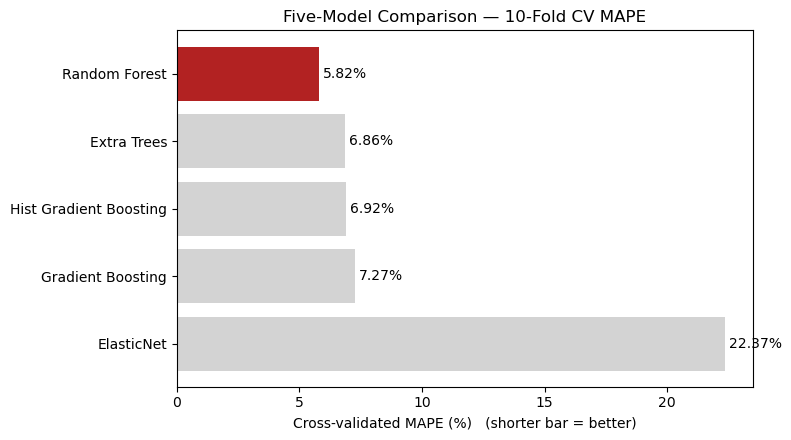

Best single model after adding advanced models: Random Forest (5.82%)


In [78]:
# Re-compare ALL FIVE single models on CV MAPE
# All five models are judged on the SAME 10-fold CV.
hgb_best = hgb_search.best_estimator_
et_best  = et_search.best_estimator_

results5 = pd.DataFrame({
    "Model": ["ElasticNet", "Random Forest", "Gradient Boosting",
              "Hist Gradient Boosting", "Extra Trees"],
    "CV MAPE (%)": [enet_best_mape*100, rf_best_mape*100, gb_best_mape*100,
                    hgb_best_mape*100,  et_best_mape*100],
    "Train MAPE (%)": [
        train_mape(enet_best, X_train,      y_train_log),
        train_mape(rf_best,    X_train_tree, y_train_tree_log),
        train_mape(gb_best,    X_train_tree, y_train_tree_log),
        train_mape(hgb_best,   X_train_tree, y_train_tree_log),
        train_mape(et_best,    X_train_tree, y_train_tree_log),
    ],
})
results5["Gap (CV - Train)"] = results5["CV MAPE (%)"] - results5["Train MAPE (%)"]
results5 = results5.sort_values("CV MAPE (%)").reset_index(drop=True)
display(results5.round(2))

# Visualise the five-model comparison
# Best (lowest MAPE) highlighted in red; others grey.
order5 = results5.sort_values("CV MAPE (%)", ascending=False)   # worst on top
best5_name = results5.iloc[0]["Model"]
colors5 = ["firebrick" if m == best5_name else "lightgrey"
           for m in order5["Model"]]

plt.figure(figsize=(8, 4.5))
bars = plt.barh(order5["Model"], order5["CV MAPE (%)"], color=colors5)
for b, v in zip(bars, order5["CV MAPE (%)"]):
    plt.text(v+0.15, b.get_y()+b.get_height()/2, f"{v:.2f}%", va="center")
plt.xlabel("Cross-validated MAPE (%)   (shorter bar = better)")
plt.title("Five-Model Comparison — 10-Fold CV MAPE")
plt.tight_layout(); plt.show()

print(f"Best single model after adding advanced models: {best5_name} "
      f"({results5.iloc[0]['CV MAPE (%)']:.2f}%)")

**Ensemble models with a VotingRegressor**

In [79]:
# Ensemble the BEST THREE models with a VotingRegressor
# A VotingRegressor trains each model and AVERAGES their predictions.
# We pick the top 3 from the five-model CV table, then evaluate the
# ensemble with the SAME 10-fold CV so it is comparable to the singles.

from sklearn.model_selection import cross_val_score

# evaluate_cv: run CV with the MAPE scorer; returns (mean, std) as FRACTIONS.
# Callers multiply by 100 when printing — that's why this stays a fraction.
def evaluate_cv(model, X, y_log, name):
    """Run 10-fold CV with the MAPE scorer and report mean +/- std (printed as %)."""
    scores = -cross_val_score(model, X, y_log, cv=CV, scoring=mape_scorer)
    print(f"{name:18s} | CV MAPE = {scores.mean()*100:5.2f}%  "
          f"(+/- {scores.std()*100:4.2f}%)")
    return scores.mean(), scores.std()

# train_mape_refit: refit on the full data, return Train MAPE on the real-AUD
# scale, as a PERCENTAGE. Named differently from the non-refitting train_mape()
# defined in Task 3.3 so re-running cells out of order can't swap one for the
# other (this one has a .fit() side effect; that one does not).
def train_mape_refit(model, X, y_log):
    """Refit on all rows and return Train MAPE (%) on the original AUD scale."""
    model.fit(X, y_log)
    return mape_on_real_price(y_log, model.predict(X)) * 100

# map model names to their tuned estimator
estimator_lookup = {
    "Random Forest":          rf_best,
    "Gradient Boosting":      gb_best,
    "Hist Gradient Boosting": hgb_best,
    "Extra Trees":            et_best,
    "ElasticNet":             enet_best,   # note: ElasticNet uses a different X
}

# take the best 3 model NAMES from the sorted five-model table
top3_names = results5["Model"].head(3).tolist()
print("Ensembling these three models:", top3_names)

# VotingRegressor needs all members trained on the SAME X.
# Our tree models share X_train_tree; ElasticNet uses the scaled X_train.
# If ElasticNet happens to be in the top 3 we rebuild it as a scaler+model
# pipeline so it still works on the tree dataset (RobustScaler makes the
# scale difference harmless).
voting_members = []
for name in top3_names:
    est = estimator_lookup[name]
    if name == "ElasticNet":
        # pull the tuned ElasticNet settings straight off the fitted pipeline
        enet_params = {
            k: v for k, v in enet_best.named_steps["model"].get_params().items()
            if k in ("alpha", "l1_ratio", "max_iter", "random_state")
        }
        est = Pipeline([("scaler", RobustScaler()),
                        ("model",  ElasticNet(**enet_params))])
    voting_members.append((name.replace(" ", "_"), est))

# build the ensemble
voting = VotingRegressor(estimators=voting_members, n_jobs=-1)

# evaluate it with the same CV + MAPE scorer (on the tree dataset / log target)
voting_mape, voting_std = evaluate_cv(
    voting, X_train_tree, y_train_tree_log, "Voting (top 3)")

Ensembling these three models: ['Random Forest', 'Extra Trees', 'Hist Gradient Boosting']
Voting (top 3)     | CV MAPE =  6.12%  (+/- 0.95%)


In [80]:
# Train the VOTING ENSEMBLE on all data, predict test, export CSV.

# show the ensemble's cross-validated score for the record
print(f"Voting ensemble (top 3) — CV MAPE: {voting_mape*100:.2f}%  "
      f"(accuracy {100 - voting_mape*100:.2f}%)")

# recover the listing ids from the untouched original test file
test_ids = pd.read_csv("data/test.csv")["ID"].values

# fit the ensemble on ALL training rows, then predict the test set in log-space
voting.fit(X_train_tree, y_train_tree_log)
final_pred_log = voting.predict(X_test_tree)

# convert predictions from log back to real AUD, and clip negatives
final_pred = np.clip(np.expm1(final_pred_log), 1, None)

# build and export the submission as CSV for Kaggle
submission_ensemble = pd.DataFrame({"ID": test_ids, "price": final_pred})
submission_ensemble.to_csv("submission_ensemble.csv", index=False)

print(f"Saved submission_ensemble.csv  (shape {submission_ensemble.shape})")
print(f"Predicted price range: AUD {final_pred.min():.0f} to AUD {final_pred.max():.0f}")
display(submission_ensemble.head())

Voting ensemble (top 3) — CV MAPE: 6.12%  (accuracy 93.88%)
Saved submission_ensemble.csv  (shape (1601, 2))
Predicted price range: AUD 43 to AUD 1304


,ID,price
0,3735,231.645132
1,3736,48.533502
2,3737,383.691167
3,3738,170.609984
4,3739,224.235875


**Result Reflection**

In [81]:
# Best SINGLE model vs ENSEMBLE — why the ensemble did NOT improve the score.

# Identify top performance
best_single_name = results5.iloc[0]["Model"]
best_single_mape = results5.iloc[0]["CV MAPE (%)"]
ens_mape         = voting_mape * 100
top3_names       = results5["Model"].head(3).tolist()

# Create comparison table
final_table = pd.DataFrame({
    "Approach": [f"Best single model ({best_single_name})", "Voting ensemble (top 3)"],
    "CV MAPE (%)":  [best_single_mape, ens_mape],
    "Accuracy (%)": [100 - best_single_mape, 100 - ens_mape],
}).sort_values("CV MAPE (%)").reset_index(drop=True)
display(final_table.round(2))

delta = ens_mape - best_single_mape
print(f"Ensemble is {delta:+.2f}% MAPE vs the best single model "
      f"({'WORSE' if delta > 0 else 'better'}).\n")

# Show the root cause — the three averaged models are not equally good
top3   = results5[results5["Model"].isin(top3_names)]
best_m, worst_m = top3["CV MAPE (%)"].min(), top3["CV MAPE (%)"].max()
spread = worst_m - best_m
print("Why averaging didn't help — the three members are uneven:")
display(top3[["Model", "CV MAPE (%)", "Gap (CV - Train)"]].round(2))
print(f"Spread within the trio: {spread:.2f}%  (best {best_m:.2f}% -> worst {worst_m:.2f}%).")
print(f"The ensemble ({ens_mape:.2f}%) sits BETWEEN the leader and the weaker two —")
print("averaging diluted the strongest model instead of improving on it.\n")

# Key takeaway rule
verdict = ("members too UNEVEN -> averaging expected to hurt"
           if spread > 0.5 else "members close -> averaging might help")
print(f"Voting pays off when members are close in skill but diverse "
      f"in mistakes.\nHere the spread is {spread:.2f}% — {verdict}.")
print("Conclusion: keep the single best model; the top-3 voting ensemble is not "
      "worth it for this data.")

,Approach,CV MAPE (%),Accuracy (%)
0,Best single model (Random Forest),5.82,94.18
1,Voting ensemble (top 3),6.12,93.88


Ensemble is +0.30% MAPE vs the best single model (WORSE).

Why averaging didn't help — the three members are uneven:


,Model,CV MAPE (%),Gap (CV - Train)
0,Random Forest,5.82,3.76
1,Extra Trees,6.86,6.61
2,Hist Gradient Boosting,6.92,3.71


Spread within the trio: 1.10%  (best 5.82% -> worst 6.92%).
The ensemble (6.12%) sits BETWEEN the leader and the weaker two —
averaging diluted the strongest model instead of improving on it.

Voting pays off when members are close in skill but diverse in mistakes.
Here the spread is 1.10% — members too UNEVEN -> averaging expected to hurt.
Conclusion: keep the single best model; the top-3 voting ensemble is not worth it for this data.
